데이터 구조 확인
→ 타깃 변수 확인
→ 누수 변수 제거
→ 결측치/자료형 처리
→ EDA
→ 전처리 파이프라인 구성
→ Baseline 모델 학습
→ 모델 비교
→ 중요 피처 해석
→ 다음 단계 모델링으로 넘기기


예측에 도움이 안 되는 컬럼
| 컬럼           | 제거 이유                  |
| ------------ | ---------------------- |
| `CustomerID` | 고객 고유 ID라서 일반화에 도움 안 됨 |
| `Count`      | 모든 값이 1인 상수 컬럼         |
| `Country`    | 전부 United States       |
| `State`      | 전부 California          |


데이터 누수 가능성이 큰 컬럼
Churn Label
Churn Reason
Churn Score

이 세 컬럼은 특히 조심해야 합니다.

컬럼	처리	이유
Churn Label	제거	타깃과 같은 정보
Churn Reason	제거	이탈한 뒤에 생기는 정보
Churn Score	제거 권장	이미 이탈 위험도를 계산한 점수일 가능성 큼


자료형 처리

이 데이터에서 중요한 전처리 포인트는 Total Charges입니다.

현재 Total Charges는 숫자처럼 보이지만 실제 자료형은 object입니다.

Total Charges → 숫자형으로 변환 필요

그리고 숫자로 변환하면 결측치가 11개 생깁니다. 확인해보면 이 고객들은 대부분 Tenure Months = 0입니다.

즉 가입한 지 얼마 안 되어 총 청구액이 비어 있는 경우로 볼 수 있습니다.

처리 방법은 보통 둘 중 하나입니다.

방법 1: Total Charges 결측치를 0으로 채우기
방법 2: 중앙값 또는 평균값으로 대체하기

이 데이터에서는 Tenure Months = 0인 고객의 총 청구액이 비어 있는 것이므로, 개인적으로는 0으로 채우는 방식이 가장 자연스럽습니다.


EDA는 무작정 모든 그래프를 그리는 것보다, 이탈률과 관련 있는 피처를 찾는 방향으로 해야 합니다.

5-1. 타깃 분포 확인

먼저 전체 이탈률을 확인합니다.

전체 고객 수: 7043명
이탈 고객: 1869명
비이탈 고객: 5174명
이탈률: 약 26.5%

여기서 중요한 점은 정확도만 보면 안 된다는 것입니다.

모든 고객을 “이탈 안 함”으로 예측해도 정확도는 약 73.5%가 나옵니다. 하지만 이 모델은 이탈 고객을 한 명도 못 찾으므로 실무적으로는 쓸모가 없습니다.

그래서 평가 지표는 Accuracy보다 아래 지표가 더 중요합니다.

Recall
Precision
F1-score
ROC-AUC
PR-AUC
Confusion Matrix

특히 프로젝트에서 “고위험군 탐지”가 목적이면 Recall을 중요하게 보면 됩니다.

1. 데이터 불러오기
2. shape, columns, dtype, missing value 확인
3. 타깃 변수 Churn Value 분포 확인
4. 제거할 컬럼 분류
   - ID 컬럼
   - 상수 컬럼
   - 누수 컬럼
5. Total Charges 숫자형 변환
6. 결측치 처리
7. 범주형/수치형 변수 분리
8. EDA
   - 전체 이탈률
   - 범주형 변수별 이탈률
   - 수치형 변수 분포
   - 수치형 변수와 이탈 여부 관계
9. Train/Test Split
10. 전처리 Pipeline 구성
11. Dummy Model 구축
12. Logistic Regression Baseline
13. Decision Tree Baseline
14. Random Forest Baseline
15. 필요하면 LightGBM 기본 모델
16. Confusion Matrix, Recall, Precision, F1, ROC-AUC 비교
17. Threshold 조정
18. 주요 Feature Importance 해석
19. 고위험군 세그먼트 후보 정리


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================
# 1. 데이터 불러오기 및 기본 구조 확인
# =========================

import pandas as pd
import numpy as np

# 파일명은 본인 환경에 맞게 수정
file_path = '/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv'

df = pd.read_csv(file_path)

print("데이터 크기:", df.shape)
print("\n컬럼 목록:")
print(df.columns.tolist())

print("\n데이터 타입:")
print(df.dtypes)

print("\n결측치 개수:")
print(df.isnull().sum().sort_values(ascending=False))

print("\n타깃 변수 분포:")
print(df["Churn Value"].value_counts())

print("\n타깃 변수 비율:")
print(df["Churn Value"].value_counts(normalize=True) * 100)

데이터 크기: (7043, 33)

컬럼 목록:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

데이터 타입:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet 

핵심만 해석하면:

전체 데이터: 7043명, 33개 컬럼
이탈 고객: 1869명, 약 26.54%
비이탈 고객: 5174명, 약 73.46%

즉 데이터가 완전히 불균형한 수준은 아니지만, 비이탈 고객이 훨씬 많기 때문에 Accuracy만 보면 안 되는 상황이야. 그래서 나중에 Logistic Regression baseline 평가할 때는 Accuracy보다 Recall, Precision, F1-score, ROC-AUC를 같이 봐야 해.
즉 Churn Reason은 이탈한 고객에게만 존재하는 컬럼이야. 이걸 모델에 넣으면 모델이 너무 쉽게 정답을 맞히게 되니까 반드시 제거해야 해.

또 하나는 Total Charges가 object로 되어 있음.

Total Charges    object

이건 숫자형으로 바꿔야 Logistic Regression에 넣을 수 있어.

In [3]:
# =========================
# 2. Baseline용 데이터셋 만들기
# =========================

import pandas as pd
import numpy as np

# 원본 데이터 보존을 위해 복사본 생성
baseline_df = df.copy()

# 제거할 컬럼 정리
drop_cols = [
    # ID / 상수 / 고정 정보
    "CustomerID",
    "Count",
    "Country",
    "State",

    # 이번 baseline에서는 제외할 지역 정보
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",

    # 타깃 누수 가능 컬럼
    "Churn Label",
    "Churn Reason",
    "Churn Score"
]

# 실제로 존재하는 컬럼만 제거
baseline_df = baseline_df.drop(columns=drop_cols)

# Total Charges를 숫자형으로 변환
# errors="coerce"는 숫자로 바꿀 수 없는 값을 NaN으로 처리한다는 뜻
baseline_df["Total Charges"] = pd.to_numeric(
    baseline_df["Total Charges"],
    errors="coerce"
)

print("Baseline 데이터 크기:", baseline_df.shape)

print("\nBaseline 컬럼 목록:")
print(baseline_df.columns.tolist())

print("\n자료형 확인:")
print(baseline_df.dtypes)

print("\nTotal Charges 변환 후 결측치 개수:")
print(baseline_df["Total Charges"].isnull().sum())

print("\n전체 결측치 개수:")
print(baseline_df.isnull().sum().sort_values(ascending=False))

print("\nTotal Charges가 결측치인 행 확인:")
display(baseline_df[baseline_df["Total Charges"].isnull()])

Baseline 데이터 크기: (7043, 21)

Baseline 컬럼 목록:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']

자료형 확인:
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
CLTV                 

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0,2578
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0,5504
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0,2048
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0,4950
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0,4740
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0,2019
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0,2299
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0,3763
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0,4890
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0,2342


Total Charges는 문자열 자료형으로 저장되어 있어 숫자형으로 변환하였으며, 변환 과정에서 11개의 결측치가 확인되었다. 해당 고객들은 모두 Tenure Months가 0인 신규 고객이므로, 누적 청구액이 아직 발생하지 않은 것으로 판단하여 결측치를 0으로 대체하였다.


In [4]:
# =========================
# 3. 결측치 처리 + X/y 분리 + 변수 타입 분리
# =========================

from sklearn.model_selection import train_test_split

# Total Charges 결측치 처리
baseline_df["Total Charges"] = baseline_df["Total Charges"].fillna(0)

# 결측치가 남아있는지 확인
print("결측치 처리 후 전체 결측치 개수:")
print(baseline_df.isnull().sum().sort_values(ascending=False))

# X, y 분리
X = baseline_df.drop(columns=["Churn Value"])
y = baseline_df["Churn Value"]

print("\nX 데이터 크기:", X.shape)
print("y 데이터 크기:", y.shape)

# 수치형 변수와 범주형 변수 분리
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\n수치형 변수:")
print(numeric_features)

print("\n범주형 변수:")
print(categorical_features)

print("\n수치형 변수 개수:", len(numeric_features))
print("범주형 변수 개수:", len(categorical_features))

# 타깃 비율 재확인
print("\n전체 데이터 타깃 비율:")
print(y.value_counts(normalize=True) * 100)

결측치 처리 후 전체 결측치 개수:
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
CLTV                 0
dtype: int64

X 데이터 크기: (7043, 20)
y 데이터 크기: (7043,)

수치형 변수:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

범주형 변수:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

수치형 변수 개수: 4
범주형 변수 개수: 16

전체 데이터 타깃 비율:
Churn Value
0    73.463013
1    26.536987
Name: prop

결측치 처리 후 모든 변수에서 결측치가 제거되었으며, 최종 baseline 입력 변수는 20개로 구성되었다. 이 중 수치형 변수는 4개, 범주형 변수는 16개로 분리하여 각각 스케일링과 원-핫 인코딩을 적용할 수 있도록 준비하였다.

In [5]:
# =========================
# 4. Train/Test Split + 전처리 Pipeline 구성
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Train/Test Split
# stratify=y를 사용해서 train/test의 이탈 비율이 비슷하게 유지되도록 함
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train 크기:", X_train.shape)
print("X_test 크기:", X_test.shape)
print("y_train 크기:", y_train.shape)
print("y_test 크기:", y_test.shape)

print("\nTrain 타깃 비율:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest 타깃 비율:")
print(y_test.value_counts(normalize=True) * 100)

# 전처리기 구성
# 수치형 변수: StandardScaler
# 범주형 변수: OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("\n전처리 Pipeline 구성 완료")
print("수치형 변수 처리:", numeric_features)
print("범주형 변수 처리:", categorical_features)

X_train 크기: (5634, 20)
X_test 크기: (1409, 20)
y_train 크기: (5634,)
y_test 크기: (1409,)

Train 타깃 비율:
Churn Value
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Test 타깃 비율:
Churn Value
0    73.456352
1    26.543648
Name: proportion, dtype: float64

전처리 Pipeline 구성 완료
수치형 변수 처리: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
범주형 변수 처리: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


전체 데이터의 이탈 고객 비율은 약 26.5%였으며, stratify 옵션을 적용하여 학습 데이터와 테스트 데이터에서도 동일한 비율이 유지되도록 분할하였다. 이를 통해 모델 평가 시 특정 클래스 비율 차이로 인한 성능 왜곡을 줄이고자 하였다


In [6]:
# =========================
# 5. Logistic Regression Baseline 모델 학습 및 평가
# =========================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Logistic Regression Baseline Pipeline 구성
log_reg_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# 모델 학습
log_reg_baseline.fit(X_train, y_train)

# 예측
y_pred = log_reg_baseline.predict(X_test)

# 이탈 확률 예측
# [:, 1]은 class 1, 즉 이탈 고객일 확률을 의미
y_proba = log_reg_baseline.predict_proba(X_test)[:, 1]

# 성능 지표 계산
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("===== Logistic Regression Baseline 성능 =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n===== Confusion Matrix =====")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

===== Logistic Regression Baseline 성능 =====
Accuracy  : 0.7431
Precision : 0.5105
Recall    : 0.7834
F1-score  : 0.6181
ROC-AUC   : 0.8489

===== Confusion Matrix =====
[[754 281]
 [ 81 293]]

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



Logistic Regression baseline 모델은 테스트 데이터에서 Accuracy 0.7431, Recall 0.7834, ROC-AUC 0.8489를 기록하였다. 이탈 고객 탐지가 중요한 문제 특성상, 전체 정확도보다 실제 이탈 고객 중 78.3%를 탐지했다는 점에서 baseline 모델로 활용 가능하다고 판단된다

In [7]:
# =========================
# 6. Threshold 조정에 따른 성능 변화 확인
# =========================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

# 확인할 threshold 목록
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for threshold in thresholds:
    # threshold 기준으로 이탈 여부 예측
    y_pred_threshold = (y_proba >= threshold).astype(int)

    # 성능 지표 계산
    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold)
    rec = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    # confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_result = pd.DataFrame(results)

print("===== Threshold별 성능 비교 =====")
display(threshold_result)

print("\n===== Threshold 0.50 Confusion Matrix =====")
print(confusion_matrix(y_test, (y_proba >= 0.50).astype(int)))

print("\n===== Threshold 0.40 Confusion Matrix =====")
print(confusion_matrix(y_test, (y_proba >= 0.40).astype(int)))

print("\n===== Threshold 0.35 Confusion Matrix =====")
print(confusion_matrix(y_test, (y_proba >= 0.35).astype(int)))

===== Threshold별 성능 비교 =====


,Threshold,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,0.30,0.665011,0.437018,0.909091,0.590278,597,438,34,340
1,0.35,0.689141,0.456164,0.890374,0.603261,638,397,41,333
2,0.40,0.713272,0.478006,0.871658,0.617424,679,356,48,326
3,0.45,0.733144,0.498392,0.828877,0.622490,723,312,64,310
4,0.50,0.743080,0.510453,0.783422,0.618143,754,281,81,293
5,0.55,0.757984,0.531549,0.743316,0.619844,790,245,96,278
6,0.60,0.775727,0.560417,0.719251,0.629977,824,211,105,269



===== Threshold 0.50 Confusion Matrix =====
[[754 281]
 [ 81 293]]

===== Threshold 0.40 Confusion Matrix =====
[[679 356]
 [ 48 326]]

===== Threshold 0.35 Confusion Matrix =====
[[638 397]
 [ 41 333]]


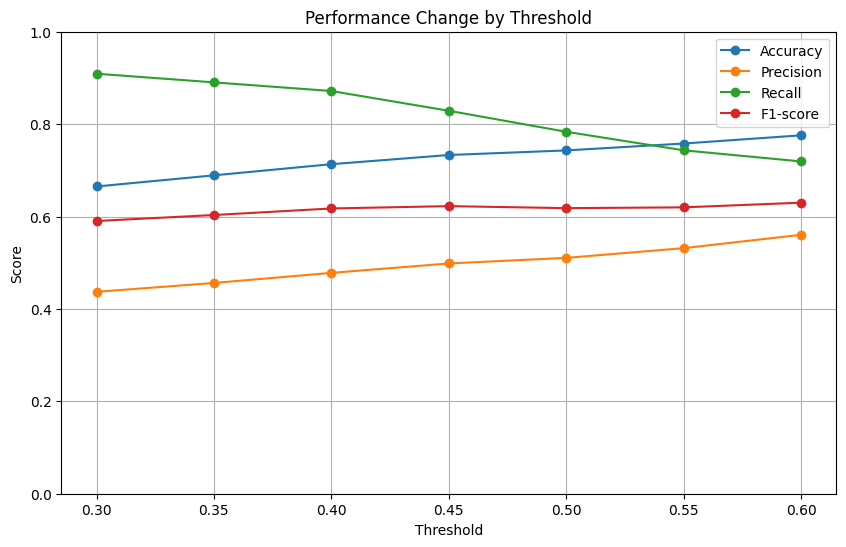

In [8]:
# =========================
# 9-1. Threshold별 성능 변화 시각화
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(threshold_result["Threshold"], threshold_result["Accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_result["Threshold"], threshold_result["Precision"], marker="o", label="Precision")
plt.plot(threshold_result["Threshold"], threshold_result["Recall"], marker="o", label="Recall")
plt.plot(threshold_result["Threshold"], threshold_result["F1-score"], marker="o", label="F1-score")

plt.title("Performance Change by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

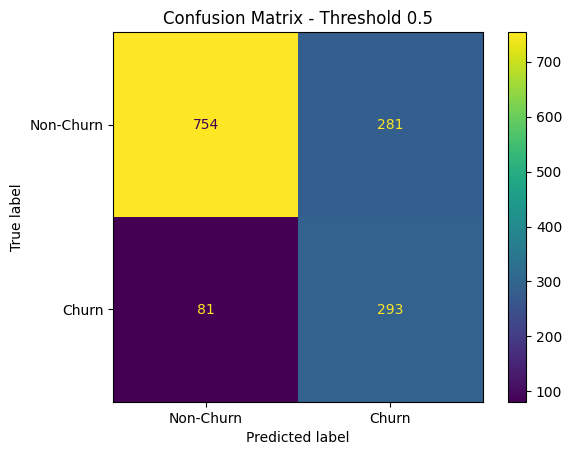

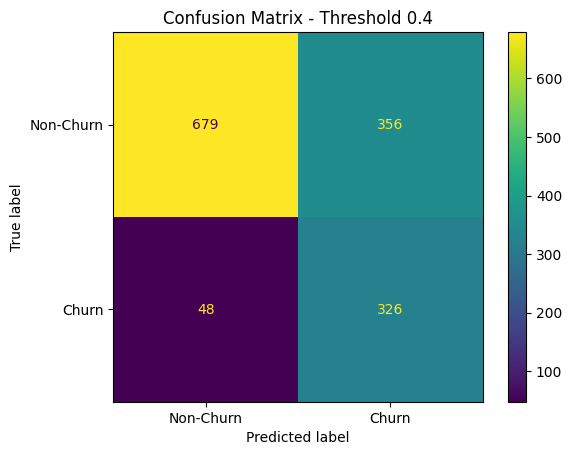

In [9]:
# =========================
# 9-3. Confusion Matrix 시각화
# =========================

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

thresholds_to_plot = [0.50, 0.40]

for threshold in thresholds_to_plot:
    y_pred_th = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Churn", "Churn"]
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - Threshold {threshold}")
    plt.show()

Threshold를 0.50에서 0.40으로 낮추면 Recall은 0.7834에서 0.8717로 증가하고, 실제 이탈 고객을 놓친 FN은 81명에서 48명으로 감소하였다. 다만 FP가 281명에서 356명으로 증가하므로, 이탈 고객 탐지율과 리텐션 비용 간의 trade-off를 고려해 threshold를 선택해야 한다.

In [10]:
# =========================
# 7. Logistic Regression 계수 해석
# =========================

import pandas as pd
import numpy as np

# 학습된 Logistic Regression 모델 가져오기
model = log_reg_baseline.named_steps["model"]

# 전처리기 가져오기
preprocessor_fitted = log_reg_baseline.named_steps["preprocessor"]

# 수치형 변수 이름
num_feature_names = numeric_features

# 범주형 변수 One-Hot Encoding 후 생성된 변수 이름
cat_feature_names = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)

# 전체 feature 이름 합치기
feature_names = np.concatenate([num_feature_names, cat_feature_names])

# Logistic Regression 계수 가져오기
coefficients = model.coef_[0]

# 계수 DataFrame 생성
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Odds Ratio 계산
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])

# 절댓값 기준 중요도
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# 이탈 확률을 높이는 변수 Top 15
positive_coef = coef_df.sort_values(by="Coefficient", ascending=False).head(15)

# 이탈 확률을 낮추는 변수 Top 15
negative_coef = coef_df.sort_values(by="Coefficient", ascending=True).head(15)

# 절댓값 기준 영향력이 큰 변수 Top 20
important_coef = coef_df.sort_values(by="Abs_Coefficient", ascending=False).head(20)

print("===== 이탈 확률을 높이는 변수 Top 15 =====")
display(positive_coef)

print("\n===== 이탈 확률을 낮추는 변수 Top 15 =====")
display(negative_coef)

print("\n===== 절댓값 기준 영향력이 큰 변수 Top 20 =====")
display(important_coef)

===== 이탈 확률을 높이는 변수 Top 15 =====


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
10,Dependents_No,0.701922,2.017626,0.701922
38,Contract_Month-to-month,0.655511,1.926126,0.655511
18,Internet Service_Fiber optic,0.584745,1.794534,0.584745
2,Total Charges,0.496807,1.643466,0.496807
45,Payment Method_Electronic check,0.232994,1.262374,0.232994
37,Streaming Movies_Yes,0.217737,1.243260,0.217737
34,Streaming TV_Yes,0.207444,1.230529,0.207444
20,Online Security_No,0.164267,1.178529,0.164267
29,Tech Support_No,0.145104,1.156160,0.145104
16,Multiple Lines_Yes,0.104274,1.109905,0.104274



===== 이탈 확률을 낮추는 변수 Top 15 =====


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
0,Tenure Months,-1.202455,0.300456,1.202455
11,Dependents_Yes,-0.928690,0.395071,0.928690
40,Contract_Two year,-0.750129,0.472306,0.750129
17,Internet Service_DSL,-0.557187,0.572818,0.557187
1,Monthly Charges,-0.543242,0.580862,0.543242
41,Paperless Billing_No,-0.272626,0.761378,0.272626
24,Online Backup_No internet service,-0.254327,0.775438,0.254327
21,Online Security_No internet service,-0.254327,0.775438,0.254327
30,Tech Support_No internet service,-0.254327,0.775438,0.254327
33,Streaming TV_No internet service,-0.254327,0.775438,0.254327



===== 절댓값 기준 영향력이 큰 변수 Top 20 =====


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
0,Tenure Months,-1.202455,0.300456,1.202455
11,Dependents_Yes,-0.928690,0.395071,0.928690
40,Contract_Two year,-0.750129,0.472306,0.750129
10,Dependents_No,0.701922,2.017626,0.701922
38,Contract_Month-to-month,0.655511,1.926126,0.655511
18,Internet Service_Fiber optic,0.584745,1.794534,0.584745
17,Internet Service_DSL,-0.557187,0.572818,0.557187
1,Monthly Charges,-0.543242,0.580862,0.543242
2,Total Charges,0.496807,1.643466,0.496807
41,Paperless Billing_No,-0.272626,0.761378,0.272626


Logistic Regression 계수 분석 결과, Tenure Months, Contract_Two year, Dependents_Yes는 이탈 가능성을 낮추는 주요 요인으로 나타났다. 반면 Contract_Month-to-month, Internet Service_Fiber optic, Dependents_No, Payment Method_Electronic check는 이탈 가능성을 높이는 방향으로 작용하였다.

In [11]:
# =========================
# 8. Baseline 결과 요약표 생성
# =========================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

# baseline 비교용 threshold
selected_thresholds = [0.50, 0.40]

baseline_summary = []

for threshold in selected_thresholds:
    y_pred_th = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_th)
    prec = precision_score(y_test, y_pred_th)
    rec = recall_score(y_test, y_pred_th)
    f1 = f1_score(y_test, y_pred_th)
    roc_auc = roc_auc_score(y_test, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()

    baseline_summary.append({
        "Model": "Logistic Regression",
        "Threshold": threshold,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

baseline_summary_df = pd.DataFrame(baseline_summary)

print("===== Logistic Regression Baseline 요약표 =====")
display(baseline_summary_df)


# =========================
# 주요 이탈 증가/감소 요인 정리표
# =========================

top_positive_features = positive_coef[["Feature", "Coefficient", "Odds_Ratio"]].head(10).copy()
top_negative_features = negative_coef[["Feature", "Coefficient", "Odds_Ratio"]].head(10).copy()

top_positive_features["Effect"] = "이탈 가능성 증가"
top_negative_features["Effect"] = "이탈 가능성 감소"

feature_summary_df = pd.concat(
    [top_positive_features, top_negative_features],
    axis=0
).reset_index(drop=True)

print("\n===== 주요 Feature 영향 요약표 =====")
display(feature_summary_df)


# =========================
# 최종 baseline에서 사용할 threshold 선택 후보 출력
# =========================

print("\n===== Baseline 선택 해석 =====")
print("Threshold 0.50은 기본 분류 기준이며, Precision과 Accuracy가 상대적으로 높습니다.")
print("Threshold 0.40은 Recall이 높아 실제 이탈 고객을 더 많이 탐지합니다.")
print("고객 이탈 예측에서는 이탈 고객을 놓치는 FN을 줄이는 것이 중요하므로, Recall 중심 분석에서는 threshold 0.40을 후보로 볼 수 있습니다.")

===== Logistic Regression Baseline 요약표 =====


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.5,0.7431,0.5105,0.7834,0.6181,0.8489,754,281,81,293
1,Logistic Regression,0.4,0.7133,0.4780,0.8717,0.6174,0.8489,679,356,48,326



===== 주요 Feature 영향 요약표 =====


,Feature,Coefficient,Odds_Ratio,Effect
0,Dependents_No,0.701922,2.017626,이탈 가능성 증가
1,Contract_Month-to-month,0.655511,1.926126,이탈 가능성 증가
2,Internet Service_Fiber optic,0.584745,1.794534,이탈 가능성 증가
3,Total Charges,0.496807,1.643466,이탈 가능성 증가
4,Payment Method_Electronic check,0.232994,1.262374,이탈 가능성 증가
5,Streaming Movies_Yes,0.217737,1.243260,이탈 가능성 증가
6,Streaming TV_Yes,0.207444,1.230529,이탈 가능성 증가
7,Online Security_No,0.164267,1.178529,이탈 가능성 증가
8,Tech Support_No,0.145104,1.156160,이탈 가능성 증가
9,Multiple Lines_Yes,0.104274,1.109905,이탈 가능성 증가



===== Baseline 선택 해석 =====
Threshold 0.50은 기본 분류 기준이며, Precision과 Accuracy가 상대적으로 높습니다.
Threshold 0.40은 Recall이 높아 실제 이탈 고객을 더 많이 탐지합니다.
고객 이탈 예측에서는 이탈 고객을 놓치는 FN을 줄이는 것이 중요하므로, Recall 중심 분석에서는 threshold 0.40을 후보로 볼 수 있습니다.


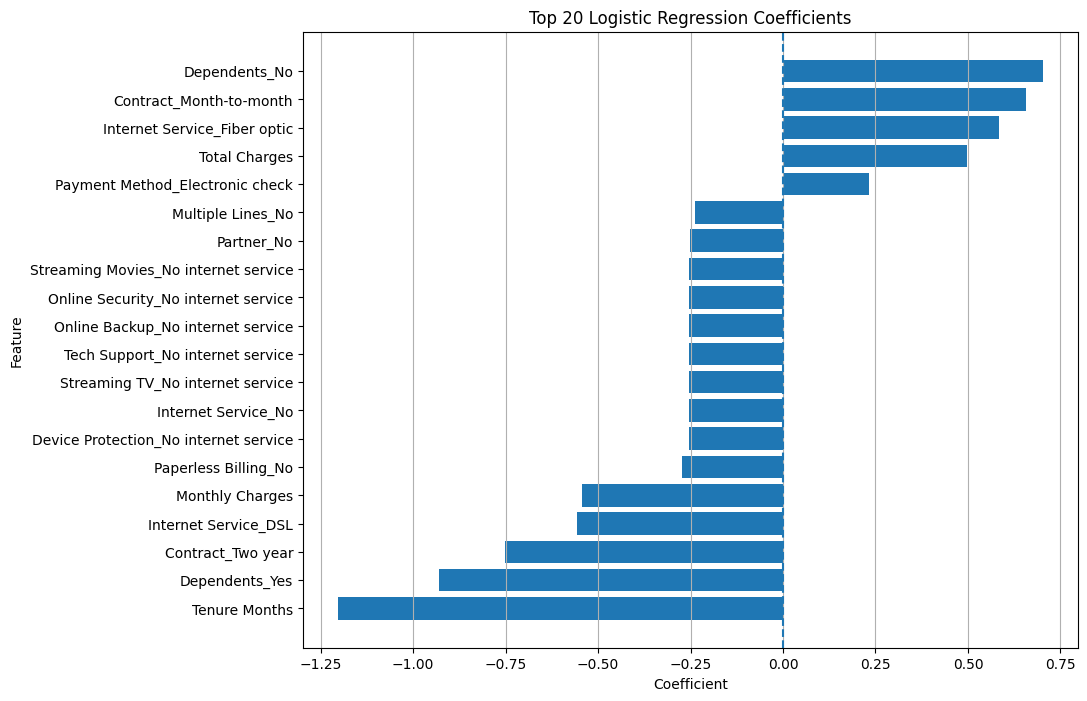

In [12]:
# =========================
# 9-4. Logistic Regression 주요 계수 시각화
# =========================

# 절댓값 기준 영향력이 큰 변수 Top 20 사용
coef_plot_df = important_coef.sort_values(by="Coefficient", ascending=True).copy()

plt.figure(figsize=(10, 8))

plt.barh(coef_plot_df["Feature"], coef_plot_df["Coefficient"])

plt.axvline(x=0, linestyle="--")
plt.title("Top 20 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(axis="x")
plt.show()

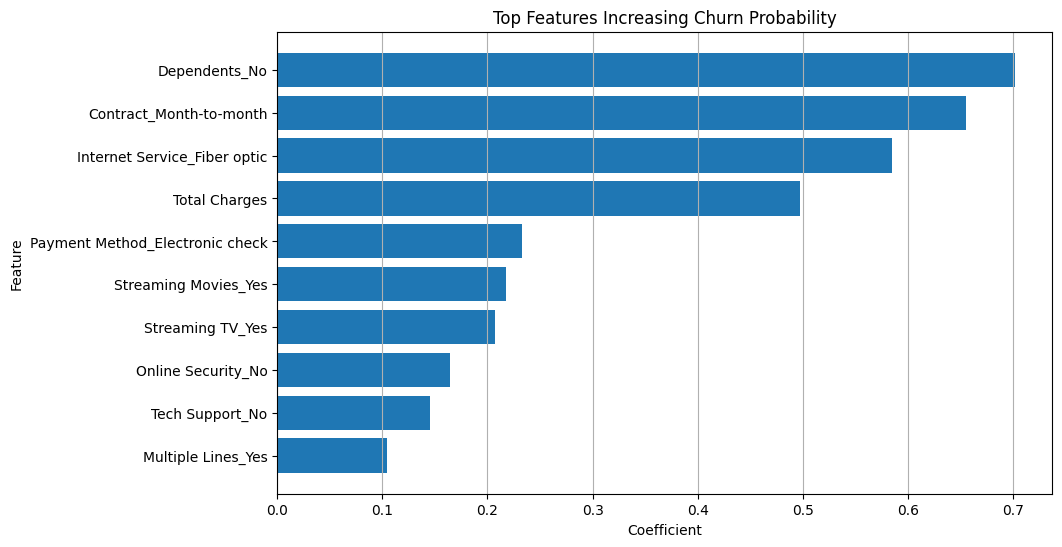

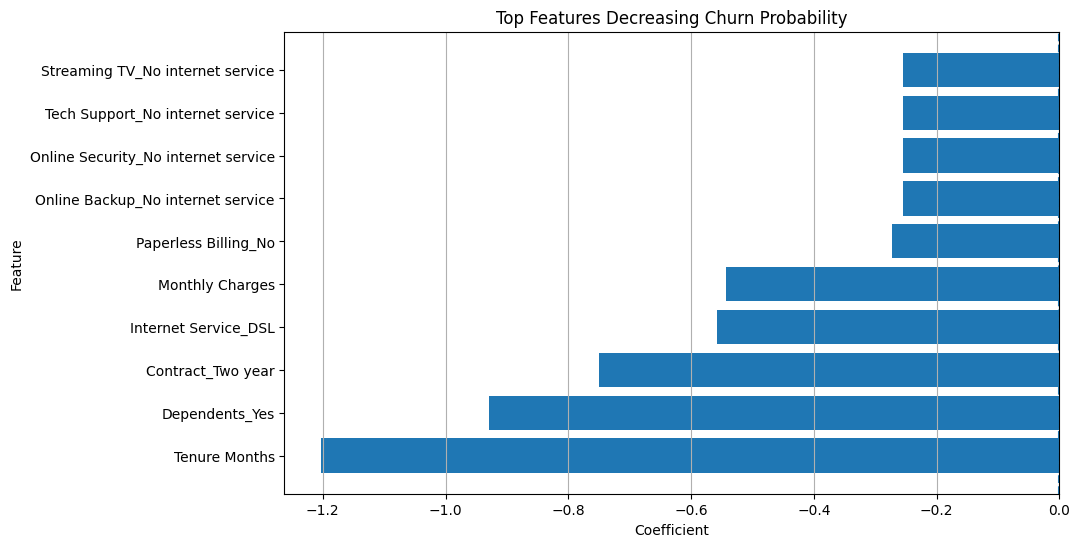

In [13]:
# =========================
# 9-5. 이탈 증가/감소 요인 분리 시각화
# =========================

# 이탈 가능성 증가 Top 10
positive_plot_df = positive_coef.head(10).sort_values(by="Coefficient", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(positive_plot_df["Feature"], positive_plot_df["Coefficient"])
plt.title("Top Features Increasing Churn Probability")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(axis="x")
plt.show()


# 이탈 가능성 감소 Top 10
negative_plot_df = negative_coef.head(10).sort_values(by="Coefficient", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(negative_plot_df["Feature"], negative_plot_df["Coefficient"])
plt.axvline(x=0, linestyle="--")
plt.title("Top Features Decreasing Churn Probability")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(axis="x")
plt.show()

Baseline 최종 결론
| 기준             | Accuracy | Precision | Recall | F1-score | ROC-AUC | FN |  TP |
| -------------- | -------: | --------: | -----: | -------: | ------: | -: | --: |
| Threshold 0.50 |   0.7431 |    0.5105 | 0.7834 |   0.6181 |  0.8489 | 81 | 293 |
| Threshold 0.40 |   0.7133 |    0.4780 | 0.8717 |   0.6174 |  0.8489 | 48 | 326 |
Logistic Regression baseline 모델은 ROC-AUC 0.8489로 이탈 고객과 비이탈 고객을 구분하는 전반적인 성능이 양호하게 나타났다. 기본 threshold 0.50에서는 Recall이 0.7834였으나, threshold를 0.40으로 낮추면 Recall이 0.8717로 증가하고 FN이 81명에서 48명으로 감소하여 이탈 고객 탐지 목적에 더 적합한 기준으로 판단된다.


계수 기준으로 보면 이탈 가능성을 높이는 주요 요인은 다음이야.

Dependents_No
Contract_Month-to-month
Internet Service_Fiber optic
Payment Method_Electronic check
Online Security_No
Tech Support_No

반대로 이탈 가능성을 낮추는 주요 요인은 다음이야.

Tenure Months
Dependents_Yes
Contract_Two year
Internet Service_DSL
Paperless Billing_No

보고서에는 이렇게 쓰면 돼.

계수 분석 결과, 월 단위 계약, Fiber optic 인터넷 서비스 이용, 부양가족 없음, Electronic check 결제 방식은 이탈 가능성을 높이는 방향으로 나타났다. 반면 가입 기간이 길수록, 장기 계약 고객일수록, 부양가족이 있는 고객일수록 이탈 가능성은 낮아지는 경향을 보였다.

===== Curve 기반 성능 =====
ROC-AUC              : 0.8489
PR-AUC               : 0.6437
Average Precision    : 0.6449
Test 이탈 고객 비율  : 0.2654


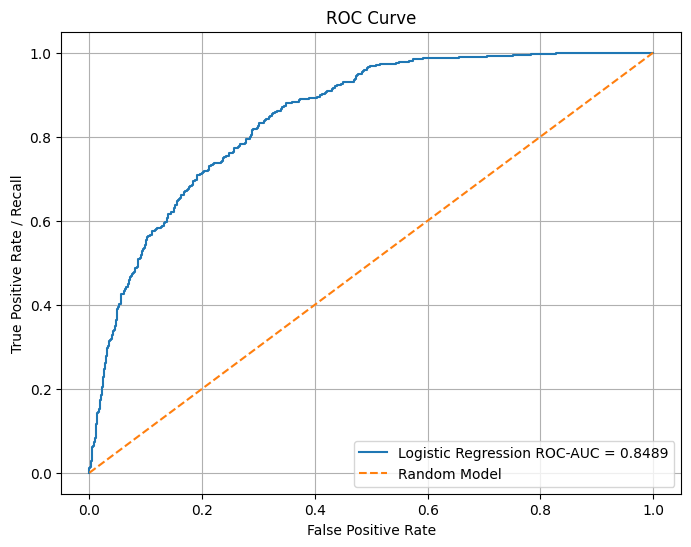

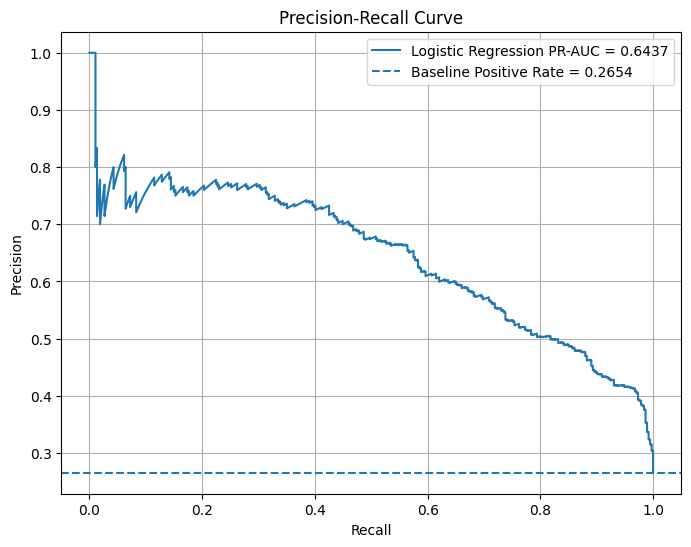

In [14]:
# =========================
# 9. ROC Curve / Precision-Recall Curve 시각화
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score
)

# ROC Curve 계산
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

# Precision-Recall Curve 계산
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc_value = auc(recalls, precisions)
avg_precision = average_precision_score(y_test, y_proba)

# 이탈 고객 비율
positive_rate = y_test.mean()

print("===== Curve 기반 성능 =====")
print(f"ROC-AUC              : {roc_auc_value:.4f}")
print(f"PR-AUC               : {pr_auc_value:.4f}")
print(f"Average Precision    : {avg_precision:.4f}")
print(f"Test 이탈 고객 비율  : {positive_rate:.4f}")


# =========================
# ROC Curve 시각화
# =========================

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression ROC-AUC = {roc_auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Precision-Recall Curve 시각화
# =========================

plt.figure(figsize=(8, 6))

plt.plot(recalls, precisions, label=f"Logistic Regression PR-AUC = {pr_auc_value:.4f}")
plt.axhline(y=positive_rate, linestyle="--", label=f"Baseline Positive Rate = {positive_rate:.4f}")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

ROC-AUC는 0.8489로 나타나 baseline 모델이 이탈 고객과 비이탈 고객을 비교적 잘 구분하는 것으로 확인되었다. 또한 PR-AUC는 0.6437로 테스트 데이터의 기본 이탈률 0.2654보다 높게 나타나, 단순 무작위 분류보다 이탈 고객 탐지 성능이 충분히 개선되었음을 확인하였다.

모델이 이탈 확률을 높게 준 고객들은 실제로 이탈률이 높은가? 확인해보기


In [15]:
# =========================
# 10. 예측 확률 기반 고위험군 확인
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Test 데이터에 실제값과 예측 확률 붙이기
test_result_df = X_test.copy()
test_result_df["Actual_Churn"] = y_test
test_result_df["Churn_Probability"] = y_proba

# threshold 0.50 / 0.40 기준 예측값 추가
test_result_df["Pred_Threshold_0.50"] = (test_result_df["Churn_Probability"] >= 0.50).astype(int)
test_result_df["Pred_Threshold_0.40"] = (test_result_df["Churn_Probability"] >= 0.40).astype(int)

print("Test 결과 데이터 크기:", test_result_df.shape)

print("\n예측 확률 요약 통계:")
print(test_result_df["Churn_Probability"].describe())

print("\n실제 이탈 여부별 예측 확률 평균:")
print(test_result_df.groupby("Actual_Churn")["Churn_Probability"].mean())

print("\nThreshold 0.40 기준 예측 그룹별 실제 이탈률:")
threshold_040_summary = test_result_df.groupby("Pred_Threshold_0.40").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean")
).reset_index()

display(threshold_040_summary)

print("\nThreshold 0.50 기준 예측 그룹별 실제 이탈률:")
threshold_050_summary = test_result_df.groupby("Pred_Threshold_0.50").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean")
).reset_index()

display(threshold_050_summary)

Test 결과 데이터 크기: (1409, 24)

예측 확률 요약 통계:
count    1409.000000
mean        0.407991
std         0.312882
min         0.002073
25%         0.091045
50%         0.375442
75%         0.718928
max         0.950274
Name: Churn_Probability, dtype: float64

실제 이탈 여부별 예측 확률 평균:
Actual_Churn
0    0.306795
1    0.688040
Name: Churn_Probability, dtype: float64

Threshold 0.40 기준 예측 그룹별 실제 이탈률:


,Pred_Threshold_0.40,customer_count,actual_churn_count,actual_churn_rate
0,0,727,48,0.066025
1,1,682,326,0.478006



Threshold 0.50 기준 예측 그룹별 실제 이탈률:


,Pred_Threshold_0.50,customer_count,actual_churn_count,actual_churn_rate
0,0,835,81,0.097006
1,1,574,293,0.510453


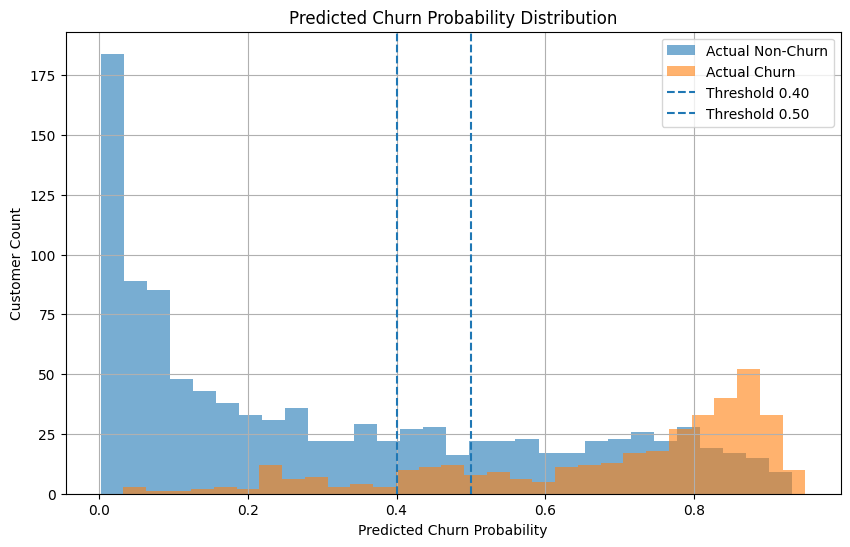

In [16]:
# =========================
# 10-1. 실제 이탈 여부별 예측 확률 분포
# =========================

plt.figure(figsize=(10, 6))

plt.hist(
    test_result_df[test_result_df["Actual_Churn"] == 0]["Churn_Probability"],
    bins=30,
    alpha=0.6,
    label="Actual Non-Churn"
)

plt.hist(
    test_result_df[test_result_df["Actual_Churn"] == 1]["Churn_Probability"],
    bins=30,
    alpha=0.6,
    label="Actual Churn"
)

plt.axvline(x=0.40, linestyle="--", label="Threshold 0.40")
plt.axvline(x=0.50, linestyle="--", label="Threshold 0.50")

plt.title("Predicted Churn Probability Distribution")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Customer Count")
plt.legend()
plt.grid(True)
plt.show()

===== 예측 확률 구간별 실제 이탈률 =====


/tmp/ipykernel_3378/1757869564.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_summary = test_result_df.groupby("Probability_Decile").agg(


,Probability_Decile,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
0,"(0.0010699999999999998, 0.0244]",141,0,0.000000,0.011546
1,"(0.0244, 0.0658]",141,3,0.021277,0.043155
2,"(0.0658, 0.133]",141,2,0.014184,0.094149
3,"(0.133, 0.241]",141,16,0.113475,0.186961
4,"(0.241, 0.375]",141,23,0.163121,0.302448
5,"(0.375, 0.507]",140,40,0.285714,0.441399
6,"(0.507, 0.662]",141,41,0.290780,0.584232
7,"(0.662, 0.772]",141,59,0.418440,0.718856
8,"(0.772, 0.849]",141,82,0.581560,0.811744
9,"(0.849, 0.95]",141,108,0.765957,0.885662


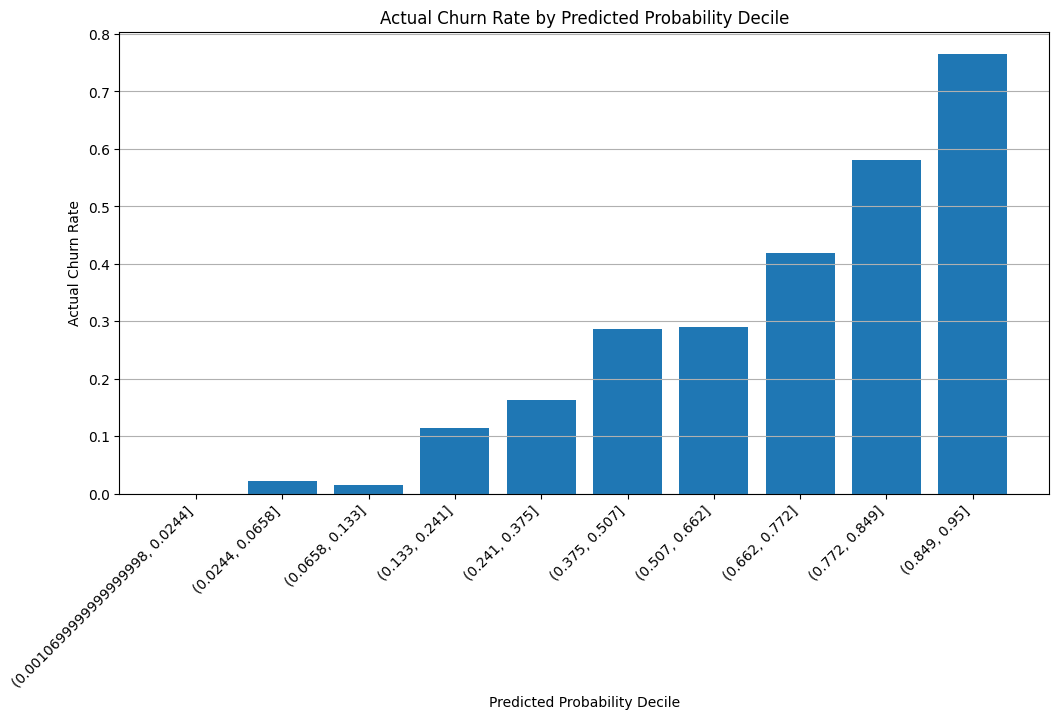

In [17]:
# =========================
# 10-2. 예측 확률 구간별 실제 이탈률 확인
# =========================

# 예측 확률을 10개 구간으로 나누기
test_result_df["Probability_Decile"] = pd.qcut(
    test_result_df["Churn_Probability"],
    q=10,
    duplicates="drop"
)

decile_summary = test_result_df.groupby("Probability_Decile").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

print("===== 예측 확률 구간별 실제 이탈률 =====")
display(decile_summary)


# 시각화
plt.figure(figsize=(12, 6))

decile_labels = [str(x) for x in decile_summary["Probability_Decile"]]

plt.bar(decile_labels, decile_summary["actual_churn_rate"])

plt.title("Actual Churn Rate by Predicted Probability Decile")
plt.xlabel("Predicted Probability Decile")
plt.ylabel("Actual Churn Rate")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

예측 확률 구간별 실제 이탈률을 확인한 결과, 예측 확률이 높은 구간일수록 실제 이탈률도 함께 증가하였다. 특히 상위 10% 고위험군의 실제 이탈률은 76.6%로 나타나, Logistic Regression baseline 모델이 고객의 이탈 위험도를 의미 있게 정렬하고 있음을 확인하였다.

In [18]:
# =========================
# 11. Baseline 기반 고위험군 후보 정리
# =========================

import pandas as pd
import numpy as np

# test_result_df는 앞 단계에서 만든 테스트 결과 데이터
# Churn_Probability, Actual_Churn이 포함되어 있음

# 1) 예측 확률 기준 Risk Group 생성
def assign_risk_group(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

test_result_df["Risk_Group"] = test_result_df["Churn_Probability"].apply(assign_risk_group)

risk_group_summary = test_result_df.groupby("Risk_Group").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

# 보기 좋은 순서로 정렬
risk_order = ["Low Risk", "Medium Risk", "High Risk"]
risk_group_summary["Risk_Group"] = pd.Categorical(
    risk_group_summary["Risk_Group"],
    categories=risk_order,
    ordered=True
)

risk_group_summary = risk_group_summary.sort_values("Risk_Group")

print("===== 예측 확률 기반 Risk Group 요약 =====")
display(risk_group_summary)


# 2) 주요 Feature 조합 기반 세그먼트 후보 확인
# Logistic Regression 계수에서 중요하게 나온 변수들을 중심으로 조건 생성

segment_df = test_result_df.copy()

segment_df["Segment_Month_to_month"] = segment_df["Contract"].eq("Month-to-month")
segment_df["Segment_Fiber_optic"] = segment_df["Internet Service"].eq("Fiber optic")
segment_df["Segment_No_Dependents"] = segment_df["Dependents"].eq("No")
segment_df["Segment_Electronic_check"] = segment_df["Payment Method"].eq("Electronic check")
segment_df["Segment_No_Online_Security"] = segment_df["Online Security"].eq("No")
segment_df["Segment_No_Tech_Support"] = segment_df["Tech Support"].eq("No")

# 위험 요인 개수 계산
risk_factor_cols = [
    "Segment_Month_to_month",
    "Segment_Fiber_optic",
    "Segment_No_Dependents",
    "Segment_Electronic_check",
    "Segment_No_Online_Security",
    "Segment_No_Tech_Support"
]

segment_df["Risk_Factor_Count"] = segment_df[risk_factor_cols].sum(axis=1)

risk_factor_summary = segment_df.groupby("Risk_Factor_Count").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

print("\n===== 주요 위험 요인 개수별 실제 이탈률 =====")
display(risk_factor_summary)


# 3) 구체적인 세그먼트 후보 몇 개 확인
segment_candidates = []

conditions = {
    "Month-to-month": segment_df["Contract"].eq("Month-to-month"),
    "Month-to-month + Fiber optic": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic")
    ),
    "Month-to-month + Fiber optic + No Tech Support": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Tech Support"].eq("No")
    ),
    "Month-to-month + Fiber optic + Electronic check": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Payment Method"].eq("Electronic check")
    ),
    "Month-to-month + Fiber optic + No Tech Support + No Online Security": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Tech Support"].eq("No") &
        segment_df["Online Security"].eq("No")
    )
}

for segment_name, condition in conditions.items():
    temp = segment_df[condition]

    segment_candidates.append({
        "Segment": segment_name,
        "customer_count": len(temp),
        "actual_churn_count": temp["Actual_Churn"].sum(),
        "actual_churn_rate": temp["Actual_Churn"].mean(),
        "avg_predicted_probability": temp["Churn_Probability"].mean()
    })

segment_candidate_df = pd.DataFrame(segment_candidates)

print("\n===== 세그먼트 후보별 실제 이탈률 =====")
display(segment_candidate_df)

===== 예측 확률 기반 Risk Group 요약 =====


,Risk_Group,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
1,Low Risk,727,48,0.066025,0.135509
2,Medium Risk,300,94,0.313333,0.544939
0,High Risk,382,232,0.607330,0.819014



===== 주요 위험 요인 개수별 실제 이탈률 =====


,Risk_Factor_Count,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
0,0,115,0,0.000000,0.018194
1,1,242,9,0.037190,0.075678
2,2,252,38,0.150794,0.241734
3,3,182,34,0.186813,0.339623
4,4,219,62,0.283105,0.544247
5,5,216,110,0.509259,0.727676
6,6,183,121,0.661202,0.848944



===== 세그먼트 후보별 실제 이탈률 =====


,Segment,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
0,Month-to-month,773,329,0.425614,0.620638
1,Month-to-month + Fiber optic,421,222,0.527316,0.749761
2,Month-to-month + Fiber optic + No Tech Support,358,205,0.572626,0.763780
3,Month-to-month + Fiber optic + Electronic check,255,148,0.580392,0.796306
4,Month-to-month + Fiber optic + No Tech Support...,306,184,0.601307,0.789569


In [19]:
segment_df["Risk_Factor_Count"] = segment_df[risk_factor_cols].sum(axis=1)

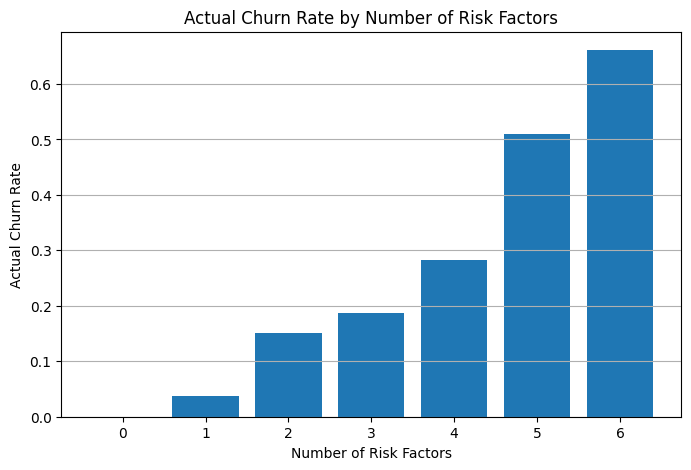

In [20]:
# =========================
# 11-1. 위험 요인 개수별 실제 이탈률 시각화
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    risk_factor_summary["Risk_Factor_Count"],
    risk_factor_summary["actual_churn_rate"]
)

plt.title("Actual Churn Rate by Number of Risk Factors")
plt.xlabel("Number of Risk Factors")
plt.ylabel("Actual Churn Rate")
plt.xticks(risk_factor_summary["Risk_Factor_Count"])
plt.grid(axis="y")
plt.show()

In [21]:
# =========================
# Logistic Regression Baseline 전체 재실행 코드
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score
)

# =========================
# 1. 파일 경로 설정
# =========================

file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
output_dir = "/content/drive/MyDrive/AI@Sogang_mini_project"

print("파일 존재 여부:", os.path.exists(file_path))
print("저장 폴더 존재 여부:", os.path.exists(output_dir))

# =========================
# 2. 데이터 불러오기
# =========================

df = pd.read_csv(file_path)

print("\n원본 데이터 크기:", df.shape)

# =========================
# 3. Baseline용 컬럼 제거
# =========================

baseline_df = df.copy()

drop_cols = [
    # ID / 상수 / 고정 정보
    "CustomerID",
    "Count",
    "Country",
    "State",

    # 이번 baseline에서 제외한 지역 정보
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",

    # 타깃 누수 가능 컬럼
    "Churn Label",
    "Churn Reason",
    "Churn Score"
]

baseline_df = baseline_df.drop(columns=drop_cols)

# =========================
# 4. Total Charges 숫자형 변환 및 결측치 처리
# =========================

baseline_df["Total Charges"] = pd.to_numeric(
    baseline_df["Total Charges"],
    errors="coerce"
)

print("\nTotal Charges 변환 후 결측치 개수:", baseline_df["Total Charges"].isnull().sum())

baseline_df["Total Charges"] = baseline_df["Total Charges"].fillna(0)

print("결측치 처리 후 전체 결측치 개수:", baseline_df.isnull().sum().sum())

# =========================
# 5. X, y 분리
# =========================

X = baseline_df.drop(columns=["Churn Value"])
y = baseline_df["Churn Value"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nX 크기:", X.shape)
print("y 크기:", y.shape)
print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)

# =========================
# 6. Train/Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain 크기:", X_train.shape)
print("Test 크기:", X_test.shape)
print("\nTrain 이탈률:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTest 이탈률:")
print(y_test.value_counts(normalize=True) * 100)

# =========================
# 7. 전처리 + Logistic Regression Pipeline
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

log_reg_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

log_reg_baseline.fit(X_train, y_train)

# =========================
# 8. 기본 예측 및 성능 평가
# =========================

y_pred = log_reg_baseline.predict(X_test)
y_proba = log_reg_baseline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n===== Logistic Regression Baseline 성능, Threshold 0.50 =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 9. Threshold별 성능 비교
# =========================

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold)
    rec = recall_score(y_test, y_pred_threshold)
    f1_val = f1_score(y_test, y_pred_threshold)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1_val,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_result = pd.DataFrame(results)

print("\n===== Threshold별 성능 비교 =====")
display(threshold_result)

# =========================
# 10. Baseline 요약표
# =========================

selected_thresholds = [0.50, 0.40]

baseline_summary = []

for threshold in selected_thresholds:
    y_pred_th = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_th)
    prec = precision_score(y_test, y_pred_th)
    rec = recall_score(y_test, y_pred_th)
    f1_val = f1_score(y_test, y_pred_th)
    roc_auc_val = roc_auc_score(y_test, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()

    baseline_summary.append({
        "Model": "Logistic Regression",
        "Threshold": threshold,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1_val, 4),
        "ROC-AUC": round(roc_auc_val, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

baseline_summary_df = pd.DataFrame(baseline_summary)

print("\n===== Logistic Regression Baseline 요약표 =====")
display(baseline_summary_df)

# =========================
# 11. Logistic Regression 계수 해석
# =========================

model = log_reg_baseline.named_steps["model"]
preprocessor_fitted = log_reg_baseline.named_steps["preprocessor"]

num_feature_names = numeric_features
cat_feature_names = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)

feature_names = np.concatenate([num_feature_names, cat_feature_names])
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

positive_coef = coef_df.sort_values(by="Coefficient", ascending=False).head(15)
negative_coef = coef_df.sort_values(by="Coefficient", ascending=True).head(15)
important_coef = coef_df.sort_values(by="Abs_Coefficient", ascending=False).head(20)

top_positive_features = positive_coef[["Feature", "Coefficient", "Odds_Ratio"]].head(10).copy()
top_negative_features = negative_coef[["Feature", "Coefficient", "Odds_Ratio"]].head(10).copy()

top_positive_features["Effect"] = "이탈 가능성 증가"
top_negative_features["Effect"] = "이탈 가능성 감소"

feature_summary_df = pd.concat(
    [top_positive_features, top_negative_features],
    axis=0
).reset_index(drop=True)

print("\n===== 주요 Feature 영향 요약표 =====")
display(feature_summary_df)

# =========================
# 12. ROC / PR Curve 수치 계산
# =========================

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc_value = auc(recalls, precisions)
avg_precision = average_precision_score(y_test, y_proba)

positive_rate = y_test.mean()

print("\n===== Curve 기반 성능 =====")
print(f"ROC-AUC              : {roc_auc_value:.4f}")
print(f"PR-AUC               : {pr_auc_value:.4f}")
print(f"Average Precision    : {avg_precision:.4f}")
print(f"Test 이탈 고객 비율  : {positive_rate:.4f}")

# =========================
# 13. 예측 확률 기반 결과 데이터 생성
# =========================

test_result_df = X_test.copy()
test_result_df["Actual_Churn"] = y_test
test_result_df["Churn_Probability"] = y_proba

test_result_df["Pred_Threshold_0.50"] = (test_result_df["Churn_Probability"] >= 0.50).astype(int)
test_result_df["Pred_Threshold_0.40"] = (test_result_df["Churn_Probability"] >= 0.40).astype(int)

print("\n예측 확률 요약 통계:")
print(test_result_df["Churn_Probability"].describe())

print("\n실제 이탈 여부별 예측 확률 평균:")
print(test_result_df.groupby("Actual_Churn")["Churn_Probability"].mean())

threshold_040_summary = test_result_df.groupby("Pred_Threshold_0.40").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean")
).reset_index()

threshold_050_summary = test_result_df.groupby("Pred_Threshold_0.50").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean")
).reset_index()

# =========================
# 14. 예측 확률 구간별 실제 이탈률
# =========================

test_result_df["Probability_Decile"] = pd.qcut(
    test_result_df["Churn_Probability"],
    q=10,
    duplicates="drop"
)

decile_summary = test_result_df.groupby(
    "Probability_Decile",
    observed=False
).agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

print("\n===== 예측 확률 구간별 실제 이탈률 =====")
display(decile_summary)

# =========================
# 15. Risk Group 생성
# =========================

def assign_risk_group(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

test_result_df["Risk_Group"] = test_result_df["Churn_Probability"].apply(assign_risk_group)

risk_group_summary = test_result_df.groupby("Risk_Group").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

risk_order = ["Low Risk", "Medium Risk", "High Risk"]
risk_group_summary["Risk_Group"] = pd.Categorical(
    risk_group_summary["Risk_Group"],
    categories=risk_order,
    ordered=True
)

risk_group_summary = risk_group_summary.sort_values("Risk_Group")

print("\n===== 예측 확률 기반 Risk Group 요약 =====")
display(risk_group_summary)

# =========================
# 16. 위험 요인 개수별 이탈률
# =========================

segment_df = test_result_df.copy()

segment_df["Segment_Month_to_month"] = segment_df["Contract"].eq("Month-to-month")
segment_df["Segment_Fiber_optic"] = segment_df["Internet Service"].eq("Fiber optic")
segment_df["Segment_No_Dependents"] = segment_df["Dependents"].eq("No")
segment_df["Segment_Electronic_check"] = segment_df["Payment Method"].eq("Electronic check")
segment_df["Segment_No_Online_Security"] = segment_df["Online Security"].eq("No")
segment_df["Segment_No_Tech_Support"] = segment_df["Tech Support"].eq("No")

risk_factor_cols = [
    "Segment_Month_to_month",
    "Segment_Fiber_optic",
    "Segment_No_Dependents",
    "Segment_Electronic_check",
    "Segment_No_Online_Security",
    "Segment_No_Tech_Support"
]

segment_df["Risk_Factor_Count"] = segment_df[risk_factor_cols].sum(axis=1)

risk_factor_summary = segment_df.groupby("Risk_Factor_Count").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

print("\n===== 주요 위험 요인 개수별 실제 이탈률 =====")
display(risk_factor_summary)

# =========================
# 17. 세그먼트 후보별 이탈률
# =========================

segment_candidates = []

conditions = {
    "Month-to-month": segment_df["Contract"].eq("Month-to-month"),
    "Month-to-month + Fiber optic": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic")
    ),
    "Month-to-month + Fiber optic + No Tech Support": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Tech Support"].eq("No")
    ),
    "Month-to-month + Fiber optic + Electronic check": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Payment Method"].eq("Electronic check")
    ),
    "Month-to-month + Fiber optic + No Tech Support + No Online Security": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Tech Support"].eq("No") &
        segment_df["Online Security"].eq("No")
    )
}

for segment_name, condition in conditions.items():
    temp = segment_df[condition]

    segment_candidates.append({
        "Segment": segment_name,
        "customer_count": len(temp),
        "actual_churn_count": temp["Actual_Churn"].sum(),
        "actual_churn_rate": temp["Actual_Churn"].mean(),
        "avg_predicted_probability": temp["Churn_Probability"].mean()
    })

segment_candidate_df = pd.DataFrame(segment_candidates)

print("\n===== 세그먼트 후보별 실제 이탈률 =====")
display(segment_candidate_df)

# =========================
# 18. 결과 저장
# =========================

baseline_summary_df.to_csv(os.path.join(output_dir, "baseline_logistic_regression_summary.csv"), index=False)
feature_summary_df.to_csv(os.path.join(output_dir, "baseline_feature_effect_summary.csv"), index=False)
risk_group_summary.to_csv(os.path.join(output_dir, "baseline_risk_group_summary.csv"), index=False)
risk_factor_summary.to_csv(os.path.join(output_dir, "baseline_risk_factor_summary.csv"), index=False)
segment_candidate_df.to_csv(os.path.join(output_dir, "baseline_segment_candidate_summary.csv"), index=False)
decile_summary.to_csv(os.path.join(output_dir, "baseline_probability_decile_summary.csv"), index=False)
threshold_result.to_csv(os.path.join(output_dir, "baseline_threshold_result.csv"), index=False)
test_result_df.to_csv(os.path.join(output_dir, "baseline_test_prediction_result.csv"), index=False)

print("\nBaseline 결과 저장 완료")
print("저장 위치:", output_dir)
print("- baseline_logistic_regression_summary.csv")
print("- baseline_feature_effect_summary.csv")
print("- baseline_risk_group_summary.csv")
print("- baseline_risk_factor_summary.csv")
print("- baseline_segment_candidate_summary.csv")
print("- baseline_probability_decile_summary.csv")
print("- baseline_threshold_result.csv")
print("- baseline_test_prediction_result.csv")

파일 존재 여부: True
저장 폴더 존재 여부: True

원본 데이터 크기: (7043, 33)

Total Charges 변환 후 결측치 개수: 11
결측치 처리 후 전체 결측치 개수: 0

X 크기: (7043, 20)
y 크기: (7043,)
수치형 변수: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
범주형 변수: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Train 크기: (5634, 20)
Test 크기: (1409, 20)

Train 이탈률:
Churn Value
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Test 이탈률:
Churn Value
0    73.456352
1    26.543648
Name: proportion, dtype: float64

===== Logistic Regression Baseline 성능, Threshold 0.50 =====
Accuracy  : 0.7431
Precision : 0.5105
Recall    : 0.7834
F1-score  : 0.6181
ROC-AUC   : 0.8489

Confusion Matrix:
[[754 281]
 [ 81 293]]

Classification Report:
              precision    recall  f1-score   support

           0       0

,Threshold,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,0.30,0.665011,0.437018,0.909091,0.590278,597,438,34,340
1,0.35,0.689141,0.456164,0.890374,0.603261,638,397,41,333
2,0.40,0.713272,0.478006,0.871658,0.617424,679,356,48,326
3,0.45,0.733144,0.498392,0.828877,0.622490,723,312,64,310
4,0.50,0.743080,0.510453,0.783422,0.618143,754,281,81,293
5,0.55,0.757984,0.531549,0.743316,0.619844,790,245,96,278
6,0.60,0.775727,0.560417,0.719251,0.629977,824,211,105,269



===== Logistic Regression Baseline 요약표 =====


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.5,0.7431,0.5105,0.7834,0.6181,0.8489,754,281,81,293
1,Logistic Regression,0.4,0.7133,0.4780,0.8717,0.6174,0.8489,679,356,48,326



===== 주요 Feature 영향 요약표 =====


...


===== 주요 위험 요인 개수별 실제 이탈률 =====


,Risk_Factor_Count,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
0,0,115,0,0.000000,0.018194
1,1,242,9,0.037190,0.075678
2,2,252,38,0.150794,0.241734
3,3,182,34,0.186813,0.339623
4,4,219,62,0.283105,0.544247
5,5,216,110,0.509259,0.727676
6,6,183,121,0.661202,0.848944



===== 세그먼트 후보별 실제 이탈률 =====


,Segment,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
0,Month-to-month,773,329,0.425614,0.620638
1,Month-to-month + Fiber optic,421,222,0.527316,0.749761
2,Month-to-month + Fiber optic + No Tech Support,358,205,0.572626,0.763780
3,Month-to-month + Fiber optic + Electronic check,255,148,0.580392,0.796306
4,Month-to-month + Fiber optic + No Tech Support...,306,184,0.601307,0.789569



Baseline 결과 저장 완료
저장 위치: /content/drive/MyDrive/AI@Sogang_mini_project
- baseline_logistic_regression_summary.csv
- baseline_feature_effect_summary.csv
- baseline_risk_group_summary.csv
- baseline_risk_factor_summary.csv
- baseline_segment_candidate_summary.csv
- baseline_probability_decile_summary.csv
- baseline_threshold_result.csv
- baseline_test_prediction_result.csv


처음 baseline에서는 지역 변수를 전부 제외했으니까, 추가 실험에서는 바로 모델에 넣기보다 먼저 아래 질문을 확인해야 해.

1. City, Zip Code가 실제 이탈률 차이를 보이는가?
2. 그런데 표본 수가 너무 적은 지역 때문에 우연히 높아 보이는 것은 아닌가?
3. Latitude, Longitude는 단독 수치형 변수로 의미가 있는가?
4. 지역 정보를 그대로 넣을지, 가공해서 넣을지 결정할 수 있는가?

그래서 이번 단계에서는 지역 변수 EDA부터 하자.

In [22]:
# =========================
# 13. 지역 변수 EDA
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df가 없으면 Drive에서 다시 불러오기
try:
    df
    print("기존 df 사용")
except NameError:
    file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
    df = pd.read_csv(file_path)
    print("Drive에서 df 다시 불러오기 완료")

# 지역 변수 목록
geo_cols = ["City", "Zip Code", "Latitude", "Longitude"]

print("===== 지역 변수 고유값 개수 =====")
print(df[geo_cols].nunique())

print("\n===== 지역 변수 결측치 확인 =====")
print(df[geo_cols].isnull().sum())

print("\n===== 전체 이탈률 =====")
overall_churn_rate = df["Churn Value"].mean()
print(f"전체 이탈률: {overall_churn_rate:.4f}")


# =========================
# 13-1. City별 고객 수 / 이탈률 요약
# =========================

city_summary = df.groupby("City").agg(
    customer_count=("Churn Value", "count"),
    actual_churn_count=("Churn Value", "sum"),
    actual_churn_rate=("Churn Value", "mean"),
    avg_latitude=("Latitude", "mean"),
    avg_longitude=("Longitude", "mean")
).reset_index()

city_summary = city_summary.sort_values(
    by=["actual_churn_rate", "customer_count"],
    ascending=[False, False]
)

print("\n===== City 요약 통계 =====")
print(city_summary["customer_count"].describe())

print("\nCity 개수:", city_summary.shape[0])
print("고객 수 5명 미만 City 개수:", (city_summary["customer_count"] < 5).sum())
print("고객 수 10명 미만 City 개수:", (city_summary["customer_count"] < 10).sum())
print("고객 수 20명 미만 City 개수:", (city_summary["customer_count"] < 20).sum())

print("\n===== 고객 수 20명 이상 City 중 이탈률 높은 Top 15 =====")
city_top_churn = city_summary[city_summary["customer_count"] >= 20].sort_values(
    by="actual_churn_rate",
    ascending=False
).head(15)

display(city_top_churn)

print("\n===== 고객 수가 많은 City Top 15 =====")
city_top_count = city_summary.sort_values(
    by="customer_count",
    ascending=False
).head(15)

display(city_top_count)


# =========================
# 13-2. Zip Code별 고객 수 / 이탈률 요약
# =========================

zip_summary = df.groupby("Zip Code").agg(
    customer_count=("Churn Value", "count"),
    actual_churn_count=("Churn Value", "sum"),
    actual_churn_rate=("Churn Value", "mean"),
    avg_latitude=("Latitude", "mean"),
    avg_longitude=("Longitude", "mean")
).reset_index()

zip_summary = zip_summary.sort_values(
    by=["actual_churn_rate", "customer_count"],
    ascending=[False, False]
)

print("\n===== Zip Code 요약 통계 =====")
print(zip_summary["customer_count"].describe())

print("\nZip Code 개수:", zip_summary.shape[0])
print("고객 수 5명 미만 Zip Code 개수:", (zip_summary["customer_count"] < 5).sum())
print("고객 수 10명 미만 Zip Code 개수:", (zip_summary["customer_count"] < 10).sum())
print("고객 수 20명 미만 Zip Code 개수:", (zip_summary["customer_count"] < 20).sum())

print("\n===== 고객 수 10명 이상 Zip Code 중 이탈률 높은 Top 15 =====")
zip_top_churn = zip_summary[zip_summary["customer_count"] >= 10].sort_values(
    by="actual_churn_rate",
    ascending=False
).head(15)

display(zip_top_churn)

print("\n===== 고객 수가 많은 Zip Code Top 15 =====")
zip_top_count = zip_summary.sort_values(
    by="customer_count",
    ascending=False
).head(15)

display(zip_top_count)


# =========================
# 13-3. Latitude / Longitude와 이탈 여부의 단순 상관 확인
# =========================

geo_corr = df[["Latitude", "Longitude", "Churn Value"]].corr()

print("\n===== Latitude / Longitude / Churn Value 상관계수 =====")
display(geo_corr)

기존 df 사용
===== 지역 변수 고유값 개수 =====
City         1129
Zip Code     1652
Latitude     1652
Longitude    1651
dtype: int64

===== 지역 변수 결측치 확인 =====
City         0
Zip Code     0
Latitude     0
Longitude    0
dtype: int64

===== 전체 이탈률 =====
전체 이탈률: 0.2654

===== City 요약 통계 =====
count    1129.000000
mean        6.238264
std        12.254863
min         4.000000
25%         4.000000
50%         4.000000
75%         5.000000
max       305.000000
Name: customer_count, dtype: float64

City 개수: 1129
고객 수 5명 미만 City 개수: 799
고객 수 10명 미만 City 개수: 1017
고객 수 20명 미만 City 개수: 1094

===== 고객 수 20명 이상 City 중 이탈률 높은 Top 15 =====


,City,customer_count,actual_churn_count,actual_churn_rate,avg_latitude,avg_longitude
908,Santa Rosa,24,11,0.458333,38.463095,-122.706907
688,North Hollywood,20,9,0.450000,34.178863,-118.381108
632,Modesto,28,12,0.428571,37.657789,-120.991887
899,Santa Barbara,28,10,0.357143,34.379581,-119.732669
869,San Diego,150,50,0.333333,32.799748,-117.133846
371,Glendale,40,13,0.325000,34.163117,-118.253934
1019,Torrance,25,8,0.320000,33.836484,-118.327783
748,Pasadena,30,9,0.300000,34.152892,-118.135161
872,San Francisco,104,31,0.298077,37.769886,-122.432027
562,Los Angeles,305,90,0.295082,34.042010,-118.299451



===== 고객 수가 많은 City Top 15 =====


,City,customer_count,actual_churn_count,actual_churn_rate,avg_latitude,avg_longitude
562,Los Angeles,305,90,0.295082,34.042010,-118.299451
869,San Diego,150,50,0.333333,32.799748,-117.133846
878,San Jose,112,29,0.258929,37.308713,-121.860396
855,Sacramento,108,26,0.240741,38.570964,-121.439463
872,San Francisco,104,31,0.298077,37.769886,-122.432027
354,Fresno,64,16,0.250000,36.770231,-119.794039
556,Long Beach,60,15,0.250000,33.797162,-118.161903
702,Oakland,52,13,0.250000,37.795450,-122.219322
972,Stockton,44,12,0.272727,37.987431,-121.304688
56,Bakersfield,40,3,0.075000,35.344358,-119.031302



===== Zip Code 요약 통계 =====
count    1652.000000
mean        4.263317
std         0.440566
min         4.000000
25%         4.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: customer_count, dtype: float64

Zip Code 개수: 1652
고객 수 5명 미만 Zip Code 개수: 1217
고객 수 10명 미만 Zip Code 개수: 1652
고객 수 20명 미만 Zip Code 개수: 1652

===== 고객 수 10명 이상 Zip Code 중 이탈률 높은 Top 15 =====


,Zip Code,customer_count,actual_churn_count,actual_churn_rate,avg_latitude,avg_longitude



===== 고객 수가 많은 Zip Code Top 15 =====


,Zip Code,customer_count,actual_churn_count,actual_churn_rate,avg_latitude,avg_longitude
428,92284,5,0,0.0,34.159534,-116.425984
420,92275,5,0,0.0,33.281560,-115.955541
416,92268,5,0,0.0,34.201108,-116.593456
433,92307,5,4,0.8,34.550820,-117.122396
418,92273,5,4,0.8,32.790282,-115.689559
386,92211,5,4,0.8,33.762759,-116.324817
385,92210,5,4,0.8,33.537646,-116.291089
377,92129,5,4,0.8,32.961064,-117.134917
276,91773,5,4,0.8,34.102119,-117.815532
258,91744,5,4,0.8,34.031441,-117.936436



===== Latitude / Longitude / Churn Value 상관계수 =====


,Latitude,Longitude,Churn Value
Latitude,1.000000,-0.876779,-0.003384
Longitude,-0.876779,1.000000,0.004594
Churn Value,-0.003384,0.004594,1.000000


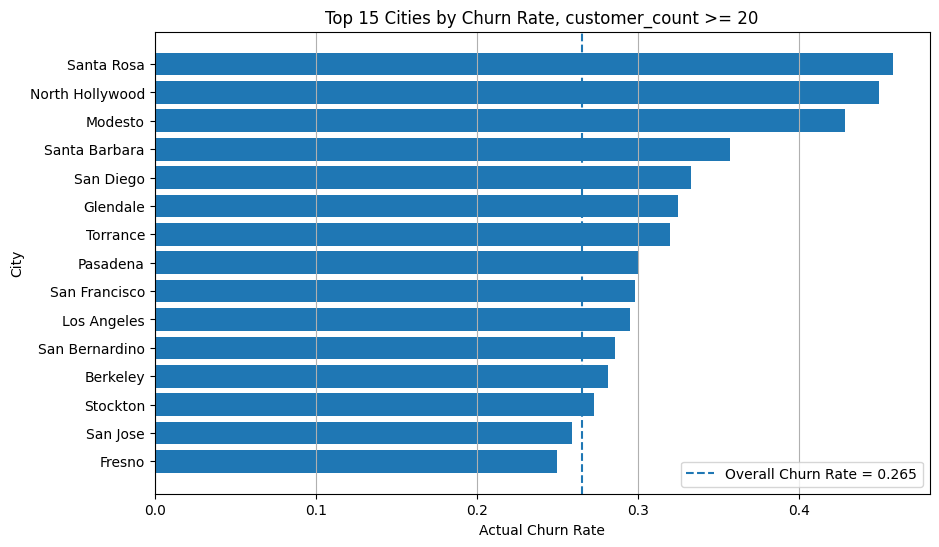

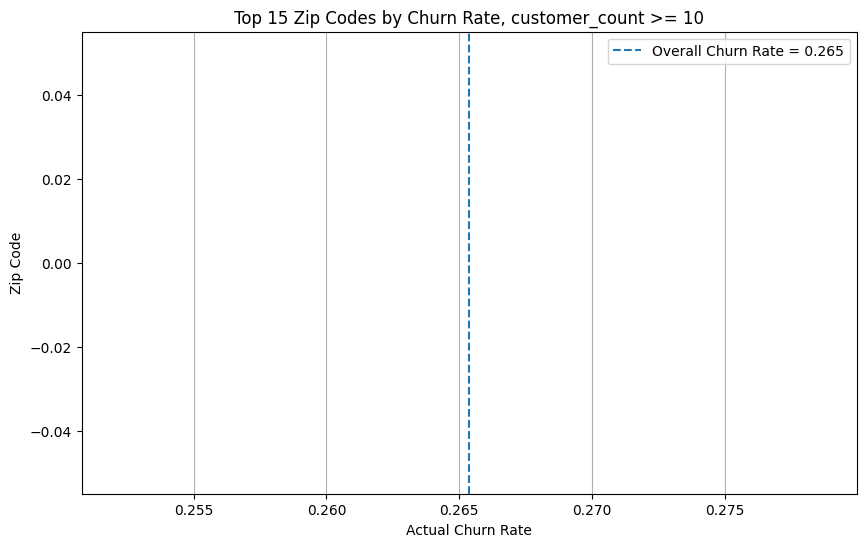

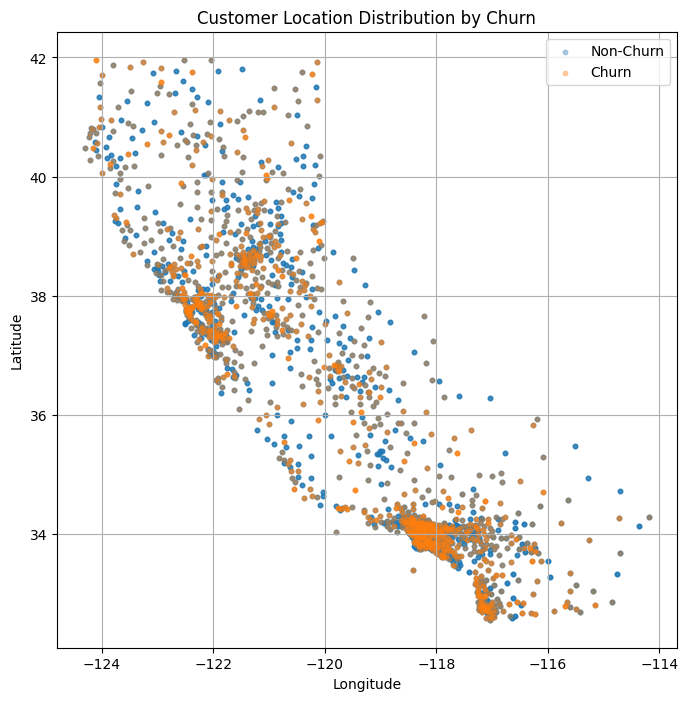

In [23]:
# =========================
# 13-4. City별 이탈률 시각화
# =========================

plt.figure(figsize=(10, 6))

plot_df = city_top_churn.sort_values("actual_churn_rate")

plt.barh(plot_df["City"], plot_df["actual_churn_rate"])

plt.axvline(x=overall_churn_rate, linestyle="--", label=f"Overall Churn Rate = {overall_churn_rate:.3f}")

plt.title("Top 15 Cities by Churn Rate, customer_count >= 20")
plt.xlabel("Actual Churn Rate")
plt.ylabel("City")
plt.legend()
plt.grid(axis="x")
plt.show()


# =========================
# 13-5. Zip Code별 이탈률 시각화
# =========================

plt.figure(figsize=(10, 6))

plot_df = zip_top_churn.copy()
plot_df["Zip Code"] = plot_df["Zip Code"].astype(str)
plot_df = plot_df.sort_values("actual_churn_rate")

plt.barh(plot_df["Zip Code"], plot_df["actual_churn_rate"])

plt.axvline(x=overall_churn_rate, linestyle="--", label=f"Overall Churn Rate = {overall_churn_rate:.3f}")

plt.title("Top 15 Zip Codes by Churn Rate, customer_count >= 10")
plt.xlabel("Actual Churn Rate")
plt.ylabel("Zip Code")
plt.legend()
plt.grid(axis="x")
plt.show()


# =========================
# 13-6. Latitude / Longitude 분포 시각화
# =========================

plt.figure(figsize=(8, 8))

plt.scatter(
    df[df["Churn Value"] == 0]["Longitude"],
    df[df["Churn Value"] == 0]["Latitude"],
    alpha=0.35,
    s=10,
    label="Non-Churn"
)

plt.scatter(
    df[df["Churn Value"] == 1]["Longitude"],
    df[df["Churn Value"] == 1]["Latitude"],
    alpha=0.35,
    s=10,
    label="Churn"
)

plt.title("Customer Location Distribution by Churn")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

지역 변수 EDA 결과, City와 Zip Code는 고유값이 매우 많고 대부분 지역의 고객 수가 적어 그대로 원-핫 인코딩할 경우 과적합 위험이 크다. 따라서 지역 변수는 원본 그대로 사용하기보다 고객 수 기준 그룹화, Zip Code prefix 변환, 위도·경도 기반 클러스터링 등으로 가공한 뒤 모델 성능 변화를 비교하였다.

지역 변수 처리 방향

이번 추가 실험에서는 지역 변수를 아래처럼 가공하자.
| 원본 변수                       | 문제점                    | 가공 방식                                     |
| --------------------------- | ---------------------- | ----------------------------------------- |
| `City`                      | 고유값 1129개, 대부분 고객 수 적음 | 고객 수가 충분한 도시는 유지, 나머지는 `Other_City`       |
| `Zip Code`                  | Zip Code별 고객 수 4~5명뿐   | 앞 3자리 `Zip3`로 묶고, 희소 prefix는 `Other_Zip3` |
| `Latitude`, `Longitude`     | 단순 상관 거의 없음            | KMeans로 `Geo_Cluster` 생성                  |
| `Latitude`, `Longitude` raw | 선형 효과 약함               | 별도 실험으로만 비교                               |


즉 실험은 이렇게 갈 거야.

Model 1: 기존 baseline, 지역 변수 제외

Model 2: Latitude / Longitude만 추가

Model 3: City_Group + Zip3_Group + Geo_Cluster 추가

Model 4: City_Group + Zip3_Group + Geo_Cluster + Latitude / Longitude 추가


이렇게 비교하면 지역 변수가 실제로 성능을 올리는지 확인할 수 있어.

In [24]:
# =========================
# 14. 지역 변수 가공 + Logistic Regression 재학습 비교
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# =========================
# 1. 데이터 준비
# =========================

try:
    df
    print("기존 df 사용")
except NameError:
    file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
    df = pd.read_csv(file_path)
    print("Drive에서 df 다시 불러오기 완료")

geo_model_df = df.copy()

# 제거할 컬럼
# 이번에는 City, Zip Code, Latitude, Longitude는 일단 남긴다.
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Churn Label",
    "Churn Reason",
    "Churn Score"
]

geo_model_df = geo_model_df.drop(columns=drop_cols)

# Total Charges 숫자형 변환 및 결측치 처리
geo_model_df["Total Charges"] = pd.to_numeric(
    geo_model_df["Total Charges"],
    errors="coerce"
)

geo_model_df["Total Charges"] = geo_model_df["Total Charges"].fillna(0)

# X, y 분리
X_all = geo_model_df.drop(columns=["Churn Value"])
y = geo_model_df["Churn Value"]

# Train/Test Split
# 기존 baseline과 동일하게 random_state=42, stratify=y 사용
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("전체 X 크기:", X_all.shape)
print("Train 크기:", X_train_all.shape)
print("Test 크기:", X_test_all.shape)

print("\nTrain 이탈률:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest 이탈률:")
print(y_test.value_counts(normalize=True) * 100)

기존 df 사용
전체 X 크기: (7043, 24)
Train 크기: (5634, 24)
Test 크기: (1409, 24)

Train 이탈률:
Churn Value
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Test 이탈률:
Churn Value
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [25]:
# =========================
# 15. 지역 변수 Feature Engineering
# =========================

def add_geo_features_train_test(
    X_train,
    X_test,
    city_min_count=20,
    zip3_min_count=30,
    n_clusters=8
):
    """
    Train 데이터 기준으로 지역 변수 가공 규칙을 만들고,
    동일한 규칙을 Train/Test에 적용하는 함수.
    """

    X_train_new = X_train.copy()
    X_test_new = X_test.copy()

    # -------------------------
    # 1. City_Group 생성
    # -------------------------
    city_counts = X_train_new["City"].value_counts()
    major_cities = city_counts[city_counts >= city_min_count].index

    X_train_new["City_Group"] = np.where(
        X_train_new["City"].isin(major_cities),
        X_train_new["City"],
        "Other_City"
    )

    X_test_new["City_Group"] = np.where(
        X_test_new["City"].isin(major_cities),
        X_test_new["City"],
        "Other_City"
    )

    # -------------------------
    # 2. Zip3_Group 생성
    # -------------------------
    # Zip Code 앞 3자리로 넓은 지역 단위 생성
    X_train_new["Zip3"] = X_train_new["Zip Code"].astype(str).str.zfill(5).str[:3]
    X_test_new["Zip3"] = X_test_new["Zip Code"].astype(str).str.zfill(5).str[:3]

    zip3_counts = X_train_new["Zip3"].value_counts()
    major_zip3 = zip3_counts[zip3_counts >= zip3_min_count].index

    X_train_new["Zip3_Group"] = np.where(
        X_train_new["Zip3"].isin(major_zip3),
        X_train_new["Zip3"],
        "Other_Zip3"
    )

    X_test_new["Zip3_Group"] = np.where(
        X_test_new["Zip3"].isin(major_zip3),
        X_test_new["Zip3"],
        "Other_Zip3"
    )

    # -------------------------
    # 3. Latitude / Longitude 기반 Geo_Cluster 생성
    # -------------------------
    geo_scaler = StandardScaler()

    train_coords_scaled = geo_scaler.fit_transform(
        X_train_new[["Latitude", "Longitude"]]
    )

    test_coords_scaled = geo_scaler.transform(
        X_test_new[["Latitude", "Longitude"]]
    )

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    X_train_new["Geo_Cluster"] = kmeans.fit_predict(train_coords_scaled)
    X_test_new["Geo_Cluster"] = kmeans.predict(test_coords_scaled)

    # 범주형으로 쓰기 위해 문자열 처리
    X_train_new["Geo_Cluster"] = "Cluster_" + X_train_new["Geo_Cluster"].astype(str)
    X_test_new["Geo_Cluster"] = "Cluster_" + X_test_new["Geo_Cluster"].astype(str)

    # -------------------------
    # 생성 결과 출력
    # -------------------------
    print("City_Group 고유값 개수:", X_train_new["City_Group"].nunique())
    print("Zip3_Group 고유값 개수:", X_train_new["Zip3_Group"].nunique())
    print("Geo_Cluster 고유값 개수:", X_train_new["Geo_Cluster"].nunique())

    print("\nCity_Group 상위 빈도:")
    print(X_train_new["City_Group"].value_counts().head(15))

    print("\nZip3_Group 상위 빈도:")
    print(X_train_new["Zip3_Group"].value_counts().head(15))

    print("\nGeo_Cluster 빈도:")
    print(X_train_new["Geo_Cluster"].value_counts().sort_index())

    return X_train_new, X_test_new


X_train_geo, X_test_geo = add_geo_features_train_test(
    X_train_all,
    X_test_all,
    city_min_count=20,
    zip3_min_count=30,
    n_clusters=8
)

City_Group 고유값 개수: 25
Zip3_Group 고유값 개수: 46
Geo_Cluster 고유값 개수: 8

City_Group 상위 빈도:
City_Group
Other_City       4487
Los Angeles       250
San Diego         120
San Jose           85
Sacramento         84
San Francisco      83
Fresno             50
Long Beach         43
Oakland            40
Glendale           34
Stockton           30
Bakersfield        30
Berkeley           30
Riverside          25
Modesto            25
Name: count, dtype: int64

Zip3_Group 상위 빈도:
Zip3_Group
900           255
956           238
945           231
960           230
Other_Zip3    229
959           216
953           203
954           198
917           189
922           187
932           184
936           182
923           177
920           158
955           145
Name: count, dtype: int64

Geo_Cluster 빈도:
Geo_Cluster
Cluster_0     205
Cluster_1    1059
Cluster_2    1663
Cluster_3     353
Cluster_4     739
Cluster_5     443
Cluster_6     820
Cluster_7     352
Name: count, dtype: int64


In [26]:
# =========================
# 16. 지역 변수 추가 모델 비교
# =========================

def train_evaluate_logreg(X_train_model, X_test_model, y_train, y_test, model_name):
    """
    입력 데이터에 대해 Logistic Regression Pipeline 학습 후
    threshold 0.50 / 0.40 기준 성능을 반환하는 함수.
    """

    numeric_features_model = X_train_model.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical_features_model = X_train_model.select_dtypes(
        include=["object"]
    ).columns.tolist()

    preprocessor_model = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features_model),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_model)
        ]
    )

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_model),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ]
    )

    model_pipeline.fit(X_train_model, y_train)

    y_proba_model = model_pipeline.predict_proba(X_test_model)[:, 1]

    model_results = []

    for threshold in [0.50, 0.40]:
        y_pred_model = (y_proba_model >= threshold).astype(int)

        acc = accuracy_score(y_test, y_pred_model)
        prec = precision_score(y_test, y_pred_model)
        rec = recall_score(y_test, y_pred_model)
        f1_val = f1_score(y_test, y_pred_model)
        roc_auc_val = roc_auc_score(y_test, y_proba_model)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_model).ravel()

        model_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-score": round(f1_val, 4),
            "ROC-AUC": round(roc_auc_val, 4),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    return model_pipeline, y_proba_model, pd.DataFrame(model_results)


# =========================
# 16-1. 실험용 데이터셋 구성
# =========================

# Model 1: 기존 baseline, 지역 변수 제외
X_train_no_geo = X_train_all.drop(
    columns=["City", "Zip Code", "Latitude", "Longitude"]
)

X_test_no_geo = X_test_all.drop(
    columns=["City", "Zip Code", "Latitude", "Longitude"]
)

# Model 2: Latitude / Longitude만 추가
X_train_raw_latlon = X_train_all.drop(
    columns=["City", "Zip Code"]
)

X_test_raw_latlon = X_test_all.drop(
    columns=["City", "Zip Code"]
)

# Model 3: 가공 지역 변수만 추가
# 원본 City, Zip Code, Latitude, Longitude는 제거하고
# City_Group, Zip3_Group, Geo_Cluster만 사용
X_train_geo_engineered = X_train_geo.drop(
    columns=["City", "Zip Code", "Latitude", "Longitude", "Zip3"]
)

X_test_geo_engineered = X_test_geo.drop(
    columns=["City", "Zip Code", "Latitude", "Longitude", "Zip3"]
)

# Model 4: 가공 지역 변수 + 원본 Latitude / Longitude 추가
# City, Zip Code는 제거하지만 Latitude, Longitude는 유지
X_train_geo_engineered_raw = X_train_geo.drop(
    columns=["City", "Zip Code", "Zip3"]
)

X_test_geo_engineered_raw = X_test_geo.drop(
    columns=["City", "Zip Code", "Zip3"]
)


# =========================
# 16-2. 모델 학습 및 평가
# =========================

model_no_geo, proba_no_geo, result_no_geo = train_evaluate_logreg(
    X_train_no_geo,
    X_test_no_geo,
    y_train,
    y_test,
    "No Geo Baseline"
)

model_raw_latlon, proba_raw_latlon, result_raw_latlon = train_evaluate_logreg(
    X_train_raw_latlon,
    X_test_raw_latlon,
    y_train,
    y_test,
    "Raw Latitude/Longitude"
)

model_geo_engineered, proba_geo_engineered, result_geo_engineered = train_evaluate_logreg(
    X_train_geo_engineered,
    X_test_geo_engineered,
    y_train,
    y_test,
    "Geo Engineered"
)

model_geo_engineered_raw, proba_geo_engineered_raw, result_geo_engineered_raw = train_evaluate_logreg(
    X_train_geo_engineered_raw,
    X_test_geo_engineered_raw,
    y_train,
    y_test,
    "Geo Engineered + Raw LatLon"
)


# =========================
# 16-3. 결과 비교표
# =========================

geo_model_compare_df = pd.concat(
    [
        result_no_geo,
        result_raw_latlon,
        result_geo_engineered,
        result_geo_engineered_raw
    ],
    axis=0
).reset_index(drop=True)

print("===== 지역 변수 추가 실험 모델 비교표 =====")
display(geo_model_compare_df)

===== 지역 변수 추가 실험 모델 비교표 =====


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,No Geo Baseline,0.5,0.7431,0.5105,0.7834,0.6181,0.8489,754,281,81,293
1,No Geo Baseline,0.4,0.7133,0.4780,0.8717,0.6174,0.8489,679,356,48,326
2,Raw Latitude/Longitude,0.5,0.7452,0.5131,0.7834,0.6201,0.8480,757,278,81,293
3,Raw Latitude/Longitude,0.4,0.7126,0.4773,0.8717,0.6168,0.8480,678,357,48,326
4,Geo Engineered,0.5,0.7473,0.5156,0.7941,0.6253,0.8418,756,279,77,297
5,Geo Engineered,0.4,0.7140,0.4783,0.8556,0.6136,0.8418,686,349,54,320
6,Geo Engineered + Raw LatLon,0.5,0.7473,0.5157,0.7914,0.6245,0.8414,757,278,78,296
7,Geo Engineered + Raw LatLon,0.4,0.7133,0.4776,0.8556,0.6130,0.8414,685,350,54,320


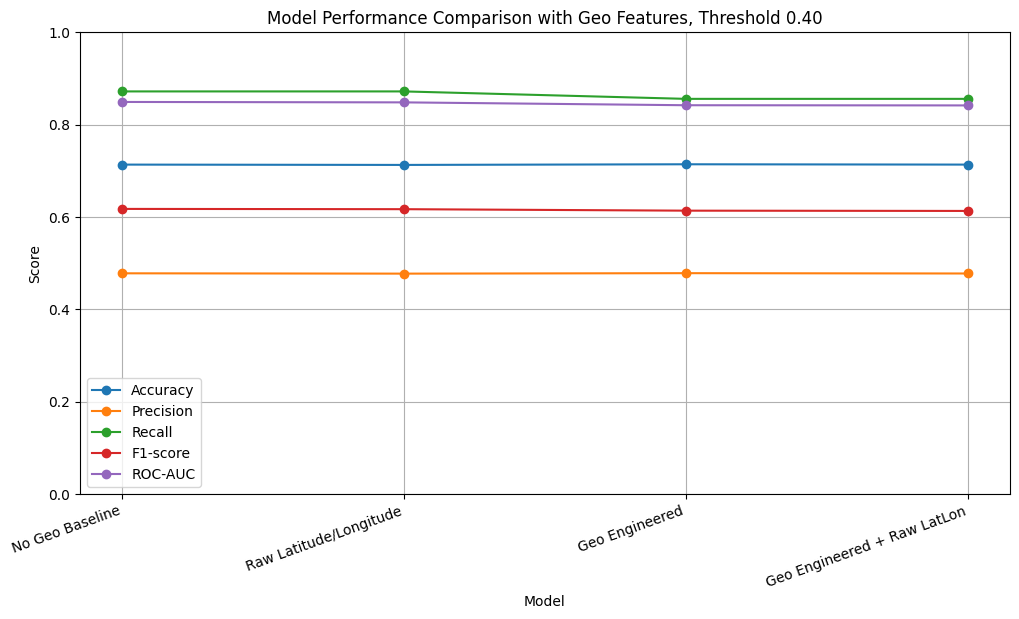

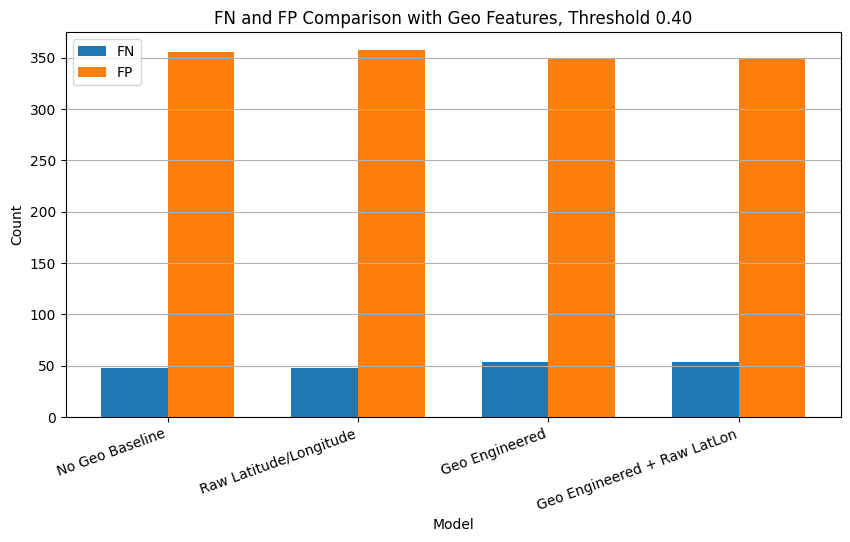

In [27]:
# =========================
# 16-4. 지역 변수 추가 실험 결과 시각화
# =========================

# Threshold 0.40 기준으로 비교
plot_df = geo_model_compare_df[geo_model_compare_df["Threshold"] == 0.40].copy()

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

plot_df_melted = plot_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

for metric in metrics_to_plot:
    temp = plot_df_melted[plot_df_melted["Metric"] == metric]
    plt.plot(temp["Model"], temp["Score"], marker="o", label=metric)

plt.title("Model Performance Comparison with Geo Features, Threshold 0.40")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.grid(True)
plt.legend()
plt.show()


# FN / FP 비교
plt.figure(figsize=(10, 5))

x = np.arange(len(plot_df["Model"]))
width = 0.35

plt.bar(x - width/2, plot_df["FN"], width, label="FN")
plt.bar(x + width/2, plot_df["FP"], width, label="FP")

plt.title("FN and FP Comparison with Geo Features, Threshold 0.40")
plt.xlabel("Model")
plt.ylabel("Count")
plt.xticks(x, plot_df["Model"], rotation=20, ha="right")
plt.legend()
plt.grid(axis="y")
plt.show()

지역 변수 추가 실험 결과, Latitude/Longitude를 직접 추가하거나 City_Group, Zip3_Group, Geo_Cluster로 가공하여 추가한 모델 모두 기존 No Geo Baseline 대비 뚜렷한 성능 개선을 보이지 않았다. 특히 Recall 중심 기준인 threshold 0.40에서는 기존 baseline이 Recall 0.8717, FN 48명으로 가장 우수하여, 최종 baseline에는 지역 변수를 포함하지 않는 방향이 적절하다고 판단된다.

In [28]:
# =========================
# 17. 지역 변수 가공 기준 튜닝 실험
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# 튜닝할 후보값
city_min_count_list = [10, 20, 30, 50]
zip3_min_count_list = [20, 30, 50, 100]
n_clusters_list = [4, 6, 8, 10, 12]

geo_tuning_results = []

# 비교 기준: 기존 No Geo Baseline
# 이미 위에서 만든 train_evaluate_logreg 함수 재사용
# 이미 위에서 만든 add_geo_features_train_test 함수 재사용

for city_min_count in city_min_count_list:
    for zip3_min_count in zip3_min_count_list:
        for n_clusters in n_clusters_list:

            # 지역 변수 가공
            X_train_geo_temp, X_test_geo_temp = add_geo_features_train_test(
                X_train_all,
                X_test_all,
                city_min_count=city_min_count,
                zip3_min_count=zip3_min_count,
                n_clusters=n_clusters
            )

            # 원본 City, Zip Code, Latitude, Longitude, Zip3 제거
            # 가공된 City_Group, Zip3_Group, Geo_Cluster만 사용
            X_train_temp = X_train_geo_temp.drop(
                columns=["City", "Zip Code", "Latitude", "Longitude", "Zip3"]
            )

            X_test_temp = X_test_geo_temp.drop(
                columns=["City", "Zip Code", "Latitude", "Longitude", "Zip3"]
            )

            # 모델 학습 및 평가
            model_temp, proba_temp, result_temp = train_evaluate_logreg(
                X_train_temp,
                X_test_temp,
                y_train,
                y_test,
                model_name=f"Geo_c{city_min_count}_z{zip3_min_count}_k{n_clusters}"
            )

            # threshold 0.40 결과만 추출
            result_040 = result_temp[result_temp["Threshold"] == 0.40].copy()

            result_040["city_min_count"] = city_min_count
            result_040["zip3_min_count"] = zip3_min_count
            result_040["n_clusters"] = n_clusters

            geo_tuning_results.append(result_040)

# 결과 합치기
geo_tuning_result_df = pd.concat(geo_tuning_results, axis=0).reset_index(drop=True)

print("===== 지역 변수 가공 기준 튜닝 결과, Threshold 0.40 =====")
display(
    geo_tuning_result_df.sort_values(
        by=["ROC-AUC", "Recall", "F1-score"],
        ascending=False
    ).head(20)
)

print("\n===== Recall 기준 Top 20 =====")
display(
    geo_tuning_result_df.sort_values(
        by=["Recall", "ROC-AUC", "F1-score"],
        ascending=False
    ).head(20)
)

City_Group 고유값 개수: 74
Zip3_Group 고유값 개수: 52
Geo_Cluster 고유값 개수: 4

City_Group 상위 빈도:
City_Group
Other_City       3851
Los Angeles       250
San Diego         120
San Jose           85
Sacramento         84
San Francisco      83
Fresno             50
Long Beach         43
Oakland            40
Glendale           34
Stockton           30
Berkeley           30
Bakersfield        30
Modesto            25
Riverside          25
Name: count, dtype: int64

Zip3_Group 상위 빈도:
Zip3_Group
900    255
956    238
945    231
960    230
959    216
953    203
954    198
917    189
922    187
932    184
936    182
923    177
920    158
955    145
913    141
Name: count, dtype: int64

Geo_Cluster 빈도:
Geo_Cluster
Cluster_0    2445
Cluster_1     638
Cluster_2     707
Cluster_3    1844
Name: count, dtype: int64
City_Group 고유값 개수: 74
Zip3_Group 고유값 개수: 52
Geo_Cluster 고유값 개수: 6

City_Group 상위 빈도:
City_Group
Other_City       3851
Los Angeles       250
San Diego         120
San Jose           85
Sacramento      

,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP,city_min_count,zip3_min_count,n_clusters
76,Geo_c50_z100_k6,0.4,0.7168,0.4814,0.8663,0.6189,0.8462,686,349,50,324,50,100,6
75,Geo_c50_z100_k4,0.4,0.7140,0.4785,0.8636,0.6158,0.8460,683,352,51,323,50,100,4
77,Geo_c50_z100_k8,0.4,0.7119,0.4763,0.8583,0.6126,0.8460,682,353,53,321,50,100,8
57,Geo_c30_z100_k8,0.4,0.7140,0.4783,0.8556,0.6136,0.8454,686,349,54,320,30,100,8
55,Geo_c30_z100_k4,0.4,0.7168,0.4813,0.8610,0.6174,0.8453,688,347,52,322,30,100,4
56,Geo_c30_z100_k6,0.4,0.7182,0.4828,0.8636,0.6194,0.8452,689,346,51,323,30,100,6
71,Geo_c50_z50_k6,0.4,0.7147,0.4793,0.8663,0.6171,0.8450,683,352,50,324,50,50,6
70,Geo_c50_z50_k4,0.4,0.7119,0.4764,0.8636,0.6141,0.8448,680,355,51,323,50,50,4
72,Geo_c50_z50_k8,0.4,0.7104,0.4749,0.8583,0.6114,0.8446,680,355,53,321,50,50,8
35,Geo_c20_z100_k4,0.4,0.7175,0.4820,0.8583,0.6173,0.8443,690,345,53,321,20,100,4



===== Recall 기준 Top 20 =====


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP,city_min_count,zip3_min_count,n_clusters
76,Geo_c50_z100_k6,0.4,0.7168,0.4814,0.8663,0.6189,0.8462,686,349,50,324,50,100,6
71,Geo_c50_z50_k6,0.4,0.7147,0.4793,0.8663,0.6171,0.8450,683,352,50,324,50,50,6
66,Geo_c50_z30_k6,0.4,0.7147,0.4793,0.8663,0.6171,0.8434,683,352,50,324,50,30,6
61,Geo_c50_z20_k6,0.4,0.7119,0.4765,0.8663,0.6148,0.8420,679,356,50,324,50,20,6
60,Geo_c50_z20_k4,0.4,0.7104,0.4751,0.8663,0.6136,0.8418,677,358,50,324,50,20,4
75,Geo_c50_z100_k4,0.4,0.7140,0.4785,0.8636,0.6158,0.8460,683,352,51,323,50,100,4
56,Geo_c30_z100_k6,0.4,0.7182,0.4828,0.8636,0.6194,0.8452,689,346,51,323,30,100,6
70,Geo_c50_z50_k4,0.4,0.7119,0.4764,0.8636,0.6141,0.8448,680,355,51,323,50,50,4
78,Geo_c50_z100_k10,0.4,0.7161,0.4807,0.8636,0.6176,0.8442,686,349,51,323,50,100,10
51,Geo_c30_z50_k6,0.4,0.7161,0.4807,0.8636,0.6176,0.8441,686,349,51,323,30,50,6


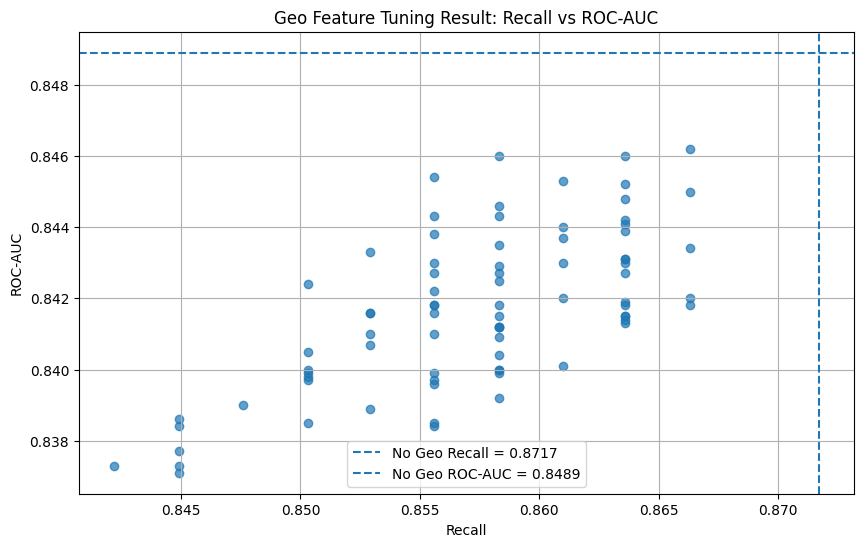

In [29]:
# =========================
# 17-1. 지역 변수 튜닝 결과 시각화
# =========================

plt.figure(figsize=(10, 6))

plt.scatter(
    geo_tuning_result_df["Recall"],
    geo_tuning_result_df["ROC-AUC"],
    alpha=0.7
)

# 기존 No Geo Baseline 기준선
no_geo_040 = geo_model_compare_df[
    (geo_model_compare_df["Model"] == "No Geo Baseline") &
    (geo_model_compare_df["Threshold"] == 0.40)
].iloc[0]

plt.axvline(
    x=no_geo_040["Recall"],
    linestyle="--",
    label=f"No Geo Recall = {no_geo_040['Recall']:.4f}"
)

plt.axhline(
    y=no_geo_040["ROC-AUC"],
    linestyle="--",
    label=f"No Geo ROC-AUC = {no_geo_040['ROC-AUC']:.4f}"
)

plt.title("Geo Feature Tuning Result: Recall vs ROC-AUC")
plt.xlabel("Recall")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()

결론

이번 추가 실험의 결론은 이렇게 잡으면 돼.

최종 Logistic Regression baseline에는
City, Zip Code, Latitude, Longitude를 포함하지 않는다.

이유는 세 가지야.

첫째, City와 Zip Code는 고유값이 너무 많고, 대부분 지역의 고객 수가 너무 적어서 그대로 쓰면 과적합 위험이 커.

둘째, Latitude, Longitude는 단순 상관계수도 거의 0에 가까웠고, 모델에 추가해도 성능 개선이 거의 없었어.

셋째, City_Group, Zip3_Group, Geo_Cluster로 가공해서 넣어도 기존 baseline보다 Recall, ROC-AUC가 개선되지 않았어.

지역 변수의 활용 가능성을 검토하기 위해 Latitude/Longitude를 직접 추가한 모델과 City_Group, Zip3_Group, Geo_Cluster를 생성한 모델을 비교하였다. 그러나 지역 변수를 추가한 모든 실험에서 기존 No Geo Baseline 대비 Recall과 ROC-AUC의 뚜렷한 개선이 나타나지 않았으므로, 최종 Logistic Regression baseline에는 지역 변수를 포함하지 않는 것으로 결정하였다.
특히 threshold 0.40 기준에서 기존 baseline은 Recall 0.8717, ROC-AUC 0.8489를 기록하였으나, 지역 변수 가공 모델들은 Recall과 ROC-AUC가 모두 기존 기준을 넘지 못하였다. 따라서 지역 정보는 이 데이터에서 이탈 예측에 일부 패턴을 보일 수는 있으나, 현재 Logistic Regression baseline의 일반화 성능을 개선하는 핵심 피처로 보기는 어렵다.

제거할 컬럼은 그대로:
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Reason",
    "Churn Score"

최종 모델에 들어가는 입력 변수는 기존 20개
수치형 변수 4개:
Tenure Months, Monthly Charges, Total Charges, CLTV

범주형 변수 16개:
Gender, Senior Citizen, Partner, Dependents,
Phone Service, Multiple Lines, Internet Service,
Online Security, Online Backup, Device Protection,
Tech Support, Streaming TV, Streaming Movies,
Contract, Paperless Billing, Payment Method


In [30]:
# =========================
# 18. 지역 변수 추가 실험 결과 저장
# =========================

import os

output_dir = "/content/drive/MyDrive/AI@Sogang_mini_project"

geo_model_compare_df.to_csv(
    os.path.join(output_dir, "geo_model_compare_summary.csv"),
    index=False
)

geo_tuning_result_df.to_csv(
    os.path.join(output_dir, "geo_feature_tuning_result.csv"),
    index=False
)

print("지역 변수 추가 실험 결과 저장 완료")
print("- geo_model_compare_summary.csv")
print("- geo_feature_tuning_result.csv")

지역 변수 추가 실험 결과 저장 완료
- geo_model_compare_summary.csv
- geo_feature_tuning_result.csv


 Churn Reason 추가 실험
Churn Reason은 모델 입력으로 쓰지 않고,
이탈 고객을 사후 분석하는 용도로 사용한다.

즉,
“최종 모델에 사용된 피처들이 어떤 이탈 사유와 연결되는가?”
“어떤 피처 조합이 특정 이탈 사유 클러스터에서 많이 나타나는가?”
“세그먼트별로 어떤 이탈 사유가 지배적인가?”
를 분석한다.

이번 실험의 목표는 이거야.

1. Churn Reason을 비슷한 사유끼리 클러스터링한다.
2. 각 Churn Reason 클러스터별 고객 특성을 비교한다.
3. 어떤 피처가 특정 이탈 사유 클러스터에서 많이 나타나는지 확인한다.
4. 세그먼트 후보를 만든다.

EX)
가격 관련 이탈군
→ Electronic check, Month-to-month, 높은 Monthly Charges가 많이 나타나는가?

서비스/지원 불만 이탈군
→ Tech Support 없음, Online Security 없음, Fiber optic 사용자가 많은가?

경쟁사 관련 이탈군
→ Month-to-month 계약, 짧은 Tenure 고객이 많은가?

In [31]:
# =========================
# 19. Churn Reason 빈도 확인 + 자동 클러스터링
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# df가 없으면 Drive에서 다시 불러오기
try:
    df
    print("기존 df 사용")
except NameError:
    file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
    df = pd.read_csv(file_path)
    print("Drive에서 df 다시 불러오기 완료")

# 이탈 고객만 Churn Reason이 존재하므로 이탈 고객만 사용
churn_reason_df = df[df["Churn Value"] == 1].copy()

print("전체 이탈 고객 수:", churn_reason_df.shape[0])
print("Churn Reason 결측치 수:", churn_reason_df["Churn Reason"].isnull().sum())

print("\n===== Churn Reason 빈도 =====")
reason_counts = churn_reason_df["Churn Reason"].value_counts().reset_index()
reason_counts.columns = ["Churn Reason", "Count"]
reason_counts["Ratio"] = reason_counts["Count"] / reason_counts["Count"].sum()

display(reason_counts)

# Churn Reason 종류 수 확인
unique_reasons = reason_counts["Churn Reason"].tolist()

print("\nChurn Reason 고유값 개수:", len(unique_reasons))
print("\nChurn Reason 목록:")
for r in unique_reasons:
    print("-", r)


# =========================
# 19-1. TF-IDF + KMeans 클러스터링
# =========================

# 고유한 Churn Reason 문장만 클러스터링
reason_texts = reason_counts["Churn Reason"].astype(str).tolist()

# TF-IDF 벡터화
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

reason_tfidf = vectorizer.fit_transform(reason_texts)

# 클러스터 개수 후보
# Churn Reason 종류가 너무 적으면 4개 정도, 많으면 5~6개 정도가 적당
n_clusters = 5

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

reason_clusters = kmeans.fit_predict(reason_tfidf)

reason_cluster_map = pd.DataFrame({
    "Churn Reason": reason_texts,
    "Reason_Cluster": reason_clusters
})

# 빈도 정보 붙이기
reason_cluster_map = reason_cluster_map.merge(
    reason_counts,
    on="Churn Reason",
    how="left"
)

reason_cluster_map = reason_cluster_map.sort_values(
    by=["Reason_Cluster", "Count"],
    ascending=[True, False]
)

print("\n===== Churn Reason 자동 클러스터링 결과 =====")
display(reason_cluster_map)


# =========================
# 19-2. 클러스터별 고객 수 요약
# =========================

churn_reason_df = churn_reason_df.merge(
    reason_cluster_map[["Churn Reason", "Reason_Cluster"]],
    on="Churn Reason",
    how="left"
)

reason_cluster_summary = churn_reason_df.groupby("Reason_Cluster").agg(
    churn_customer_count=("Churn Value", "count")
).reset_index()

reason_cluster_summary["cluster_ratio"] = (
    reason_cluster_summary["churn_customer_count"] /
    reason_cluster_summary["churn_customer_count"].sum()
)

reason_cluster_summary = reason_cluster_summary.sort_values(
    by="churn_customer_count",
    ascending=False
)

print("\n===== Churn Reason 클러스터별 고객 수 =====")
display(reason_cluster_summary)

기존 df 사용
전체 이탈 고객 수: 1869
Churn Reason 결측치 수: 0

===== Churn Reason 빈도 =====


,Churn Reason,Count,Ratio
0,Attitude of support person,192,0.102729
1,Competitor offered higher download speeds,189,0.101124
2,Competitor offered more data,162,0.086677
3,Don't know,154,0.082397
4,Competitor made better offer,140,0.074906
5,Attitude of service provider,135,0.072231
6,Competitor had better devices,130,0.069556
7,Network reliability,103,0.055110
8,Product dissatisfaction,102,0.054575
9,Price too high,98,0.052434



Churn Reason 고유값 개수: 20

Churn Reason 목록:
- Attitude of support person
- Competitor offered higher download speeds
- Competitor offered more data
- Don't know
- Competitor made better offer
- Attitude of service provider
- Competitor had better devices
- Network reliability
- Product dissatisfaction
- Price too high
- Service dissatisfaction
- Lack of self-service on Website
- Extra data charges
- Moved
- Lack of affordable download/upload speed
- Limited range of services
- Long distance charges
- Poor expertise of phone support
- Poor expertise of online support
- Deceased

===== Churn Reason 자동 클러스터링 결과 =====


,Churn Reason,Reason_Cluster,Count,Ratio
0,Attitude of support person,0,192,0.102729
17,Poor expertise of phone support,0,20,0.010701
18,Poor expertise of online support,0,19,0.010166
3,Don't know,1,154,0.082397
5,Attitude of service provider,1,135,0.072231
7,Network reliability,1,103,0.055110
8,Product dissatisfaction,1,102,0.054575
9,Price too high,1,98,0.052434
10,Service dissatisfaction,1,89,0.047619
11,Lack of self-service on Website,1,88,0.047084



===== Churn Reason 클러스터별 고객 수 =====


,Reason_Cluster,churn_customer_count,cluster_ratio
1,1,916,0.490102
2,2,351,0.187801
3,3,270,0.144462
0,0,231,0.123596
4,4,101,0.054040


Churn Reason을 TF-IDF와 KMeans로 자동 클러스터링한 결과, 일부 경쟁사 관련 사유와 요금 관련 사유는 비교적 잘 묶였으나, 하나의 클러스터에 가격, 제품, 네트워크, 기타 사유가 혼합되는 한계가 확인되었다. 따라서 최종 해석에서는 자동 클러스터링 결과를 참고하되, 이탈 사유를 의미 기반으로 재그룹화하여 세그먼트별 주요 이탈 원인을 분석하였다.

1. Churn Reason을 사람이 해석 가능한 그룹으로 다시 묶기
2. 각 Reason Group에서 어떤 피처가 많이 나타나는지 확인
3. 전체 이탈 고객 대비 특정 피처가 얼마나 많이 나타나는지 Lift 계산
4. 어떤 세그먼트가 어떤 이탈 사유와 연결되는지 확인

In [32]:
# =========================
# 20. Churn Reason 의미 기반 그룹화 + 피처 요인 분석
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df가 없으면 Drive에서 다시 불러오기
try:
    df
    print("기존 df 사용")
except NameError:
    file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
    df = pd.read_csv(file_path)
    print("Drive에서 df 다시 불러오기 완료")

# 이탈 고객만 분석
reason_analysis_df = df[df["Churn Value"] == 1].copy()

# Total Charges 숫자형 변환
reason_analysis_df["Total Charges"] = pd.to_numeric(
    reason_analysis_df["Total Charges"],
    errors="coerce"
).fillna(0)

# =========================
# 1. Churn Reason 의미 기반 그룹화
# =========================

reason_group_map = {
    # Support / Service 관련
    "Attitude of support person": "Support_Service_Issue",
    "Poor expertise of phone support": "Support_Service_Issue",
    "Poor expertise of online support": "Support_Service_Issue",
    "Attitude of service provider": "Support_Service_Issue",
    "Service dissatisfaction": "Support_Service_Issue",
    "Lack of self-service on Website": "Support_Service_Issue",

    # Competitor 관련
    "Competitor offered higher download speeds": "Competitor_Performance",
    "Competitor offered more data": "Competitor_Performance",
    "Competitor made better offer": "Competitor_Offer_Device",
    "Competitor had better devices": "Competitor_Offer_Device",

    # Price / Charge 관련
    "Price too high": "Price_Charge_Issue",
    "Extra data charges": "Price_Charge_Issue",
    "Long distance charges": "Price_Charge_Issue",

    # Product / Network 관련
    "Network reliability": "Product_Network_Issue",
    "Product dissatisfaction": "Product_Network_Issue",
    "Lack of affordable download/upload speed": "Product_Network_Issue",
    "Limited range of services": "Product_Network_Issue",

    # Other / Unknown
    "Don't know": "Other_Unknown",
    "Moved": "Other_Unknown",
    "Deceased": "Other_Unknown"
}

reason_analysis_df["Reason_Group"] = reason_analysis_df["Churn Reason"].map(reason_group_map)

print("Reason_Group 결측치 개수:", reason_analysis_df["Reason_Group"].isnull().sum())

# =========================
# 2. Reason Group별 고객 수
# =========================

reason_group_summary = reason_analysis_df.groupby("Reason_Group").agg(
    churn_customer_count=("Churn Value", "count")
).reset_index()

reason_group_summary["group_ratio"] = (
    reason_group_summary["churn_customer_count"] /
    reason_group_summary["churn_customer_count"].sum()
)

reason_group_summary = reason_group_summary.sort_values(
    by="churn_customer_count",
    ascending=False
)

print("===== 의미 기반 Churn Reason Group 요약 =====")
display(reason_group_summary)

# =========================
# 3. Reason Group별 원래 Churn Reason 구성 확인
# =========================

reason_group_detail = reason_analysis_df.groupby(
    ["Reason_Group", "Churn Reason"]
).agg(
    count=("Churn Value", "count")
).reset_index()

reason_group_detail["ratio_in_group"] = reason_group_detail.groupby(
    "Reason_Group"
)["count"].transform(lambda x: x / x.sum())

reason_group_detail = reason_group_detail.sort_values(
    by=["Reason_Group", "count"],
    ascending=[True, False]
)

print("\n===== Reason Group별 세부 Churn Reason 구성 =====")
display(reason_group_detail)

기존 df 사용
Reason_Group 결측치 개수: 0
===== 의미 기반 Churn Reason Group 요약 =====


,Reason_Group,churn_customer_count,group_ratio
5,Support_Service_Issue,543,0.290530
1,Competitor_Performance,351,0.187801
4,Product_Network_Issue,293,0.156768
0,Competitor_Offer_Device,270,0.144462
2,Other_Unknown,213,0.113965
3,Price_Charge_Issue,199,0.106474



===== Reason Group별 세부 Churn Reason 구성 =====


,Reason_Group,Churn Reason,count,ratio_in_group
1,Competitor_Offer_Device,Competitor made better offer,140,0.518519
0,Competitor_Offer_Device,Competitor had better devices,130,0.481481
2,Competitor_Performance,Competitor offered higher download speeds,189,0.538462
3,Competitor_Performance,Competitor offered more data,162,0.461538
5,Other_Unknown,Don't know,154,0.723005
6,Other_Unknown,Moved,53,0.248826
4,Other_Unknown,Deceased,6,0.028169
9,Price_Charge_Issue,Price too high,98,0.492462
7,Price_Charge_Issue,Extra data charges,57,0.286432
8,Price_Charge_Issue,Long distance charges,44,0.221106


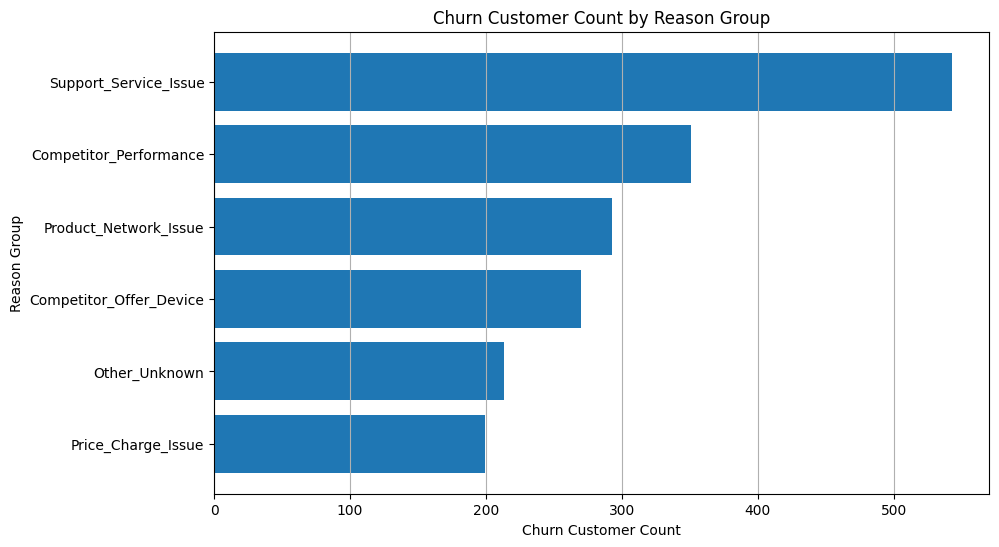

In [33]:
# =========================
# 20-1. Reason Group별 고객 수 시각화
# =========================

plt.figure(figsize=(10, 6))

plot_df = reason_group_summary.sort_values("churn_customer_count")

plt.barh(plot_df["Reason_Group"], plot_df["churn_customer_count"])

plt.title("Churn Customer Count by Reason Group")
plt.xlabel("Churn Customer Count")
plt.ylabel("Reason Group")
plt.grid(axis="x")
plt.show()

여기서는 자동 클러스터 대신, Churn Reason을 의미가 통하는 그룹으로 다시 묶는다.

분류는 이렇게 했어.

Reason Group	포함되는 사유
Support_Service_Issue	상담 태도, 서비스 제공자 태도, 지원 전문성 부족, 서비스 불만족, 웹 self-service 부족
Competitor_Performance	경쟁사가 더 빠른 다운로드 속도 또는 더 많은 데이터 제공
Competitor_Offer_Device	경쟁사가 더 좋은 조건 또는 더 좋은 기기 제공
Price_Charge_Issue	요금이 비쌈, 추가 데이터 요금, 장거리 요금
Product_Network_Issue	네트워크 신뢰성, 제품 불만족, 속도 부족, 서비스 범위 제한
Other_Unknown	모름, 이사, 사망

이 방식이 보고서 해석에는 훨씬 좋아.

In [34]:
# =========================
# 21. Reason Group별 주요 피처 분포와 Lift 계산
# =========================

# 분석할 범주형 피처
cat_features_for_reason = [
    "Contract",
    "Internet Service",
    "Payment Method",
    "Tech Support",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Paperless Billing",
    "Dependents",
    "Partner",
    "Senior Citizen",
    "Multiple Lines",
    "Streaming TV",
    "Streaming Movies"
]

# 분석할 수치형 피처
num_features_for_reason = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

# =========================
# 1. 범주형 피처 Lift 계산
# =========================

cat_lift_rows = []

for group_name in reason_analysis_df["Reason_Group"].dropna().unique():
    group_df = reason_analysis_df[reason_analysis_df["Reason_Group"] == group_name]
    group_size = len(group_df)

    for col in cat_features_for_reason:
        for value in reason_analysis_df[col].dropna().unique():
            group_count = (group_df[col] == value).sum()
            total_count = (reason_analysis_df[col] == value).sum()

            group_rate = group_count / group_size
            overall_rate = total_count / len(reason_analysis_df)

            if overall_rate == 0:
                lift = np.nan
            else:
                lift = group_rate / overall_rate

            cat_lift_rows.append({
                "Reason_Group": group_name,
                "Feature": col,
                "Value": value,
                "group_count": group_count,
                "group_rate": group_rate,
                "overall_churner_rate": overall_rate,
                "lift": lift
            })

cat_lift_df = pd.DataFrame(cat_lift_rows)

# 너무 적은 count는 해석에서 제외
cat_lift_filtered = cat_lift_df[
    cat_lift_df["group_count"] >= 20
].copy()

# 각 Reason Group별 lift가 높은 피처 Top 10
top_lift_by_group = cat_lift_filtered.sort_values(
    by=["Reason_Group", "lift"],
    ascending=[True, False]
).groupby("Reason_Group").head(10)

print("===== Reason Group별 Lift 높은 범주형 피처 Top 10 =====")
display(top_lift_by_group)


# =========================
# 2. 각 Reason Group에서 가장 많이 나타난 피처값
# =========================

top_count_by_group = cat_lift_df.sort_values(
    by=["Reason_Group", "group_count"],
    ascending=[True, False]
).groupby("Reason_Group").head(10)

print("\n===== Reason Group별 가장 많이 나타난 범주형 피처값 Top 10 =====")
display(top_count_by_group)


# =========================
# 3. 수치형 피처 평균 비교
# =========================

num_summary_by_group = reason_analysis_df.groupby("Reason_Group")[num_features_for_reason].mean().reset_index()

overall_num_mean = reason_analysis_df[num_features_for_reason].mean().to_frame().T
overall_num_mean["Reason_Group"] = "Overall_Churners"

num_summary_compare = pd.concat(
    [overall_num_mean, num_summary_by_group],
    axis=0,
    ignore_index=True
)

print("\n===== Reason Group별 수치형 피처 평균 비교 =====")
display(num_summary_compare)

===== Reason Group별 Lift 높은 범주형 피처 Top 10 =====


,Reason_Group,Feature,Value,group_count,group_rate,overall_churner_rate,lift
6,Competitor_Offer_Device,Payment Method,Mailed check,52,0.192593,0.164794,1.168687
29,Competitor_Offer_Device,Senior Citizen,Yes,79,0.292593,0.254682,1.148856
20,Competitor_Offer_Device,Device Protection,Yes,88,0.325926,0.291600,1.117717
7,Competitor_Offer_Device,Payment Method,Electronic check,160,0.592593,0.573034,1.034132
23,Competitor_Offer_Device,Paperless Billing,No,70,0.259259,0.250936,1.033167
13,Competitor_Offer_Device,Online Security,Yes,44,0.162963,0.157838,1.032467
37,Competitor_Offer_Device,Streaming Movies,Yes,122,0.451852,0.437667,1.032410
17,Competitor_Offer_Device,Online Backup,No,183,0.677778,0.659711,1.027386
30,Competitor_Offer_Device,Multiple Lines,No,126,0.466667,0.454254,1.027326
26,Competitor_Offer_Device,Partner,No,177,0.655556,0.642055,1.021028



===== Reason Group별 가장 많이 나타난 범주형 피처값 Top 10 =====


,Reason_Group,Feature,Value,group_count,group_rate,overall_churner_rate,lift
24,Competitor_Offer_Device,Dependents,No,258,0.955556,0.943285,1.013008
0,Competitor_Offer_Device,Contract,Month-to-month,242,0.896296,0.885500,1.012192
10,Competitor_Offer_Device,Tech Support,No,211,0.781481,0.773676,1.010089
14,Competitor_Offer_Device,Online Security,No,209,0.774074,0.781701,0.990243
22,Competitor_Offer_Device,Paperless Billing,Yes,200,0.740741,0.749064,0.988889
28,Competitor_Offer_Device,Senior Citizen,No,191,0.707407,0.745318,0.949135
4,Competitor_Offer_Device,Internet Service,Fiber optic,186,0.688889,0.693954,0.992701
17,Competitor_Offer_Device,Online Backup,No,183,0.677778,0.659711,1.027386
26,Competitor_Offer_Device,Partner,No,177,0.655556,0.642055,1.021028
19,Competitor_Offer_Device,Device Protection,No,165,0.611111,0.647940,0.943160



===== Reason Group별 수치형 피처 평균 비교 =====


,Tenure Months,Monthly Charges,Total Charges,CLTV,Reason_Group
0,17.979133,74.441332,1531.796094,4149.414660,Overall_Churners
1,15.911111,74.460926,1409.997593,4168.825926,Competitor_Offer_Device
2,19.669516,75.488177,1684.728917,4188.356125,Competitor_Performance
3,17.192488,73.430516,1404.218075,4042.234742,Other_Unknown
4,19.597990,77.335930,1695.943970,4127.889447,Price_Charge_Issue
5,18.238908,72.479522,1524.612969,4170.105802,Product_Network_Issue
6,17.489871,74.149171,1487.264825,4153.357274,Support_Service_Issue


1. 현재 결과 해석

의미 기반으로 묶은 Churn Reason Group 결과는 다음과 같아.
| Reason Group            | 이탈 고객 수 |    비율 |
| ----------------------- | ------: | ----: |
| Support_Service_Issue   |     543 | 29.1% |
| Competitor_Performance  |     351 | 18.8% |
| Product_Network_Issue   |     293 | 15.7% |
| Competitor_Offer_Device |     270 | 14.4% |
| Other_Unknown           |     213 | 11.4% |
| Price_Charge_Issue      |     199 | 10.6% |
Churn Reason을 의미 기반으로 재분류한 결과, 가장 큰 이탈 사유군은 Support_Service_Issue로 전체 이탈 고객의 29.1%를 차지하였다. 이는 단순 가격 문제보다 서비스 응대, 지원 품질, 서비스 만족도와 관련된 요인이 주요 이탈 원인으로 작용할 수 있음을 시사한다.

2. Lift 결과 해석

Lift 분석은 “특정 Reason Group에서 어떤 피처값이 전체 이탈 고객 평균보다 더 많이 나타나는가”를 보는 거야.
예를 들어 Price_Charge_Issue 그룹에서는 다음 값들이 상대적으로 높게 나타났어.

Payment Method = Bank transfer (automatic), lift 1.38
Senior Citizen = Yes, lift 1.28
Online Security = Yes, lift 1.27
Multiple Lines = Yes, lift 1.20
Internet Service = Fiber optic, lift 1.06

그리고 수치형 평균을 보면 Price_Charge_Issue 그룹의 Monthly Charges 평균은 77.34로 전체 이탈 고객 평균 74.44보다 높아. 그래서 가격/요금 관련 이탈군은 실제로 월 청구액이 상대적으로 높은 고객군과 연결된다고 볼 수 있어.

보고서 문장:

Price_Charge_Issue 그룹은 전체 이탈 고객 평균보다 Monthly Charges가 높고, Senior Citizen=Yes, Multiple Lines=Yes, Fiber optic 비율이 상대적으로 높게 나타났다. 따라서 해당 그룹은 요금 부담 또는 부가 서비스 이용에 따른 비용 민감도가 이탈 사유와 연결될 가능성이 있다.

3. 가장 많이 나타난 피처값 해석

다만 “Reason Group별 가장 많이 나타난 피처값” 표를 보면, 거의 모든 그룹에서 공통적으로 많이 나타난 값들이 있어.

Dependents = No
Contract = Month-to-month
Tech Support = No
Online Security = No
Paperless Billing = Yes
Internet Service = Fiber optic

이건 이미 baseline 모델에서 이탈 확률을 높이는 주요 피처로 나왔던 것들이야.

즉 Churn Reason 그룹별로도 이탈 고객들은 대체로 비슷한 고위험 특성을 공유하고 있어.

특히 Support_Service_Issue 그룹에서는:

Dependents = No: 505명
Contract = Month-to-month: 490명
Online Security = No: 428명
Tech Support = No: 420명
Paperless Billing = Yes: 418명
Internet Service = Fiber optic: 386명

이렇게 나왔어. 즉 가장 큰 이탈 사유군인 서비스/지원 문제 그룹에서도 월 단위 계약 + 보안/기술지원 없음 + Fiber optic 사용 + 부양가족 없음 조합이 많이 나타난다.

보고서 문장:

모든 Reason Group에서 Contract=Month-to-month, Dependents=No, Tech Support=No, Online Security=No가 반복적으로 높은 빈도를 보였다. 이는 Logistic Regression baseline에서 확인된 주요 이탈 위험 피처들이 특정 이탈 사유에만 국한되지 않고, 여러 이탈 사유군에서 공통적으로 나타나는 고위험 고객 특성임을 의미한다.

4. 현재 결과만으로 볼 때 가장 좋은 세그먼트 후보

지금까지 결과를 합치면, “가장 좋은 세그먼트” 후보는 단일 피처 하나라기보다 피처 조합으로 잡는 게 좋아.

현재 가장 강한 후보는 이거야.

Month-to-month 계약
+ Fiber optic 이용
+ Tech Support 없음
+ Online Security 없음
+ Dependents 없음

이 조합이 좋은 이유는 세 가지야.

첫째, baseline Logistic Regression에서 이탈 확률을 높이는 방향으로 나온 피처들이야.

둘째, 실제 세그먼트 후보 실험에서도 이 조건 조합의 이탈률이 높게 나왔어.

셋째, Churn Reason 분석에서도 가장 큰 이탈 사유군인 Support_Service_Issue에서 이 피처들이 높은 빈도로 나타났어.

즉 리텐션 전략으로 연결하면 이렇게 말할 수 있어.

월 단위 계약이며 Fiber optic을 사용하지만,
Tech Support와 Online Security가 없는 고객은
이탈 위험이 높고, 특히 서비스/지원 관련 불만으로 이탈할 가능성이 크다.

5. 다음 추가 실험: 세그먼트별 Churn Reason 분포 확인

지금까지는 Reason Group → 피처 방향으로 봤어.

이제 마지막으로 더 좋은 분석은 반대로 보는 거야.

특정 세그먼트에 속한 이탈 고객들은
어떤 Reason Group으로 가장 많이 이탈했는가?

이걸 하면 진짜 보고서에서 세그먼트 정의와 전략 제안이 깔끔해져.

In [35]:
# =========================
# 22. 세그먼트별 Churn Reason 분포 분석
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# reason_analysis_df는 앞 단계에서 만든 이탈 고객 데이터
# Reason_Group이 포함되어 있어야 함

segment_reason_df = reason_analysis_df.copy()

# =========================
# 1. 세그먼트 후보 정의
# =========================

segment_conditions = {
    "All_Churners": np.ones(len(segment_reason_df), dtype=bool),

    "Month_to_month": (
        segment_reason_df["Contract"].eq("Month-to-month")
    ),

    "Month_to_month + Fiber_optic": (
        segment_reason_df["Contract"].eq("Month-to-month") &
        segment_reason_df["Internet Service"].eq("Fiber optic")
    ),

    "Month_to_month + Fiber_optic + No_Tech_Support": (
        segment_reason_df["Contract"].eq("Month-to-month") &
        segment_reason_df["Internet Service"].eq("Fiber optic") &
        segment_reason_df["Tech Support"].eq("No")
    ),

    "Month_to_month + Fiber_optic + No_Online_Security": (
        segment_reason_df["Contract"].eq("Month-to-month") &
        segment_reason_df["Internet Service"].eq("Fiber optic") &
        segment_reason_df["Online Security"].eq("No")
    ),

    "Month_to_month + Fiber_optic + No_Tech + No_Security": (
        segment_reason_df["Contract"].eq("Month-to-month") &
        segment_reason_df["Internet Service"].eq("Fiber optic") &
        segment_reason_df["Tech Support"].eq("No") &
        segment_reason_df["Online Security"].eq("No")
    ),

    "Month_to_month + Fiber_optic + Electronic_check": (
        segment_reason_df["Contract"].eq("Month-to-month") &
        segment_reason_df["Internet Service"].eq("Fiber optic") &
        segment_reason_df["Payment Method"].eq("Electronic check")
    ),

    "Price_sensitive_candidate": (
        segment_reason_df["Monthly Charges"] >= segment_reason_df["Monthly Charges"].quantile(0.75)
    ),

    "Short_tenure_candidate": (
        segment_reason_df["Tenure Months"] <= segment_reason_df["Tenure Months"].quantile(0.25)
    )
}

# =========================
# 2. 세그먼트별 Reason Group 분포 계산
# =========================

segment_reason_rows = []

for segment_name, condition in segment_conditions.items():
    temp = segment_reason_df[condition].copy()

    segment_size = len(temp)

    if segment_size == 0:
        continue

    reason_counts_temp = temp["Reason_Group"].value_counts()

    for reason_group, count in reason_counts_temp.items():
        segment_reason_rows.append({
            "Segment": segment_name,
            "segment_churn_customer_count": segment_size,
            "Reason_Group": reason_group,
            "reason_count": count,
            "reason_ratio_in_segment": count / segment_size
        })

segment_reason_summary = pd.DataFrame(segment_reason_rows)

print("===== 세그먼트별 Churn Reason Group 분포 =====")
display(segment_reason_summary)


# =========================
# 3. 세그먼트별 가장 많은 Reason Group 확인
# =========================

dominant_reason_by_segment = segment_reason_summary.sort_values(
    by=["Segment", "reason_count"],
    ascending=[True, False]
).groupby("Segment").head(1).reset_index(drop=True)

print("\n===== 세그먼트별 가장 많은 Churn Reason Group =====")
display(dominant_reason_by_segment)


# =========================
# 4. 보기 좋은 pivot table
# =========================

segment_reason_pivot = segment_reason_summary.pivot_table(
    index="Segment",
    columns="Reason_Group",
    values="reason_ratio_in_segment",
    fill_value=0
)

print("\n===== 세그먼트별 Reason Group 비율 Pivot Table =====")
display(segment_reason_pivot)

===== 세그먼트별 Churn Reason Group 분포 =====


,Segment,segment_churn_customer_count,Reason_Group,reason_count,reason_ratio_in_segment
0,All_Churners,1869,Support_Service_Issue,543,0.290530
1,All_Churners,1869,Competitor_Performance,351,0.187801
2,All_Churners,1869,Product_Network_Issue,293,0.156768
3,All_Churners,1869,Competitor_Offer_Device,270,0.144462
4,All_Churners,1869,Other_Unknown,213,0.113965
5,All_Churners,1869,Price_Charge_Issue,199,0.106474
6,Month_to_month,1655,Support_Service_Issue,490,0.296073
7,Month_to_month,1655,Competitor_Performance,301,0.181873
8,Month_to_month,1655,Product_Network_Issue,253,0.152870
9,Month_to_month,1655,Competitor_Offer_Device,242,0.146224



===== 세그먼트별 가장 많은 Churn Reason Group =====


,Segment,segment_churn_customer_count,Reason_Group,reason_count,reason_ratio_in_segment
0,All_Churners,1869,Support_Service_Issue,543,0.290530
1,Month_to_month,1655,Support_Service_Issue,490,0.296073
2,Month_to_month + Fiber_optic,1162,Support_Service_Issue,348,0.299484
3,Month_to_month + Fiber_optic + Electronic_check,789,Support_Service_Issue,234,0.296578
4,Month_to_month + Fiber_optic + No_Online_Security,1031,Support_Service_Issue,313,0.303589
5,Month_to_month + Fiber_optic + No_Tech + No_Se...,925,Support_Service_Issue,275,0.297297
6,Month_to_month + Fiber_optic + No_Tech_Support,1033,Support_Service_Issue,304,0.294288
7,Price_sensitive_candidate,472,Support_Service_Issue,137,0.290254
8,Short_tenure_candidate,503,Support_Service_Issue,156,0.310139



===== 세그먼트별 Reason Group 비율 Pivot Table =====


Reason_Group,Competitor_Offer_Device,Competitor_Performance,Other_Unknown,Price_Charge_Issue,Product_Network_Issue,Support_Service_Issue
Segment,,,,,,
All_Churners,0.144462,0.187801,0.113965,0.106474,0.156768,0.290530
Month_to_month,0.146224,0.181873,0.114804,0.108157,0.152870,0.296073
Month_to_month + Fiber_optic,0.142857,0.188468,0.110155,0.116179,0.142857,0.299484
Month_to_month + Fiber_optic + Electronic_check,0.149556,0.183777,0.108999,0.107731,0.153359,0.296578
Month_to_month + Fiber_optic + No_Online_Security,0.143550,0.185257,0.113482,0.110572,0.143550,0.303589
Month_to_month + Fiber_optic + No_Tech + No_Security,0.148108,0.187027,0.113514,0.114595,0.139459,0.297297
Month_to_month + Fiber_optic + No_Tech_Support,0.143272,0.189739,0.111326,0.121007,0.140368,0.294288
Price_sensitive_candidate,0.146186,0.203390,0.099576,0.120763,0.139831,0.290254
Short_tenure_candidate,0.168986,0.145129,0.127237,0.099404,0.149105,0.310139


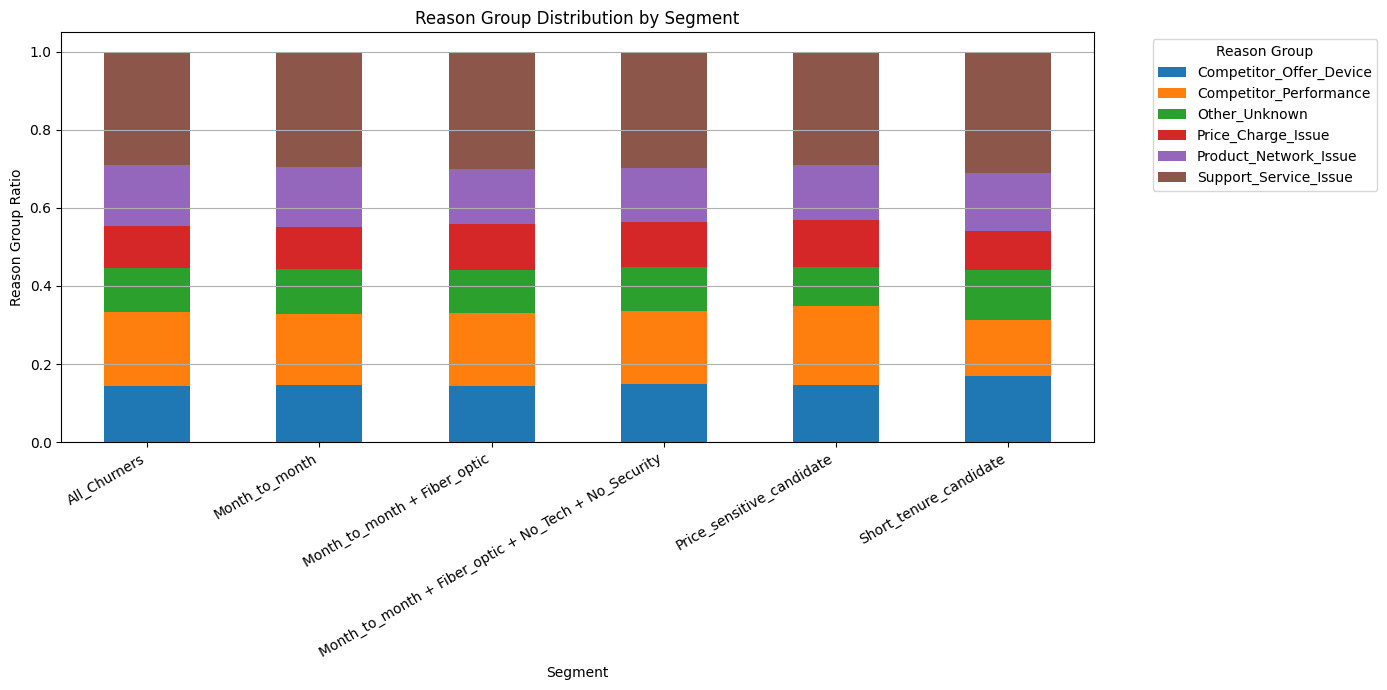

In [36]:
# =========================
# 22-1. 세그먼트별 주요 Reason Group 비율 시각화
# =========================

# 너무 복잡하지 않게 일부 주요 세그먼트만 선택
selected_segments = [
    "All_Churners",
    "Month_to_month",
    "Month_to_month + Fiber_optic",
    "Month_to_month + Fiber_optic + No_Tech + No_Security",
    "Price_sensitive_candidate",
    "Short_tenure_candidate"
]

plot_pivot = segment_reason_pivot.loc[
    [seg for seg in selected_segments if seg in segment_reason_pivot.index]
]

plot_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Reason Group Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Reason Group Ratio")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Reason Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

세그먼트별 Churn Reason Group 분포를 분석한 결과, 전체 이탈 고객뿐 아니라 월 단위 계약, Fiber optic 이용, Tech Support 미사용, Online Security 미사용 등 주요 고위험 세그먼트에서도 Support_Service_Issue가 가장 큰 이탈 사유로 나타났다. 이는 고위험군 고객의 이탈이 단순히 계약 조건이나 가격 문제에만 기인하는 것이 아니라, 고객 지원 및 서비스 경험과 밀접하게 연결될 수 있음을 시사한다.

다만 주요 고위험 세그먼트의 이탈 사유 분포는 전체 이탈 고객의 분포와 크게 다르지 않았다. 따라서 해당 세그먼트는 특정 단일 이탈 사유에 특화된 집단이라기보다, 서비스/지원 문제, 경쟁사 성능, 상품·네트워크 문제 등 다양한 이유로 이탈 위험이 전반적으로 높은 고객군으로 해석할 수 있다.

가입 기간이 짧은 고객군에서는 Support_Service_Issue와 Competitor_Offer_Device 비율이 전체 이탈 고객 대비 상대적으로 높게 나타났다. 이는 신규 고객의 초기 서비스 경험 관리와 경쟁사 대비 혜택 제공이 이탈 방지에 중요할 수 있음을 의미한다.

최종적으로 Month-to-month + Fiber optic + No Tech Support + No Online Security 조합은 모델 계수, 실제 이탈률, 이탈 사유 분석 측면에서 모두 고위험군으로 해석 가능한 세그먼트이다. 특히 해당 세그먼트에서도 Support_Service_Issue가 가장 큰 이탈 사유로 나타났으므로, 단순 가격 할인뿐 아니라 기술지원, 보안 서비스 번들, 서비스 품질 개선 중심의 리텐션 전략이 필요하다.

Churn Reason은 이탈 이후에 확인되는 사후 정보이므로 최종 예측 모델의 입력 변수로는 사용하지 않았다. 대신 이탈 고객을 대상으로 이탈 사유를 의미 기반으로 그룹화하여, 주요 고위험 세그먼트가 어떤 이유로 이탈했는지 사후 분석하였다. 분석 결과 전체 이탈 고객의 가장 큰 사유군은 Support_Service_Issue였으며, 월 단위 계약, Fiber optic 이용, Tech Support 미사용, Online Security 미사용 세그먼트에서도 동일하게 서비스/지원 관련 이탈 사유가 가장 큰 비중을 차지하였다. 따라서 본 프로젝트에서는 해당 세그먼트를 단순히 이탈 확률이 높은 고객군으로만 정의하지 않고, 서비스 지원 경험 개선이 필요한 핵심 리텐션 대상군으로 해석하였다.

In [37]:
# =========================
# 23. Churn Reason 추가 실험 결과 저장
# =========================

import os

output_dir = "/content/drive/MyDrive/AI@Sogang_mini_project"

reason_group_summary.to_csv(
    os.path.join(output_dir, "churn_reason_group_summary.csv"),
    index=False
)

reason_group_detail.to_csv(
    os.path.join(output_dir, "churn_reason_group_detail.csv"),
    index=False
)

top_lift_by_group.to_csv(
    os.path.join(output_dir, "churn_reason_feature_lift_top.csv"),
    index=False
)

top_count_by_group.to_csv(
    os.path.join(output_dir, "churn_reason_feature_count_top.csv"),
    index=False
)

num_summary_compare.to_csv(
    os.path.join(output_dir, "churn_reason_numeric_feature_summary.csv"),
    index=False
)

segment_reason_summary.to_csv(
    os.path.join(output_dir, "segment_reason_group_summary.csv"),
    index=False
)

dominant_reason_by_segment.to_csv(
    os.path.join(output_dir, "dominant_reason_by_segment.csv"),
    index=False
)

segment_reason_pivot.to_csv(
    os.path.join(output_dir, "segment_reason_group_pivot.csv")
)

print("Churn Reason 추가 실험 결과 저장 완료")
print("- churn_reason_group_summary.csv")
print("- churn_reason_group_detail.csv")
print("- churn_reason_feature_lift_top.csv")
print("- churn_reason_feature_count_top.csv")
print("- churn_reason_numeric_feature_summary.csv")
print("- segment_reason_group_summary.csv")
print("- dominant_reason_by_segment.csv")
print("- segment_reason_group_pivot.csv")

Churn Reason 추가 실험 결과 저장 완료
- churn_reason_group_summary.csv
- churn_reason_group_detail.csv
- churn_reason_feature_lift_top.csv
- churn_reason_feature_count_top.csv
- churn_reason_numeric_feature_summary.csv
- segment_reason_group_summary.csv
- dominant_reason_by_segment.csv
- segment_reason_group_pivot.csv


파일 존재 여부: True
저장 폴더 존재 여부: True

===== 원본 데이터 기본 정보 =====
데이터 크기: (7043, 33)

타깃 분포:
Churn Value
0    5174
1    1869
Name: count, dtype: int64

타깃 비율:
Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Total Charges 변환 후 결측치 개수: 11
전체 결측치 개수: 0
Baseline 데이터 크기: (7043, 21)

Baseline 컬럼:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']

===== 변수 타입 분리 =====
수치형 변수: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
범주형 변수: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless B

,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,0.30,0.6650,0.4370,0.9091,0.5903,0.8489,597,438,34,340
1,0.35,0.6891,0.4562,0.8904,0.6033,0.8489,638,397,41,333
2,0.40,0.7133,0.4780,0.8717,0.6174,0.8489,679,356,48,326
3,0.45,0.7331,0.4984,0.8289,0.6225,0.8489,723,312,64,310
4,0.50,0.7431,0.5105,0.7834,0.6181,0.8489,754,281,81,293
5,0.55,0.7580,0.5315,0.7433,0.6198,0.8489,790,245,96,278
6,0.60,0.7757,0.5604,0.7193,0.6300,0.8489,824,211,105,269



===== Logistic Regression Baseline 요약표 =====


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.5,0.7431,0.5105,0.7834,0.6181,0.8489,754,281,81,293
1,Logistic Regression,0.4,0.7133,0.4780,0.8717,0.6174,0.8489,679,356,48,326


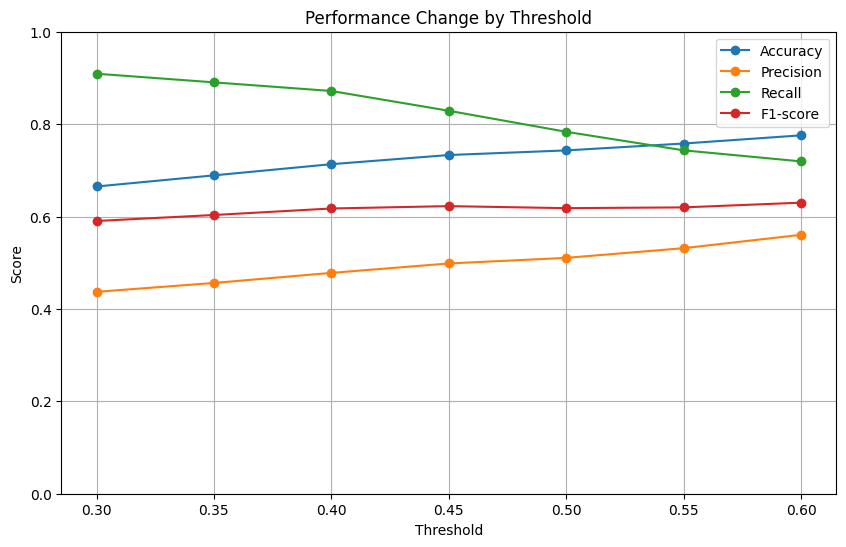

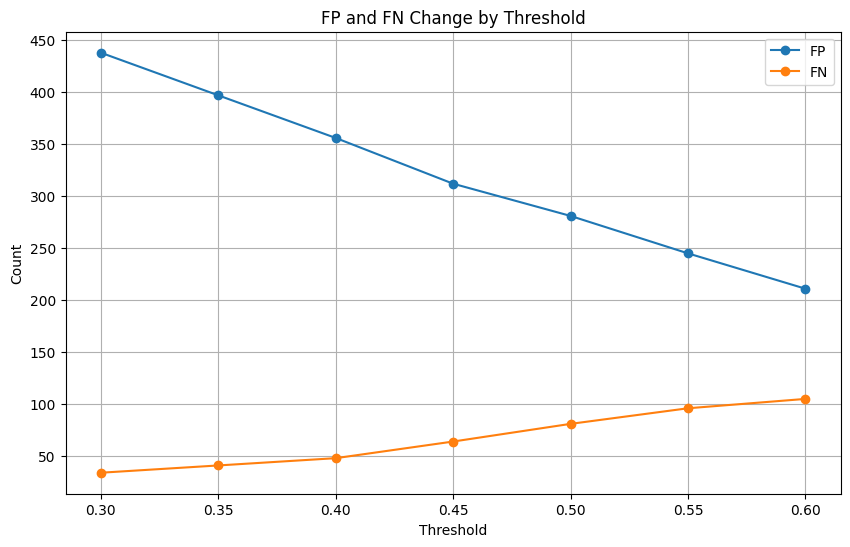

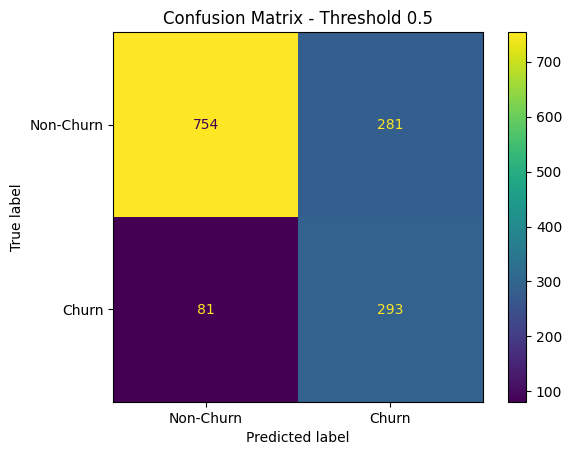

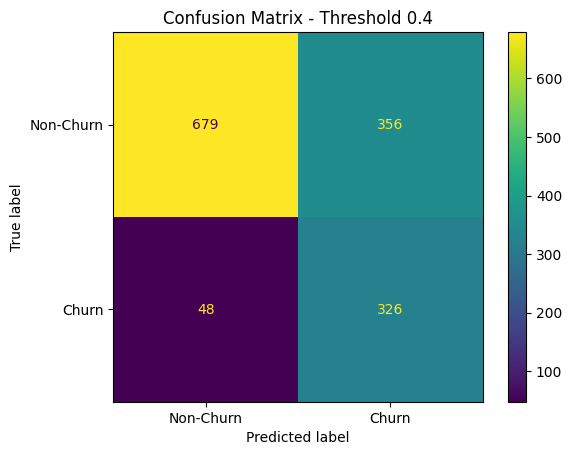


===== Curve 기반 성능 =====
ROC-AUC              : 0.8489
PR-AUC               : 0.6437
Average Precision    : 0.6449
Test 이탈 고객 비율  : 0.2654


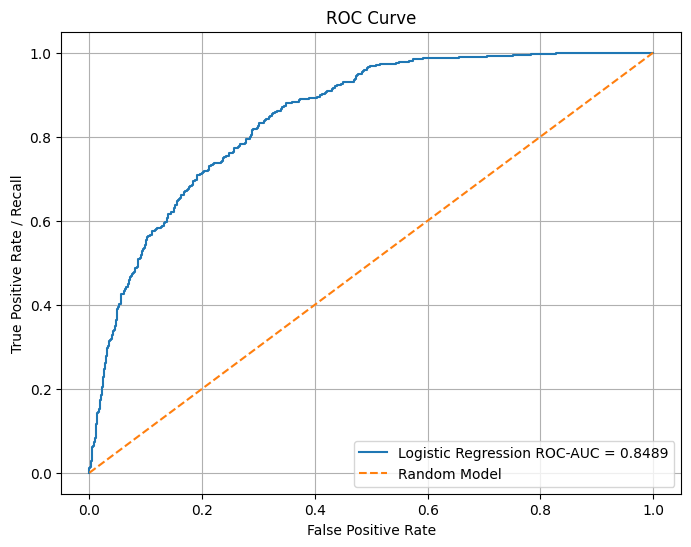

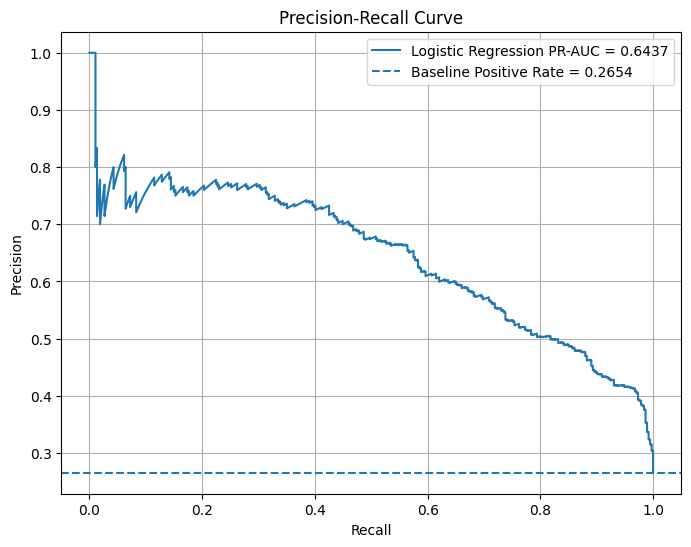


===== 이탈 확률을 높이는 변수 Top 15 =====


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
10,Dependents_No,0.701922,2.017626,0.701922
38,Contract_Month-to-month,0.655511,1.926126,0.655511
18,Internet Service_Fiber optic,0.584745,1.794534,0.584745
2,Total Charges,0.496807,1.643466,0.496807
45,Payment Method_Electronic check,0.232994,1.262374,0.232994
37,Streaming Movies_Yes,0.217737,1.243260,0.217737
34,Streaming TV_Yes,0.207444,1.230529,0.207444
20,Online Security_No,0.164267,1.178529,0.164267
29,Tech Support_No,0.145104,1.156160,0.145104
16,Multiple Lines_Yes,0.104274,1.109905,0.104274



===== 이탈 확률을 낮추는 변수 Top 15 =====


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
0,Tenure Months,-1.202455,0.300456,1.202455
11,Dependents_Yes,-0.928690,0.395071,0.928690
40,Contract_Two year,-0.750129,0.472306,0.750129
17,Internet Service_DSL,-0.557187,0.572818,0.557187
1,Monthly Charges,-0.543242,0.580862,0.543242
41,Paperless Billing_No,-0.272626,0.761378,0.272626
24,Online Backup_No internet service,-0.254327,0.775438,0.254327
21,Online Security_No internet service,-0.254327,0.775438,0.254327
30,Tech Support_No internet service,-0.254327,0.775438,0.254327
33,Streaming TV_No internet service,-0.254327,0.775438,0.254327



===== 절댓값 기준 영향력이 큰 변수 Top 20 =====


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
0,Tenure Months,-1.202455,0.300456,1.202455
11,Dependents_Yes,-0.928690,0.395071,0.928690
40,Contract_Two year,-0.750129,0.472306,0.750129
10,Dependents_No,0.701922,2.017626,0.701922
38,Contract_Month-to-month,0.655511,1.926126,0.655511
18,Internet Service_Fiber optic,0.584745,1.794534,0.584745
17,Internet Service_DSL,-0.557187,0.572818,0.557187
1,Monthly Charges,-0.543242,0.580862,0.543242
2,Total Charges,0.496807,1.643466,0.496807
41,Paperless Billing_No,-0.272626,0.761378,0.272626



===== 주요 Feature 영향 요약표 =====


,Feature,Coefficient,Odds_Ratio,Effect
0,Dependents_No,0.701922,2.017626,이탈 가능성 증가
1,Contract_Month-to-month,0.655511,1.926126,이탈 가능성 증가
2,Internet Service_Fiber optic,0.584745,1.794534,이탈 가능성 증가
3,Total Charges,0.496807,1.643466,이탈 가능성 증가
4,Payment Method_Electronic check,0.232994,1.262374,이탈 가능성 증가
5,Streaming Movies_Yes,0.217737,1.243260,이탈 가능성 증가
6,Streaming TV_Yes,0.207444,1.230529,이탈 가능성 증가
7,Online Security_No,0.164267,1.178529,이탈 가능성 증가
8,Tech Support_No,0.145104,1.156160,이탈 가능성 증가
9,Multiple Lines_Yes,0.104274,1.109905,이탈 가능성 증가


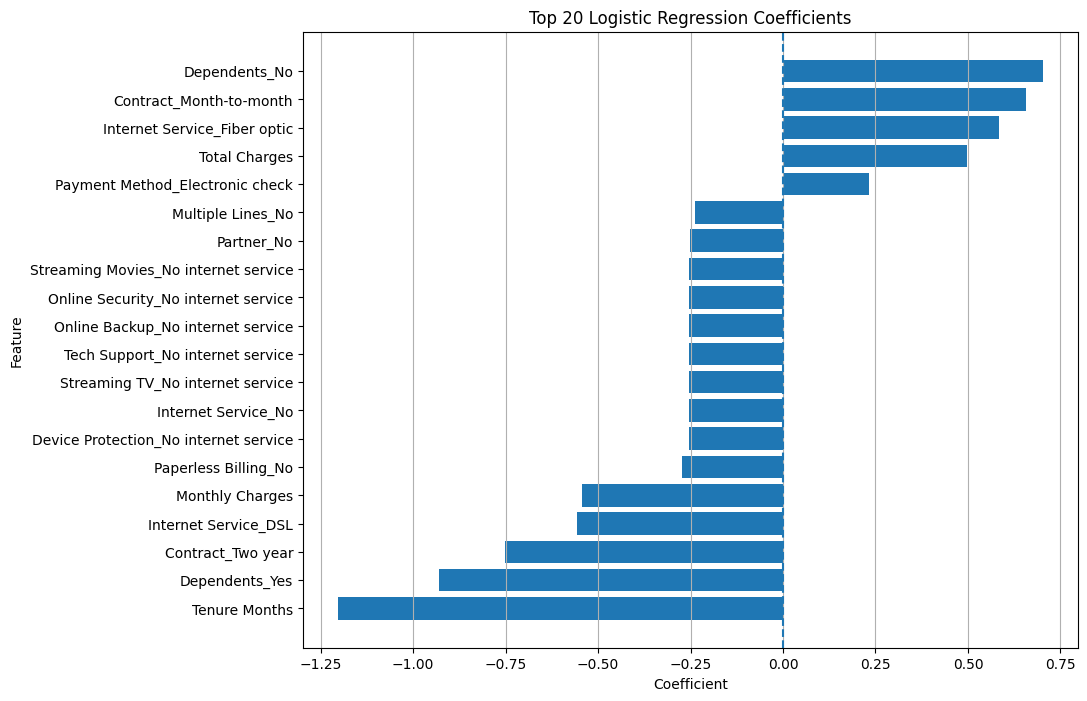


===== 예측 확률 요약 통계 =====
count    1409.000000
mean        0.407991
std         0.312882
min         0.002073
25%         0.091045
50%         0.375442
75%         0.718928
max         0.950274
Name: Churn_Probability, dtype: float64

===== 실제 이탈 여부별 예측 확률 평균 =====
Actual_Churn
0    0.306795
1    0.688040
Name: Churn_Probability, dtype: float64

===== Threshold 0.40 기준 예측 그룹별 실제 이탈률 =====


,Pred_Threshold_0.40,customer_count,actual_churn_count,actual_churn_rate
0,0,727,48,0.066025
1,1,682,326,0.478006



===== Threshold 0.50 기준 예측 그룹별 실제 이탈률 =====


,Pred_Threshold_0.50,customer_count,actual_churn_count,actual_churn_rate
0,0,835,81,0.097006
1,1,574,293,0.510453


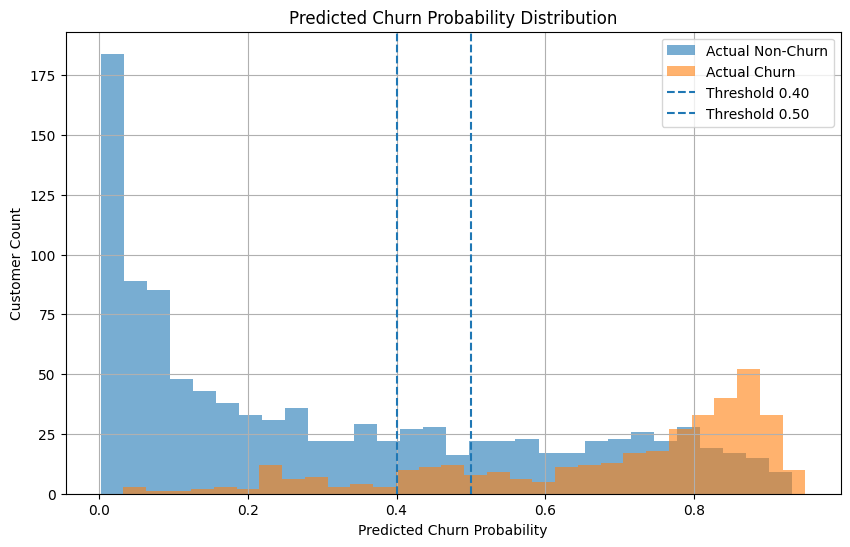


===== 예측 확률 구간별 실제 이탈률 =====


,Probability_Decile,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
0,"(0.0010699999999999998, 0.0244]",141,0,0.000000,0.011546
1,"(0.0244, 0.0658]",141,3,0.021277,0.043155
2,"(0.0658, 0.133]",141,2,0.014184,0.094149
3,"(0.133, 0.241]",141,16,0.113475,0.186961
4,"(0.241, 0.375]",141,23,0.163121,0.302448
5,"(0.375, 0.507]",140,40,0.285714,0.441399
6,"(0.507, 0.662]",141,41,0.290780,0.584232
7,"(0.662, 0.772]",141,59,0.418440,0.718856
8,"(0.772, 0.849]",141,82,0.581560,0.811744
9,"(0.849, 0.95]",141,108,0.765957,0.885662


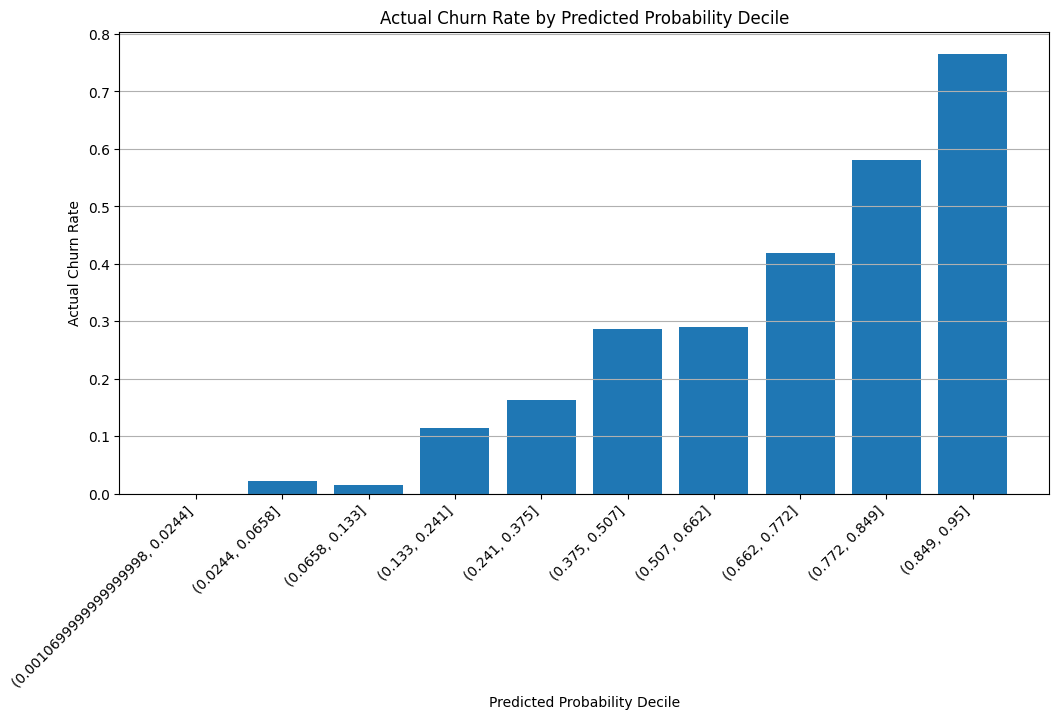


===== 예측 확률 기반 Risk Group 요약 =====


,Risk_Group,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
1,Low Risk,727,48,0.066025,0.135509
2,Medium Risk,300,94,0.313333,0.544939
0,High Risk,382,232,0.607330,0.819014


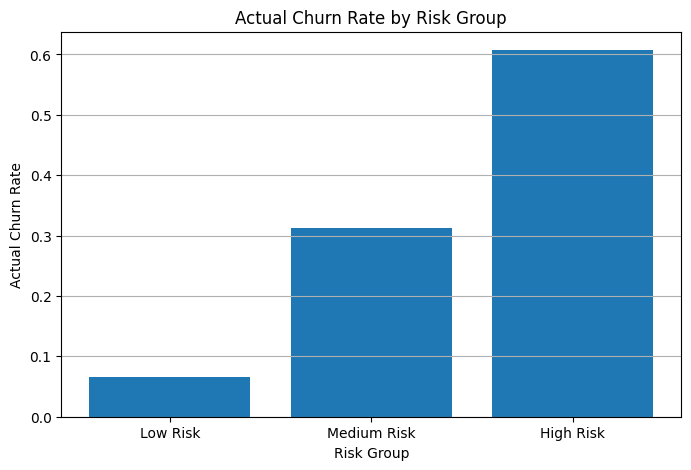


===== 주요 위험 요인 개수별 실제 이탈률 =====


,Risk_Factor_Count,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
0,0,115,0,0.000000,0.018194
1,1,242,9,0.037190,0.075678
2,2,252,38,0.150794,0.241734
3,3,182,34,0.186813,0.339623
4,4,219,62,0.283105,0.544247
5,5,216,110,0.509259,0.727676
6,6,183,121,0.661202,0.848944


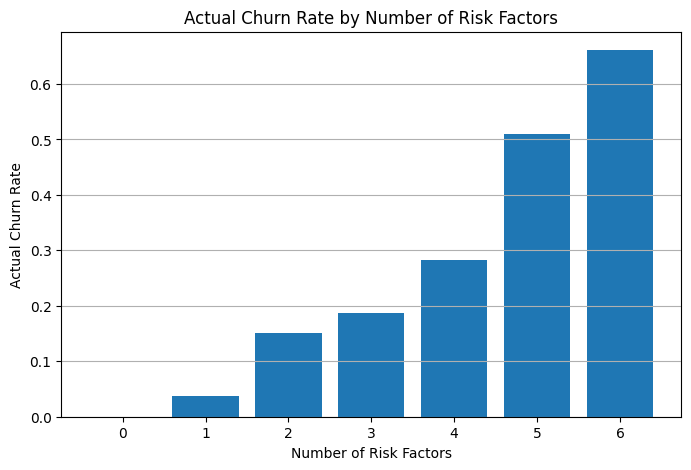


===== 세그먼트 후보별 실제 이탈률 =====


,Segment,customer_count,actual_churn_count,actual_churn_rate,avg_predicted_probability
0,Month-to-month,773,329,0.425614,0.620638
1,Month-to-month + Fiber optic,421,222,0.527316,0.749761
2,Month-to-month + Fiber optic + No Tech Support,358,205,0.572626,0.763780
3,Month-to-month + Fiber optic + Electronic check,255,148,0.580392,0.796306
4,Month-to-month + Fiber optic + No Tech Support...,306,184,0.601307,0.789569



===== 최종 Baseline 결과 저장 완료 =====
저장 위치: /content/drive/MyDrive/AI@Sogang_mini_project
- final_baseline_logistic_regression_summary.csv
- final_baseline_threshold_result.csv
- final_baseline_feature_effect_summary.csv
- final_baseline_all_coefficients.csv
- final_baseline_risk_group_summary.csv
- final_baseline_risk_factor_summary.csv
- final_baseline_segment_candidate_summary.csv
- final_baseline_probability_decile_summary.csv
- final_baseline_test_prediction_result.csv


In [38]:
# ============================================================
# Telco Customer Churn
# Final Logistic Regression Baseline Code
# ============================================================

# =========================
# 0. 기본 라이브러리 불러오기
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    ConfusionMatrixDisplay
)


# =========================
# 1. Google Drive 경로 설정
# =========================

# Colab에서 처음 실행할 경우 아래 주석 해제
# from google.colab import drive
# drive.mount("/content/drive")

file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
output_dir = "/content/drive/MyDrive/AI@Sogang_mini_project"

os.makedirs(output_dir, exist_ok=True)

print("파일 존재 여부:", os.path.exists(file_path))
print("저장 폴더 존재 여부:", os.path.exists(output_dir))


# =========================
# 2. 데이터 불러오기 및 기본 확인
# =========================

df = pd.read_csv(file_path)

print("\n===== 원본 데이터 기본 정보 =====")
print("데이터 크기:", df.shape)
print("\n타깃 분포:")
print(df["Churn Value"].value_counts())
print("\n타깃 비율:")
print(df["Churn Value"].value_counts(normalize=True) * 100)


# =========================
# 3. 최종 Baseline용 전처리
# =========================

baseline_df = df.copy()

# 최종 baseline에서 제거할 컬럼
drop_cols = [
    # ID / 상수 / 고정 정보
    "CustomerID",
    "Count",
    "Country",
    "State",

    # 지역 변수: 추가 실험 결과 최종 baseline에서는 제외
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",

    # 타깃 누수 가능 컬럼
    "Churn Label",
    "Churn Reason",
    "Churn Score"
]

baseline_df = baseline_df.drop(columns=drop_cols)

# Total Charges는 숫자처럼 보이지만 object로 저장되어 있으므로 숫자형 변환
baseline_df["Total Charges"] = pd.to_numeric(
    baseline_df["Total Charges"],
    errors="coerce"
)

print("\nTotal Charges 변환 후 결측치 개수:", baseline_df["Total Charges"].isnull().sum())

# Tenure Months가 0인 신규 고객의 누적 청구액으로 판단하여 0으로 대체
baseline_df["Total Charges"] = baseline_df["Total Charges"].fillna(0)

print("전체 결측치 개수:", baseline_df.isnull().sum().sum())
print("Baseline 데이터 크기:", baseline_df.shape)
print("\nBaseline 컬럼:")
print(baseline_df.columns.tolist())


# =========================
# 4. X, y 분리
# =========================

X = baseline_df.drop(columns=["Churn Value"])
y = baseline_df["Churn Value"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\n===== 변수 타입 분리 =====")
print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)
print("수치형 변수 개수:", len(numeric_features))
print("범주형 변수 개수:", len(categorical_features))


# =========================
# 5. Train/Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===== Train/Test Split =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTrain 타깃 비율:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest 타깃 비율:")
print(y_test.value_counts(normalize=True) * 100)


# =========================
# 6. 전처리 + Logistic Regression Pipeline
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

log_reg_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

log_reg_baseline.fit(X_train, y_train)

print("\nLogistic Regression Baseline 학습 완료")


# =========================
# 7. 기본 성능 평가, Threshold 0.50
# =========================

y_pred_050 = log_reg_baseline.predict(X_test)
y_proba = log_reg_baseline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_050)
precision = precision_score(y_test, y_pred_050)
recall = recall_score(y_test, y_pred_050)
f1 = f1_score(y_test, y_pred_050)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n===== Logistic Regression Baseline 성능, Threshold 0.50 =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_050))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_050))


# =========================
# 8. Threshold별 성능 비교
# =========================

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    y_pred_th = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_th)
    prec = precision_score(y_test, y_pred_th)
    rec = recall_score(y_test, y_pred_th)
    f1_val = f1_score(y_test, y_pred_th)
    roc_auc_val = roc_auc_score(y_test, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1_val, 4),
        "ROC-AUC": round(roc_auc_val, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_result_df = pd.DataFrame(threshold_results)

print("\n===== Threshold별 성능 비교 =====")
display(threshold_result_df)


# =========================
# 9. 최종 비교용 Threshold 0.50 / 0.40 요약표
# =========================

selected_thresholds = [0.50, 0.40]

baseline_summary = []

for threshold in selected_thresholds:
    y_pred_th = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_th)
    prec = precision_score(y_test, y_pred_th)
    rec = recall_score(y_test, y_pred_th)
    f1_val = f1_score(y_test, y_pred_th)
    roc_auc_val = roc_auc_score(y_test, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()

    baseline_summary.append({
        "Model": "Logistic Regression",
        "Threshold": threshold,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1_val, 4),
        "ROC-AUC": round(roc_auc_val, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

baseline_summary_df = pd.DataFrame(baseline_summary)

print("\n===== Logistic Regression Baseline 요약표 =====")
display(baseline_summary_df)


# =========================
# 10. Threshold별 성능 변화 그래프
# =========================

plt.figure(figsize=(10, 6))

plt.plot(threshold_result_df["Threshold"], threshold_result_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_result_df["Threshold"], threshold_result_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_result_df["Threshold"], threshold_result_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_result_df["Threshold"], threshold_result_df["F1-score"], marker="o", label="F1-score")

plt.title("Performance Change by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(threshold_result_df["Threshold"], threshold_result_df["FP"], marker="o", label="FP")
plt.plot(threshold_result_df["Threshold"], threshold_result_df["FN"], marker="o", label="FN")

plt.title("FP and FN Change by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# 11. Confusion Matrix 시각화
# =========================

for threshold in [0.50, 0.40]:
    y_pred_th = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Churn", "Churn"]
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - Threshold {threshold}")
    plt.show()


# =========================
# 12. ROC Curve / Precision-Recall Curve
# =========================

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc_value = auc(recalls, precisions)
avg_precision = average_precision_score(y_test, y_proba)

positive_rate = y_test.mean()

print("\n===== Curve 기반 성능 =====")
print(f"ROC-AUC              : {roc_auc_value:.4f}")
print(f"PR-AUC               : {pr_auc_value:.4f}")
print(f"Average Precision    : {avg_precision:.4f}")
print(f"Test 이탈 고객 비율  : {positive_rate:.4f}")

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression ROC-AUC = {roc_auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 6))

plt.plot(recalls, precisions, label=f"Logistic Regression PR-AUC = {pr_auc_value:.4f}")
plt.axhline(y=positive_rate, linestyle="--", label=f"Baseline Positive Rate = {positive_rate:.4f}")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 13. Logistic Regression 계수 해석
# =========================

model = log_reg_baseline.named_steps["model"]
preprocessor_fitted = log_reg_baseline.named_steps["preprocessor"]

num_feature_names = numeric_features
cat_feature_names = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)

feature_names = np.concatenate([num_feature_names, cat_feature_names])
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

positive_coef = coef_df.sort_values(by="Coefficient", ascending=False).head(15)
negative_coef = coef_df.sort_values(by="Coefficient", ascending=True).head(15)
important_coef = coef_df.sort_values(by="Abs_Coefficient", ascending=False).head(20)

print("\n===== 이탈 확률을 높이는 변수 Top 15 =====")
display(positive_coef)

print("\n===== 이탈 확률을 낮추는 변수 Top 15 =====")
display(negative_coef)

print("\n===== 절댓값 기준 영향력이 큰 변수 Top 20 =====")
display(important_coef)


# 보고서용 Feature 영향 요약표
top_positive_features = positive_coef[["Feature", "Coefficient", "Odds_Ratio"]].head(10).copy()
top_negative_features = negative_coef[["Feature", "Coefficient", "Odds_Ratio"]].head(10).copy()

top_positive_features["Effect"] = "이탈 가능성 증가"
top_negative_features["Effect"] = "이탈 가능성 감소"

feature_summary_df = pd.concat(
    [top_positive_features, top_negative_features],
    axis=0
).reset_index(drop=True)

print("\n===== 주요 Feature 영향 요약표 =====")
display(feature_summary_df)


# 계수 시각화
coef_plot_df = important_coef.sort_values(by="Coefficient", ascending=True).copy()

plt.figure(figsize=(10, 8))

plt.barh(coef_plot_df["Feature"], coef_plot_df["Coefficient"])
plt.axvline(x=0, linestyle="--")

plt.title("Top 20 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(axis="x")
plt.show()


# =========================
# 14. 예측 확률 기반 고위험군 확인
# =========================

test_result_df = X_test.copy()
test_result_df["Actual_Churn"] = y_test
test_result_df["Churn_Probability"] = y_proba

test_result_df["Pred_Threshold_0.50"] = (test_result_df["Churn_Probability"] >= 0.50).astype(int)
test_result_df["Pred_Threshold_0.40"] = (test_result_df["Churn_Probability"] >= 0.40).astype(int)

print("\n===== 예측 확률 요약 통계 =====")
print(test_result_df["Churn_Probability"].describe())

print("\n===== 실제 이탈 여부별 예측 확률 평균 =====")
print(test_result_df.groupby("Actual_Churn")["Churn_Probability"].mean())


threshold_040_summary = test_result_df.groupby("Pred_Threshold_0.40").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean")
).reset_index()

threshold_050_summary = test_result_df.groupby("Pred_Threshold_0.50").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean")
).reset_index()

print("\n===== Threshold 0.40 기준 예측 그룹별 실제 이탈률 =====")
display(threshold_040_summary)

print("\n===== Threshold 0.50 기준 예측 그룹별 실제 이탈률 =====")
display(threshold_050_summary)


# 실제 이탈 여부별 예측 확률 분포
plt.figure(figsize=(10, 6))

plt.hist(
    test_result_df[test_result_df["Actual_Churn"] == 0]["Churn_Probability"],
    bins=30,
    alpha=0.6,
    label="Actual Non-Churn"
)

plt.hist(
    test_result_df[test_result_df["Actual_Churn"] == 1]["Churn_Probability"],
    bins=30,
    alpha=0.6,
    label="Actual Churn"
)

plt.axvline(x=0.40, linestyle="--", label="Threshold 0.40")
plt.axvline(x=0.50, linestyle="--", label="Threshold 0.50")

plt.title("Predicted Churn Probability Distribution")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Customer Count")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 15. 예측 확률 구간별 실제 이탈률
# =========================

test_result_df["Probability_Decile"] = pd.qcut(
    test_result_df["Churn_Probability"],
    q=10,
    duplicates="drop"
)

decile_summary = test_result_df.groupby(
    "Probability_Decile",
    observed=False
).agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

print("\n===== 예측 확률 구간별 실제 이탈률 =====")
display(decile_summary)

plt.figure(figsize=(12, 6))

decile_labels = [str(x) for x in decile_summary["Probability_Decile"]]

plt.bar(decile_labels, decile_summary["actual_churn_rate"])

plt.title("Actual Churn Rate by Predicted Probability Decile")
plt.xlabel("Predicted Probability Decile")
plt.ylabel("Actual Churn Rate")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()


# =========================
# 16. Risk Group 생성
# =========================

def assign_risk_group(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

test_result_df["Risk_Group"] = test_result_df["Churn_Probability"].apply(assign_risk_group)

risk_group_summary = test_result_df.groupby("Risk_Group").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

risk_order = ["Low Risk", "Medium Risk", "High Risk"]

risk_group_summary["Risk_Group"] = pd.Categorical(
    risk_group_summary["Risk_Group"],
    categories=risk_order,
    ordered=True
)

risk_group_summary = risk_group_summary.sort_values("Risk_Group")

print("\n===== 예측 확률 기반 Risk Group 요약 =====")
display(risk_group_summary)


plt.figure(figsize=(8, 5))

plt.bar(
    risk_group_summary["Risk_Group"].astype(str),
    risk_group_summary["actual_churn_rate"]
)

plt.title("Actual Churn Rate by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Actual Churn Rate")
plt.grid(axis="y")
plt.show()


# =========================
# 17. 주요 위험 요인 개수별 이탈률
# =========================

segment_df = test_result_df.copy()

segment_df["Segment_Month_to_month"] = segment_df["Contract"].eq("Month-to-month")
segment_df["Segment_Fiber_optic"] = segment_df["Internet Service"].eq("Fiber optic")
segment_df["Segment_No_Dependents"] = segment_df["Dependents"].eq("No")
segment_df["Segment_Electronic_check"] = segment_df["Payment Method"].eq("Electronic check")
segment_df["Segment_No_Online_Security"] = segment_df["Online Security"].eq("No")
segment_df["Segment_No_Tech_Support"] = segment_df["Tech Support"].eq("No")

risk_factor_cols = [
    "Segment_Month_to_month",
    "Segment_Fiber_optic",
    "Segment_No_Dependents",
    "Segment_Electronic_check",
    "Segment_No_Online_Security",
    "Segment_No_Tech_Support"
]

segment_df["Risk_Factor_Count"] = segment_df[risk_factor_cols].sum(axis=1)

risk_factor_summary = segment_df.groupby("Risk_Factor_Count").agg(
    customer_count=("Actual_Churn", "count"),
    actual_churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Churn_Probability", "mean")
).reset_index()

print("\n===== 주요 위험 요인 개수별 실제 이탈률 =====")
display(risk_factor_summary)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_factor_summary["Risk_Factor_Count"],
    risk_factor_summary["actual_churn_rate"]
)

plt.title("Actual Churn Rate by Number of Risk Factors")
plt.xlabel("Number of Risk Factors")
plt.ylabel("Actual Churn Rate")
plt.xticks(risk_factor_summary["Risk_Factor_Count"])
plt.grid(axis="y")
plt.show()


# =========================
# 18. 세그먼트 후보별 실제 이탈률
# =========================

segment_candidates = []

conditions = {
    "Month-to-month": segment_df["Contract"].eq("Month-to-month"),

    "Month-to-month + Fiber optic": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic")
    ),

    "Month-to-month + Fiber optic + No Tech Support": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Tech Support"].eq("No")
    ),

    "Month-to-month + Fiber optic + Electronic check": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Payment Method"].eq("Electronic check")
    ),

    "Month-to-month + Fiber optic + No Tech Support + No Online Security": (
        segment_df["Contract"].eq("Month-to-month") &
        segment_df["Internet Service"].eq("Fiber optic") &
        segment_df["Tech Support"].eq("No") &
        segment_df["Online Security"].eq("No")
    )
}

for segment_name, condition in conditions.items():
    temp = segment_df[condition]

    segment_candidates.append({
        "Segment": segment_name,
        "customer_count": len(temp),
        "actual_churn_count": temp["Actual_Churn"].sum(),
        "actual_churn_rate": temp["Actual_Churn"].mean(),
        "avg_predicted_probability": temp["Churn_Probability"].mean()
    })

segment_candidate_df = pd.DataFrame(segment_candidates)

print("\n===== 세그먼트 후보별 실제 이탈률 =====")
display(segment_candidate_df)


# =========================
# 19. 결과 저장
# =========================

baseline_summary_df.to_csv(
    os.path.join(output_dir, "final_baseline_logistic_regression_summary.csv"),
    index=False
)

threshold_result_df.to_csv(
    os.path.join(output_dir, "final_baseline_threshold_result.csv"),
    index=False
)

feature_summary_df.to_csv(
    os.path.join(output_dir, "final_baseline_feature_effect_summary.csv"),
    index=False
)

coef_df.to_csv(
    os.path.join(output_dir, "final_baseline_all_coefficients.csv"),
    index=False
)

risk_group_summary.to_csv(
    os.path.join(output_dir, "final_baseline_risk_group_summary.csv"),
    index=False
)

risk_factor_summary.to_csv(
    os.path.join(output_dir, "final_baseline_risk_factor_summary.csv"),
    index=False
)

segment_candidate_df.to_csv(
    os.path.join(output_dir, "final_baseline_segment_candidate_summary.csv"),
    index=False
)

decile_summary.to_csv(
    os.path.join(output_dir, "final_baseline_probability_decile_summary.csv"),
    index=False
)

test_result_df.to_csv(
    os.path.join(output_dir, "final_baseline_test_prediction_result.csv"),
    index=False
)

print("\n===== 최종 Baseline 결과 저장 완료 =====")
print("저장 위치:", output_dir)
print("- final_baseline_logistic_regression_summary.csv")
print("- final_baseline_threshold_result.csv")
print("- final_baseline_feature_effect_summary.csv")
print("- final_baseline_all_coefficients.csv")
print("- final_baseline_risk_group_summary.csv")
print("- final_baseline_risk_factor_summary.csv")
print("- final_baseline_segment_candidate_summary.csv")
print("- final_baseline_probability_decile_summary.csv")
print("- final_baseline_test_prediction_result.csv")

보고서에는 이렇게 정리하면 돼.

최종 baseline 모델은 Logistic Regression으로 구성하였다. 모델 입력 변수에서는 고객 식별자, 상수 컬럼, 지역 변수, 그리고 이탈 이후에 알 수 있는 Churn Label, Churn Reason, Churn Score를 제거하였다. Total Charges는 숫자형으로 변환하였고, 가입 기간이 0개월인 신규 고객에서 발생한 결측치는 누적 청구액이 없는 것으로 판단하여 0으로 대체하였다. 이후 수치형 변수에는 StandardScaler, 범주형 변수에는 OneHotEncoder를 적용하고, class_weight="balanced"를 사용하여 이탈 고객 클래스의 불균형을 보정하였다.

최종 baseline 성능 설명은 이렇게 쓰면 돼.

Logistic Regression baseline 모델은 threshold 0.50 기준에서 Recall 0.7834, ROC-AUC 0.8489를 기록하였다. 이탈 고객 탐지를 우선하는 프로젝트 목적에 따라 threshold를 0.40으로 낮춘 결과 Recall은 0.8717로 증가하고 FN은 81명에서 48명으로 감소하였다. 따라서 본 baseline에서는 threshold 0.40을 Recall 중심 운영 기준 후보로 설정하였다.

지역 변수 제외 설명은 이렇게 연결하면 돼.

추가 실험으로 Latitude/Longitude, City_Group, Zip3_Group, Geo_Cluster를 활용한 지역 변수 모델을 비교하였으나 기존 baseline 대비 Recall과 ROC-AUC 개선이 확인되지 않았다. 따라서 최종 baseline 모델에는 지역 변수를 포함하지 않았다.

1단계: 고위험군 세그먼트 후보 정의

이전 Logistic Regression baseline에서 중요하게 나왔던 이탈 증가 요인은 대략 다음이었어.

Contract = Month-to-month

Internet Service = Fiber optic

Tech Support = No

Online Security = No

Payment Method = Electronic check

Dependents = No

Tenure Months 낮음

기존 df 사용
데이터 크기: (7043, 33)
전체 이탈률: 0.2653698707936959

Tenure Months 하위 25% 기준: 9.0

===== 위험 요인 개수별 이탈률 =====


,Risk_Factor_Count,customer_count,churn_count,churn_rate,avg_tenure,avg_monthly_charges
0,0,517,0,0.000000,49.110251,35.606286
1,1,1193,32,0.026823,47.313495,47.020159
2,2,989,82,0.082912,41.062690,63.622245
3,3,1099,184,0.167425,31.883530,63.151001
4,4,898,231,0.257238,32.577951,74.789421
5,5,1023,448,0.437928,24.377322,75.102444
6,6,866,540,0.623557,16.988453,78.852945
7,7,458,352,0.768559,3.491266,80.808734



===== 세그먼트 후보별 이탈률 =====


,Segment,customer_count,churn_count,churn_rate,coverage_total_customers,coverage_churn_customers,avg_tenure,avg_monthly_charges
0,Risk factors >= 6,1324,892,0.673716,0.187988,0.477261,12.319486,79.529494
1,Month-to-month + Fiber optic + No Tech + No Se...,989,651,0.658241,0.140423,0.348315,16.618807,85.229828
2,Month-to-month + Fiber optic + No Tech + No Se...,1524,925,0.606955,0.216385,0.494917,18.515748,84.649541
3,Month-to-month + Fiber optic + Electronic check,1307,789,0.603673,0.185574,0.422151,19.371844,87.182938
4,Month-to-month + Fiber optic + No Online Security,1774,1031,0.581172,0.251881,0.551632,19.748591,85.959273
5,Month-to-month + Fiber optic + No Tech Support,1796,1033,0.575167,0.255005,0.552702,20.247216,85.493680
6,Risk factors >= 5,2347,1340,0.570942,0.333239,0.716961,17.575202,77.599851
7,Month-to-month + Fiber optic,2128,1162,0.546053,0.302144,0.621723,21.554981,87.021194
8,Month-to-month,3875,1655,0.427097,0.550192,0.885500,18.036645,66.398490
9,All Customers,7043,1869,0.265370,1.000000,1.000000,32.371149,64.761692


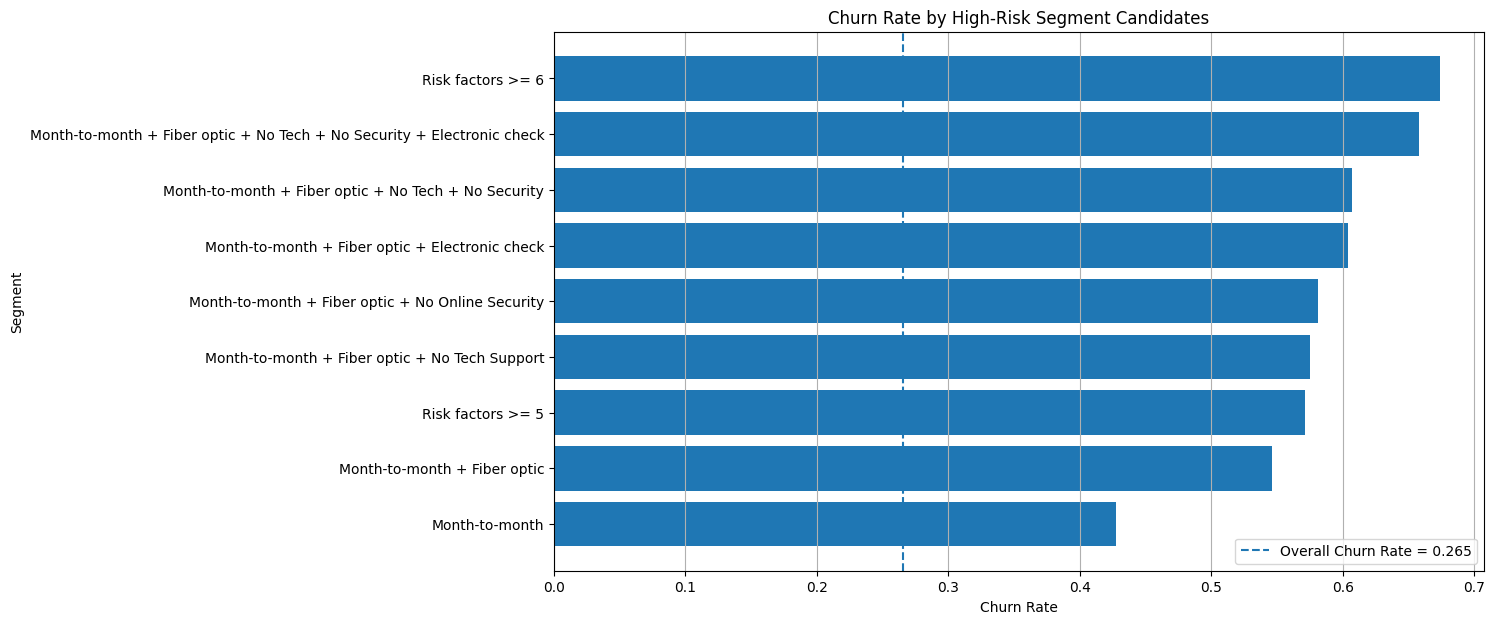

In [39]:
# ============================================================
# Segmentation & Modeling
# 1. 고위험군 세그먼트 후보 정의 및 검증
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# =========================
# 1. 데이터 준비
# =========================

# df가 없으면 Drive에서 다시 불러오기
try:
    df
    print("기존 df 사용")
except NameError:
    file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
    df = pd.read_csv(file_path)
    print("Drive에서 df 다시 불러오기 완료")

# 분석용 데이터 생성
seg_df = df.copy()

# Total Charges 숫자형 변환
seg_df["Total Charges"] = pd.to_numeric(
    seg_df["Total Charges"],
    errors="coerce"
).fillna(0)

print("데이터 크기:", seg_df.shape)
print("전체 이탈률:", seg_df["Churn Value"].mean())


# =========================
# 2. 주요 위험 조건 생성
# =========================

seg_df["Risk_Month_to_month"] = seg_df["Contract"].eq("Month-to-month")
seg_df["Risk_Fiber_optic"] = seg_df["Internet Service"].eq("Fiber optic")
seg_df["Risk_No_Tech_Support"] = seg_df["Tech Support"].eq("No")
seg_df["Risk_No_Online_Security"] = seg_df["Online Security"].eq("No")
seg_df["Risk_Electronic_check"] = seg_df["Payment Method"].eq("Electronic check")
seg_df["Risk_No_Dependents"] = seg_df["Dependents"].eq("No")

# 가입 기간 하위 25% 기준
tenure_q25 = seg_df["Tenure Months"].quantile(0.25)
seg_df["Risk_Short_Tenure"] = seg_df["Tenure Months"] <= tenure_q25

print("\nTenure Months 하위 25% 기준:", tenure_q25)


# =========================
# 3. 위험 요인 개수 계산
# =========================

risk_cols = [
    "Risk_Month_to_month",
    "Risk_Fiber_optic",
    "Risk_No_Tech_Support",
    "Risk_No_Online_Security",
    "Risk_Electronic_check",
    "Risk_No_Dependents",
    "Risk_Short_Tenure"
]

seg_df["Risk_Factor_Count"] = seg_df[risk_cols].sum(axis=1)

risk_count_summary = seg_df.groupby("Risk_Factor_Count").agg(
    customer_count=("Churn Value", "count"),
    churn_count=("Churn Value", "sum"),
    churn_rate=("Churn Value", "mean"),
    avg_tenure=("Tenure Months", "mean"),
    avg_monthly_charges=("Monthly Charges", "mean")
).reset_index()

print("\n===== 위험 요인 개수별 이탈률 =====")
display(risk_count_summary)


# =========================
# 4. 세그먼트 후보 정의
# =========================

segment_conditions = {
    "All Customers": np.ones(len(seg_df), dtype=bool),

    "Month-to-month": (
        seg_df["Contract"].eq("Month-to-month")
    ),

    "Month-to-month + Fiber optic": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic")
    ),

    "Month-to-month + Fiber optic + No Tech Support": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Tech Support"].eq("No")
    ),

    "Month-to-month + Fiber optic + No Online Security": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Online Security"].eq("No")
    ),

    "Month-to-month + Fiber optic + No Tech + No Security": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Tech Support"].eq("No") &
        seg_df["Online Security"].eq("No")
    ),

    "Month-to-month + Fiber optic + Electronic check": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Payment Method"].eq("Electronic check")
    ),

    "Month-to-month + Fiber optic + No Tech + No Security + Electronic check": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Tech Support"].eq("No") &
        seg_df["Online Security"].eq("No") &
        seg_df["Payment Method"].eq("Electronic check")
    ),

    "Risk factors >= 5": (
        seg_df["Risk_Factor_Count"] >= 5
    ),

    "Risk factors >= 6": (
        seg_df["Risk_Factor_Count"] >= 6
    )
}

segment_rows = []

for segment_name, condition in segment_conditions.items():
    temp = seg_df[condition]

    segment_rows.append({
        "Segment": segment_name,
        "customer_count": len(temp),
        "churn_count": temp["Churn Value"].sum(),
        "churn_rate": temp["Churn Value"].mean(),
        "coverage_total_customers": len(temp) / len(seg_df),
        "coverage_churn_customers": temp["Churn Value"].sum() / seg_df["Churn Value"].sum(),
        "avg_tenure": temp["Tenure Months"].mean(),
        "avg_monthly_charges": temp["Monthly Charges"].mean()
    })

segment_summary_df = pd.DataFrame(segment_rows)

segment_summary_df = segment_summary_df.sort_values(
    by="churn_rate",
    ascending=False
).reset_index(drop=True)

print("\n===== 세그먼트 후보별 이탈률 =====")
display(segment_summary_df)


# =========================
# 5. 세그먼트 이탈률 시각화
# =========================

plot_df = segment_summary_df[
    segment_summary_df["Segment"] != "All Customers"
].sort_values("churn_rate")

plt.figure(figsize=(12, 7))

plt.barh(
    plot_df["Segment"],
    plot_df["churn_rate"]
)

plt.axvline(
    x=seg_df["Churn Value"].mean(),
    linestyle="--",
    label=f"Overall Churn Rate = {seg_df['Churn Value'].mean():.3f}"
)

plt.title("Churn Rate by High-Risk Segment Candidates")
plt.xlabel("Churn Rate")
plt.ylabel("Segment")
plt.legend()
plt.grid(axis="x")
plt.show()

ogistic Regression 계수 기반으로 정의한 위험 요인 개수를 기준으로 고객을 분류한 결과, 위험 요인이 많아질수록 실제 이탈률이 단계적으로 증가하였다. 특히 위험 요인 6개 이상 고객군은 이탈률 67.4%, 전체 이탈 고객 커버율 47.7%를 보여 핵심 고위험군 세그먼트로 활용 가능하다고 판단된다

| 세그먼트     | 역할       | 기준                                                   |   이탈률 | 특징                |
| -------- | -------- | ---------------------------------------------------- | ----: | ----------------- |
| 핵심 고위험군  | 집중 관리 대상 | Risk factors ≥ 6                                     | 67.4% | 이탈률 매우 높음         |
| 확장 고위험군  | 넓은 관리 대상 | Risk factors ≥ 5                                     | 57.1% | 전체 이탈 고객 71.7% 커버 |
| 해석형 고위험군 | 전략 설명용   | Month-to-month + Fiber optic + No Tech + No Security | 60.7% | 서비스/지원 전략 연결 쉬움   |
| 일반 위험군   | 넓은 후보군   | Month-to-month + Fiber optic                         | 54.6% | 고객 수 많고 해석 쉬움     |


1순위: Risk factors >= 6
2순위: Month-to-month + Fiber optic + No Tech + No Security
3순위: Risk factors >= 5

2단계: Decision Tree 모델 적용

이제 Tree 모델을 적용해서, 우리가 사람이 만든 세그먼트와 Tree가 자동으로 찾은 분기 규칙이 비슷한지 확인할 거야.

목표는 이거야.

1. Decision Tree가 어떤 조건으로 이탈 고객을 나누는지 확인
2. Tree의 상위 분기 조건이 Logistic Regression 기반 세그먼트와 일치하는지 확인
3. Tree 모델 성능을 Logistic Regression baseline과 비교
4. Tree 규칙을 고위험군 세그먼트 정의에 활용

기존 df 사용
X_tree 크기: (7043, 20)
y_tree 크기: (7043,)

수치형 변수:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

범주형 변수:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Train 크기: (5634, 20)
Test 크기: (1409, 20)

Train 이탈률:
Churn Value
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Test 이탈률:
Churn Value
0    73.456352
1    26.543648
Name: proportion, dtype: float64

Decision Tree 모델 학습 완료

===== Decision Tree 성능 요약 =====


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Decision Tree,0.5,0.7559,0.5274,0.7727,0.6269,0.8356,776,259,85,289
1,Decision Tree,0.4,0.6700,0.4417,0.9225,0.5974,0.8356,599,436,29,345



===== Decision Tree Classification Report, Threshold 0.50 =====
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



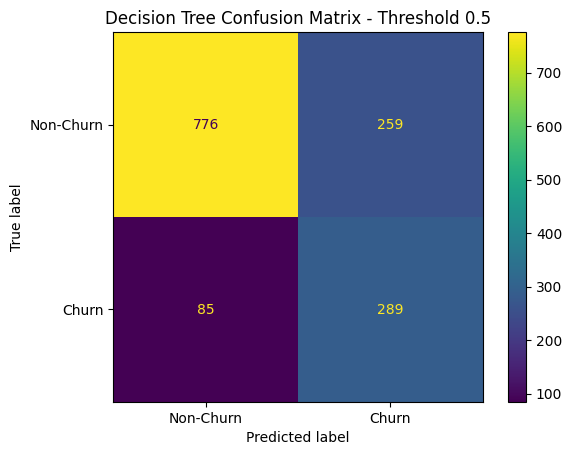

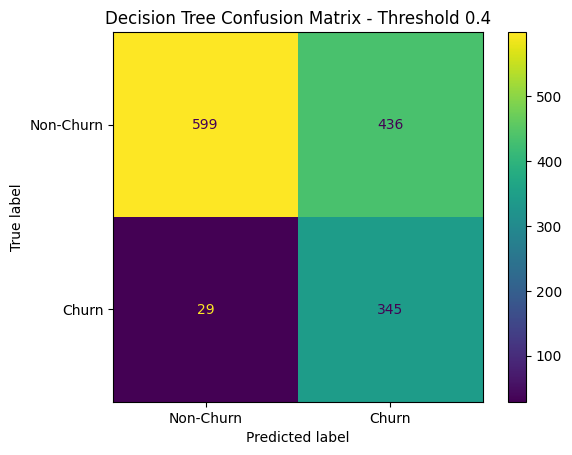

In [40]:
# ============================================================
# Segmentation & Modeling
# 2. Decision Tree 모델 적용
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# =========================
# 1. 데이터 준비
# =========================

try:
    df
    print("기존 df 사용")
except NameError:
    file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
    df = pd.read_csv(file_path)
    print("Drive에서 df 다시 불러오기 완료")

tree_df = df.copy()

# Total Charges 숫자형 변환 및 결측치 처리
tree_df["Total Charges"] = pd.to_numeric(
    tree_df["Total Charges"],
    errors="coerce"
).fillna(0)

# 최종 baseline과 동일하게 제거할 컬럼
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Reason",
    "Churn Score"
]

tree_df = tree_df.drop(columns=drop_cols)

# X, y 분리
X_tree = tree_df.drop(columns=["Churn Value"])
y_tree = tree_df["Churn Value"]

numeric_features_tree = X_tree.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_tree = X_tree.select_dtypes(include=["object"]).columns.tolist()

print("X_tree 크기:", X_tree.shape)
print("y_tree 크기:", y_tree.shape)

print("\n수치형 변수:")
print(numeric_features_tree)

print("\n범주형 변수:")
print(categorical_features_tree)


# =========================
# 2. Train/Test Split
# =========================

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

print("\nTrain 크기:", X_train_tree.shape)
print("Test 크기:", X_test_tree.shape)

print("\nTrain 이탈률:")
print(y_train_tree.value_counts(normalize=True) * 100)

print("\nTest 이탈률:")
print(y_test_tree.value_counts(normalize=True) * 100)


# =========================
# 3. Decision Tree Pipeline 구성
# =========================

# Tree 모델은 수치형 스케일링이 필수는 아님
# 범주형 변수만 OneHotEncoding 적용
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features_tree),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_tree)
    ]
)

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# 모델 학습
decision_tree_model.fit(X_train_tree, y_train_tree)

print("\nDecision Tree 모델 학습 완료")


# =========================
# 4. 예측 및 성능 평가
# =========================

y_pred_tree_050 = decision_tree_model.predict(X_test_tree)
y_proba_tree = decision_tree_model.predict_proba(X_test_tree)[:, 1]

tree_results = []

for threshold in [0.50, 0.40]:
    y_pred_tree = (y_proba_tree >= threshold).astype(int)

    acc = accuracy_score(y_test_tree, y_pred_tree)
    prec = precision_score(y_test_tree, y_pred_tree)
    rec = recall_score(y_test_tree, y_pred_tree)
    f1_val = f1_score(y_test_tree, y_pred_tree)
    roc_auc_val = roc_auc_score(y_test_tree, y_proba_tree)

    tn, fp, fn, tp = confusion_matrix(y_test_tree, y_pred_tree).ravel()

    tree_results.append({
        "Model": "Decision Tree",
        "Threshold": threshold,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1_val, 4),
        "ROC-AUC": round(roc_auc_val, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

tree_result_df = pd.DataFrame(tree_results)

print("\n===== Decision Tree 성능 요약 =====")
display(tree_result_df)

print("\n===== Decision Tree Classification Report, Threshold 0.50 =====")
print(classification_report(y_test_tree, y_pred_tree_050))


# =========================
# 5. Confusion Matrix 시각화
# =========================

for threshold in [0.50, 0.40]:
    y_pred_tree = (y_proba_tree >= threshold).astype(int)
    cm = confusion_matrix(y_test_tree, y_pred_tree)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Churn", "Churn"]
    )

    disp.plot(values_format="d")
    plt.title(f"Decision Tree Confusion Matrix - Threshold {threshold}")
    plt.show()

Decision Tree 모델은 threshold 0.50 기준에서 Accuracy 0.7559, Recall 0.7727, ROC-AUC 0.8356을 기록하였다. Threshold를 0.40으로 낮추면 Recall은 0.9225로 크게 증가하고 FN은 85명에서 29명으로 감소하였으나, FP가 259명에서 436명으로 증가하여 이탈 탐지율과 오탐 간 trade-off가 확인되었다.

여기서 중요한 해석

Decision Tree는 Logistic Regression보다 무조건 성능이 좋다기보다는, 고위험군 규칙을 뽑는 데 의미가 있는 모델이야.

즉 이번 파트의 핵심은 성능 비교보다 이거야.

Tree가 어떤 조건으로 고객을 나누는가?
그 조건이 우리가 앞서 정의한 고위험 세그먼트와 일치하는가?

그래서 다음 단계에서는 Tree를 시각화하고, 분기 규칙을 확인해야 해.

전처리 후 Feature 개수: 47

전처리 후 Feature 이름 일부:
['Tenure_Months', 'Monthly_Charges', 'Total_Charges', 'CLTV', 'Gender_Female', 'Gender_Male', 'Senior_Citizen_No', 'Senior_Citizen_Yes', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'Phone_Service_No', 'Phone_Service_Yes', 'Multiple_Lines_No', 'Multiple_Lines_No_phone_service', 'Multiple_Lines_Yes', 'Internet_Service_DSL', 'Internet_Service_Fiber_optic', 'Internet_Service_No', 'Online_Security_No', 'Online_Security_No_internet_service', 'Online_Security_Yes', 'Online_Backup_No', 'Online_Backup_No_internet_service', 'Online_Backup_Yes', 'Device_Protection_No', 'Device_Protection_No_internet_service', 'Device_Protection_Yes', 'Tech_Support_No']


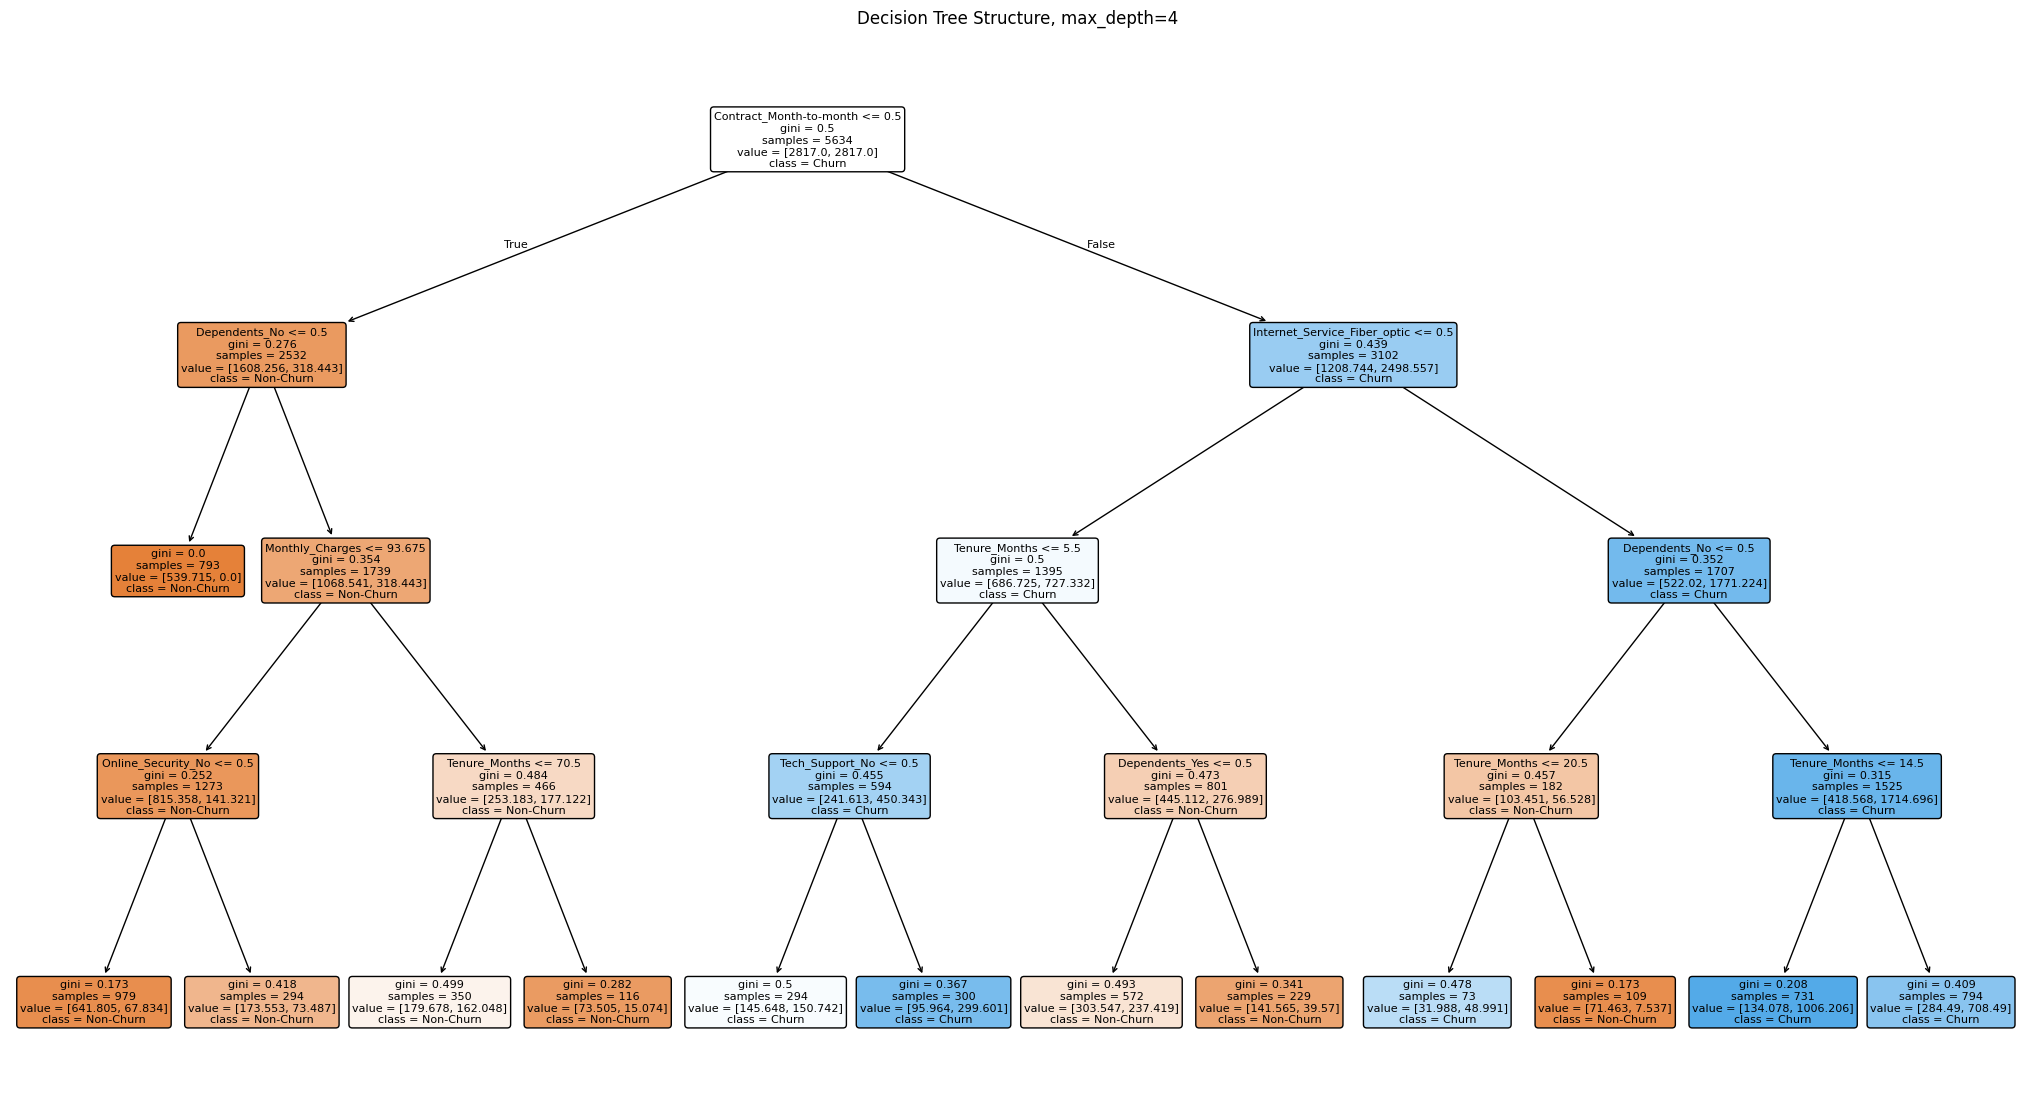

===== Decision Tree Rules =====
|--- Contract_Month-to-month <= 0.50
|   |--- Dependents_No <= 0.50
|   |   |--- class: 0
|   |--- Dependents_No >  0.50
|   |   |--- Monthly_Charges <= 93.67
|   |   |   |--- Online_Security_No <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Online_Security_No >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Monthly_Charges >  93.67
|   |   |   |--- Tenure_Months <= 70.50
|   |   |   |   |--- class: 0
|   |   |   |--- Tenure_Months >  70.50
|   |   |   |   |--- class: 0
|--- Contract_Month-to-month >  0.50
|   |--- Internet_Service_Fiber_optic <= 0.50
|   |   |--- Tenure_Months <= 5.50
|   |   |   |--- Tech_Support_No <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Tech_Support_No >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Tenure_Months >  5.50
|   |   |   |--- Dependents_Yes <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Dependents_Yes >  0.50
|   |   |   |   |--- class: 0
|   |--- Internet_Service_Fiber_optic >  0.50
| 

In [41]:
# ============================================================
# Segmentation & Modeling
# 3. Decision Tree 시각화 및 분기 규칙 해석
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree, export_text

# =========================
# 1. 학습된 Tree 모델과 전처리기 가져오기
# =========================

tree_preprocessor_fitted = decision_tree_model.named_steps["preprocessor"]
tree_estimator = decision_tree_model.named_steps["model"]

# =========================
# 2. One-Hot Encoding 이후 Feature 이름 가져오기
# =========================

# 수치형 변수 이름
num_feature_names = numeric_features_tree

# 범주형 변수 One-Hot Encoding 후 이름
cat_feature_names = tree_preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(
    categorical_features_tree
)

# 전체 feature 이름 합치기
tree_feature_names = np.concatenate([num_feature_names, cat_feature_names])

# 보기 좋게 긴 이름 일부 정리
tree_feature_names_clean = [
    name.replace(" ", "_") for name in tree_feature_names
]

print("전처리 후 Feature 개수:", len(tree_feature_names_clean))
print("\n전처리 후 Feature 이름 일부:")
print(tree_feature_names_clean[:30])


# =========================
# 3. Decision Tree 시각화
# =========================

plt.figure(figsize=(26, 14))

plot_tree(
    tree_estimator,
    feature_names=tree_feature_names_clean,
    class_names=["Non-Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=True,
    proportion=False
)

plt.title("Decision Tree Structure, max_depth=4")
plt.show()


# =========================
# 4. Text 형태로 Tree 규칙 출력
# =========================

tree_rules = export_text(
    tree_estimator,
    feature_names=list(tree_feature_names_clean),
    max_depth=4
)

print("===== Decision Tree Rules =====")
print(tree_rules)

Decision Tree의 최상위 분기 기준은 Contract_Month-to-month로 나타났다. 이는 월 단위 계약 여부가 이탈 고객과 비이탈 고객을 구분하는 핵심 조건임을 의미하며, Logistic Regression 계수 분석 결과와도 일치한다.

2. Tree가 찾은 주요 고위험 규칙

Tree 규칙을 보면, 이탈 위험이 높은 쪽은 대부분 아래 방향으로 이어져.

Month-to-month 계약
→ Fiber optic 이용
→ Dependents 없음
→ Tenure Months가 짧음 또는 중간 수준

특히 오른쪽 가지를 보면:

Contract_Month-to-month > 0.50
Internet_Service_Fiber_optic > 0.50
Dependents_No > 0.50

이 경로는 계속 class = Churn으로 끝나고 있어.

즉 Tree 기준으로도 가장 강한 고위험군은 다음과 같아.

Month-to-month
+ Fiber optic
+ Dependents 없음

그리고 Tenure Months <= 14.5인 경우는 더 강한 고위험군으로 볼 수 있어.
Tree 모델은 월 단위 계약 고객 중 Fiber optic 서비스를 이용하고 부양가족이 없는 고객을 이탈 위험이 높은 집단으로 분류하였다. 특히 가입 기간이 짧은 고객군은 이탈 클래스로 분류되어, 초기 이용 고객에 대한 관리가 중요함을 확인하였다.

Decision Tree의 주요 분기 변수는 Contract_Month-to-month, Internet Service_Fiber optic, Dependents_No, Tenure Months, Tech Support_No, Online Security_No 등으로 나타났다. 이는 Logistic Regression 기반 세그먼트 정의에서 사용한 주요 위험 요인과 대부분 일치하므로, 앞서 정의한 고위험군 세그먼트의 타당성을 Tree 모델을 통해서도 확인할 수 있다.

Tree 결과로 볼 수 있는 세그먼트 해석

Tree 기준으로 세그먼트를 정리하면 이렇게 돼.
| Tree 규칙                                                  | 해석         | 위험도   |
| -------------------------------------------------------- | ---------- | ----- |
| Month-to-month 아님                                        | 장기 계약 고객   | 낮음    |
| Month-to-month + Fiber optic 아님 + Tenure 짧음              | 신규 월 단위 고객 | 중간~높음 |
| Month-to-month + Fiber optic + Dependents 없음             | 핵심 고위험군    | 높음    |
| Month-to-month + Fiber optic + Dependents 없음 + Tenure 짧음 | 초기 이탈 고위험군 | 매우 높음 |
| Month-to-month + Fiber optic + Dependents 있음 + Tenure 길음 | 상대적으로 안정   | 낮음    |


다음 단계: Tree Leaf별 실제 이탈률 확인

지금 Tree 그림은 “분기 규칙”을 보여주지만, 보고서에 더 좋게 쓰려면 각 leaf node의 실제 이탈률을 표로 뽑는 게 좋아.
다음 단계: Tree Leaf별 실제 이탈률 확인

지금 Tree 그림은 “분기 규칙”을 보여주지만, 보고서에 더 좋게 쓰려면 각 leaf node의 실제 이탈률을 표로 뽑는 게 좋아.

===== Decision Tree Leaf별 실제 이탈률, Test 기준 =====


,Leaf_ID,customer_count,churn_count,actual_churn_rate,avg_predicted_probability,avg_tenure,avg_monthly_charges
0,23,188,130,0.691489,0.882417,5.010638,81.898404
1,14,73,43,0.589041,0.757399,2.041096,44.695205
2,24,192,81,0.421875,0.713498,34.046875,90.143490
3,13,76,28,0.368421,0.508594,2.052632,28.482895
4,20,19,7,0.368421,0.604984,9.631579,82.884211
5,8,91,25,0.274725,0.474204,53.549451,104.128571
6,16,142,31,0.218310,0.438880,22.000000,44.590493
7,21,22,4,0.181818,0.095407,41.272727,91.136364
8,6,83,9,0.108434,0.297470,45.518072,69.253012
9,17,61,5,0.081967,0.218456,27.049180,48.948361



===== Decision Tree Leaf별 주요 피처 특성 =====


,Leaf_ID,customer_count,churn_count,actual_churn_rate,month_to_month_rate,fiber_optic_rate,no_dependents_rate,no_tech_support_rate,no_online_security_rate,electronic_check_rate,avg_tenure,avg_monthly_charges
0,23,188,130,0.691489,1.0,1.000000,1.000000,0.920213,0.914894,0.675532,5.010638,81.898404
1,14,73,43,0.589041,1.0,0.000000,0.821918,1.000000,0.863014,0.493151,2.041096,44.695205
2,24,192,81,0.421875,1.0,1.000000,1.000000,0.776042,0.770833,0.567708,34.046875,90.143490
3,13,76,28,0.368421,1.0,0.000000,0.828947,0.000000,0.210526,0.184211,2.052632,28.482895
4,20,19,7,0.368421,1.0,1.000000,0.000000,0.894737,0.736842,0.368421,9.631579,82.884211
5,8,91,25,0.274725,0.0,1.000000,1.000000,0.428571,0.516484,0.461538,53.549451,104.128571
6,16,142,31,0.218310,1.0,0.000000,1.000000,0.563380,0.528169,0.295775,22.000000,44.590493
7,21,22,4,0.181818,1.0,1.000000,0.000000,0.863636,0.772727,0.545455,41.272727,91.136364
8,6,83,9,0.108434,0.0,0.240964,1.000000,0.481928,1.000000,0.156627,45.518072,69.253012
9,17,61,5,0.081967,1.0,0.000000,0.000000,0.409836,0.360656,0.311475,27.049180,48.948361


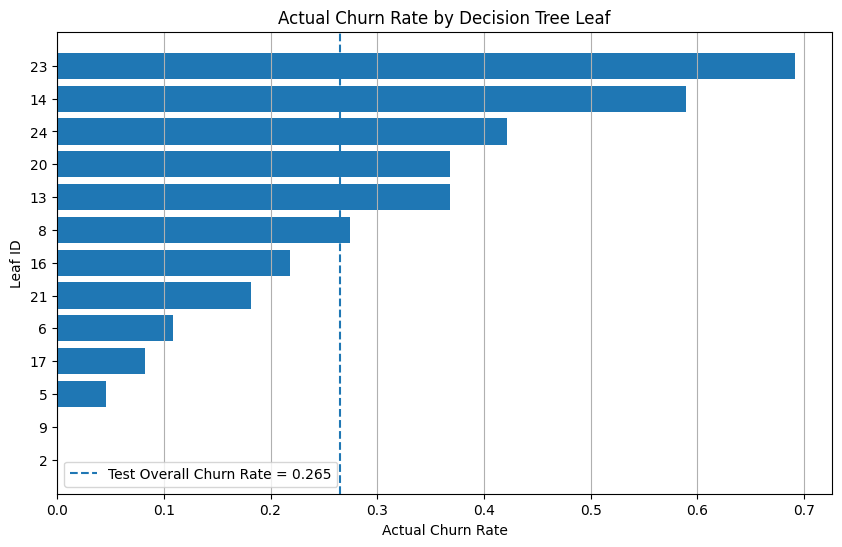

In [42]:
# ============================================================
# Segmentation & Modeling
# 4. Decision Tree Leaf별 실제 이탈률 분석
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 전처리된 train/test 데이터 생성
# =========================

X_train_tree_transformed = tree_preprocessor_fitted.transform(X_train_tree)
X_test_tree_transformed = tree_preprocessor_fitted.transform(X_test_tree)

# =========================
# 2. 각 고객이 속한 leaf node 확인
# =========================

train_leaf_id = tree_estimator.apply(X_train_tree_transformed)
test_leaf_id = tree_estimator.apply(X_test_tree_transformed)

# =========================
# 3. Test 데이터 기준 leaf summary 생성
# =========================

tree_leaf_df = X_test_tree.copy()
tree_leaf_df["Actual_Churn"] = y_test_tree.values
tree_leaf_df["Tree_Churn_Probability"] = y_proba_tree
tree_leaf_df["Leaf_ID"] = test_leaf_id

leaf_summary = tree_leaf_df.groupby("Leaf_ID").agg(
    customer_count=("Actual_Churn", "count"),
    churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    avg_predicted_probability=("Tree_Churn_Probability", "mean"),
    avg_tenure=("Tenure Months", "mean"),
    avg_monthly_charges=("Monthly Charges", "mean")
).reset_index()

leaf_summary = leaf_summary.sort_values(
    by="actual_churn_rate",
    ascending=False
).reset_index(drop=True)

print("===== Decision Tree Leaf별 실제 이탈률, Test 기준 =====")
display(leaf_summary)


# =========================
# 4. Leaf별 주요 피처 평균/비율 확인
# =========================

leaf_feature_summary = tree_leaf_df.groupby("Leaf_ID").agg(
    customer_count=("Actual_Churn", "count"),
    churn_count=("Actual_Churn", "sum"),
    actual_churn_rate=("Actual_Churn", "mean"),
    month_to_month_rate=("Contract", lambda x: (x == "Month-to-month").mean()),
    fiber_optic_rate=("Internet Service", lambda x: (x == "Fiber optic").mean()),
    no_dependents_rate=("Dependents", lambda x: (x == "No").mean()),
    no_tech_support_rate=("Tech Support", lambda x: (x == "No").mean()),
    no_online_security_rate=("Online Security", lambda x: (x == "No").mean()),
    electronic_check_rate=("Payment Method", lambda x: (x == "Electronic check").mean()),
    avg_tenure=("Tenure Months", "mean"),
    avg_monthly_charges=("Monthly Charges", "mean")
).reset_index()

leaf_feature_summary = leaf_feature_summary.sort_values(
    by="actual_churn_rate",
    ascending=False
).reset_index(drop=True)

print("\n===== Decision Tree Leaf별 주요 피처 특성 =====")
display(leaf_feature_summary)


# =========================
# 5. Leaf별 이탈률 시각화
# =========================

plt.figure(figsize=(10, 6))

plot_df = leaf_summary.sort_values("actual_churn_rate")

plt.barh(
    plot_df["Leaf_ID"].astype(str),
    plot_df["actual_churn_rate"]
)

plt.axvline(
    x=y_test_tree.mean(),
    linestyle="--",
    label=f"Test Overall Churn Rate = {y_test_tree.mean():.3f}"
)

plt.title("Actual Churn Rate by Decision Tree Leaf")
plt.xlabel("Actual Churn Rate")
plt.ylabel("Leaf ID")
plt.legend()
plt.grid(axis="x")
plt.show()

기존 seg_df 사용
Short Tenure 기준, Tenure Months <= 9.0
===== 최종 고위험군 세그먼트 비교 =====


,Segment,customer_count,churn_count,churn_rate,lift_vs_overall,coverage_total_customers,coverage_churn_customers,avg_tenure,avg_monthly_charges,avg_total_charges,electronic_check_rate,no_tech_support_rate,no_online_security_rate
0,Tree Core: Month-to-month + Fiber + No Depende...,919,664,0.722524,2.722707,0.130484,0.355270,5.314472,82.307780,448.393798,0.695321,0.909684,0.908596
1,Core High Risk: Risk factors >= 6,1324,892,0.673716,2.538781,0.187988,0.477261,12.319486,79.529494,1092.717938,0.866314,0.981118,0.975831
2,Service High Risk: Month-to-month + Fiber + No...,1524,925,0.606955,2.287205,0.216385,0.494917,18.515748,84.649541,1646.958891,0.648950,1.000000,1.000000
3,Payment Risk: Month-to-month + Fiber + Electro...,1307,789,0.603673,2.274834,0.185574,0.422151,19.371844,87.182938,1788.237261,1.000000,0.870696,0.863045
4,Tree Broad: Month-to-month + Fiber + No Depend...,1905,1121,0.588451,2.217476,0.270481,0.599786,20.766404,86.805591,1898.155459,0.625722,0.850919,0.843045
5,Broad High Risk: Risk factors >= 5,2347,1340,0.570942,2.151494,0.333239,0.716961,17.575202,77.599851,1530.214657,0.702173,0.923732,0.925437
6,All Customers,7043,1869,0.265370,1.000000,1.000000,1.000000,32.371149,64.761692,2279.734304,0.335794,0.493114,0.496663


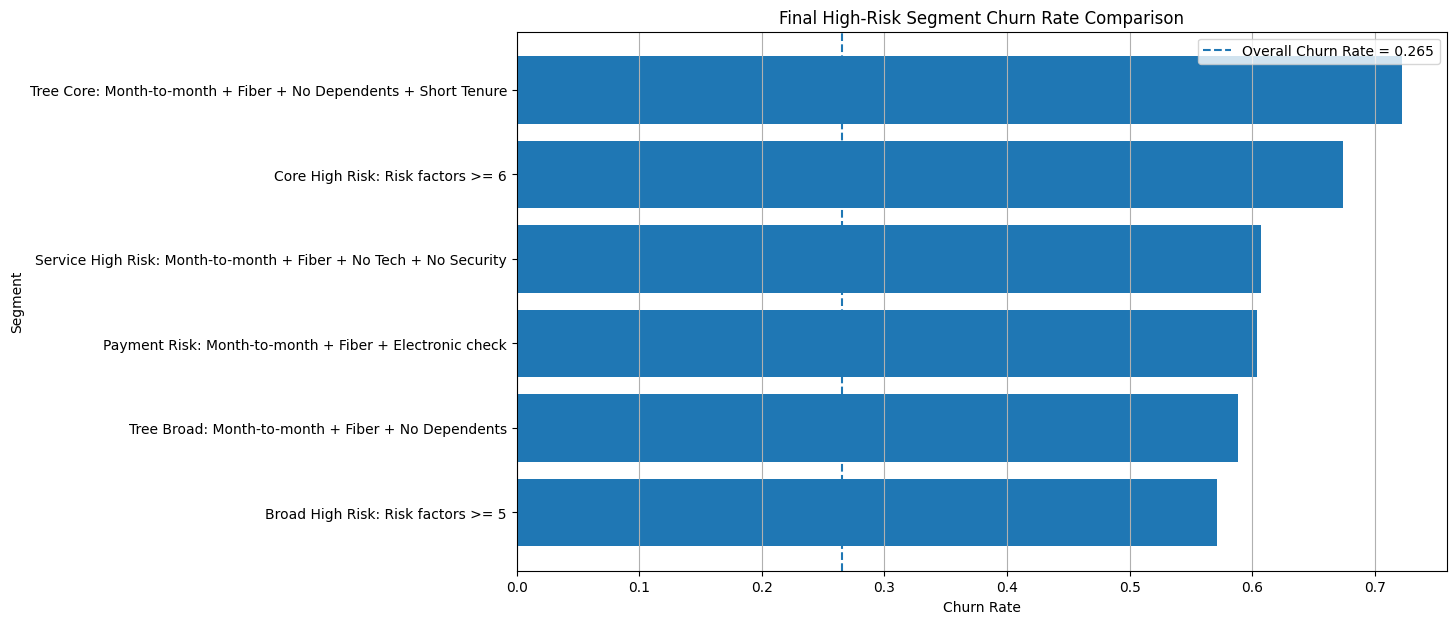

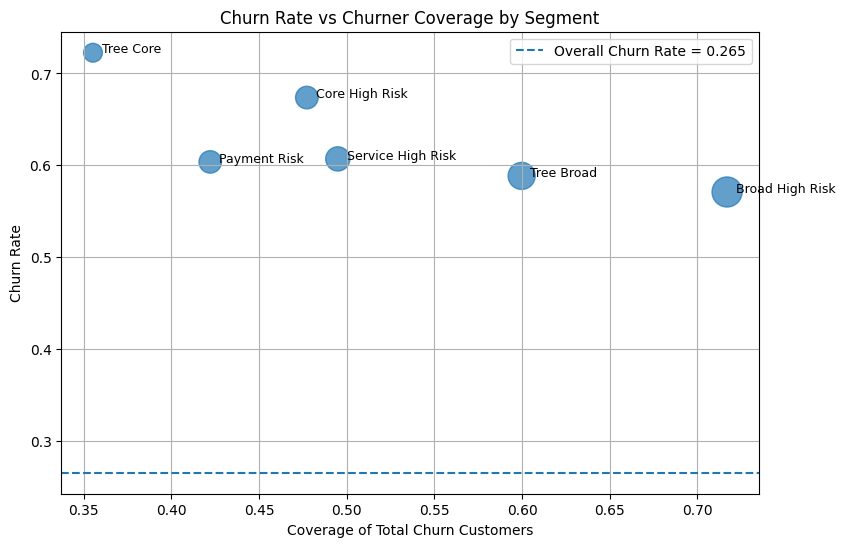

In [43]:
# ============================================================
# Segmentation & Modeling
# 5. 최종 고위험군 세그먼트 정의 및 비교
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 데이터 준비
# =========================

try:
    seg_df
    print("기존 seg_df 사용")
except NameError:
    try:
        df
        print("기존 df 사용")
    except NameError:
        file_path = "/content/drive/MyDrive/AI@Sogang_mini_project/Telco-Customer-Churn2025.csv"
        df = pd.read_csv(file_path)
        print("Drive에서 df 다시 불러오기 완료")

    seg_df = df.copy()
    seg_df["Total Charges"] = pd.to_numeric(
        seg_df["Total Charges"],
        errors="coerce"
    ).fillna(0)

# =========================
# 2. 위험 요인 재생성
# =========================

seg_df["Risk_Month_to_month"] = seg_df["Contract"].eq("Month-to-month")
seg_df["Risk_Fiber_optic"] = seg_df["Internet Service"].eq("Fiber optic")
seg_df["Risk_No_Tech_Support"] = seg_df["Tech Support"].eq("No")
seg_df["Risk_No_Online_Security"] = seg_df["Online Security"].eq("No")
seg_df["Risk_Electronic_check"] = seg_df["Payment Method"].eq("Electronic check")
seg_df["Risk_No_Dependents"] = seg_df["Dependents"].eq("No")

tenure_q25 = seg_df["Tenure Months"].quantile(0.25)
seg_df["Risk_Short_Tenure"] = seg_df["Tenure Months"] <= tenure_q25

risk_cols = [
    "Risk_Month_to_month",
    "Risk_Fiber_optic",
    "Risk_No_Tech_Support",
    "Risk_No_Online_Security",
    "Risk_Electronic_check",
    "Risk_No_Dependents",
    "Risk_Short_Tenure"
]

seg_df["Risk_Factor_Count"] = seg_df[risk_cols].sum(axis=1)

print("Short Tenure 기준, Tenure Months <=", tenure_q25)


# =========================
# 3. 최종 세그먼트 후보 정의
# =========================

final_segment_conditions = {
    "All Customers": np.ones(len(seg_df), dtype=bool),

    # Logistic Regression 기반 넓은 고위험군
    "Broad High Risk: Risk factors >= 5": (
        seg_df["Risk_Factor_Count"] >= 5
    ),

    # Logistic Regression 기반 핵심 고위험군
    "Core High Risk: Risk factors >= 6": (
        seg_df["Risk_Factor_Count"] >= 6
    ),

    # Tree Leaf 23과 가장 가까운 해석형 세그먼트
    "Tree Core: Month-to-month + Fiber + No Dependents + Short Tenure": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Dependents"].eq("No") &
        (seg_df["Tenure Months"] <= 14.5)
    ),

    # Tree에서 나온 핵심 조건 중 Tenure 제한을 뺀 버전
    "Tree Broad: Month-to-month + Fiber + No Dependents": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Dependents"].eq("No")
    ),

    # 서비스/지원 전략 연결용 세그먼트
    "Service High Risk: Month-to-month + Fiber + No Tech + No Security": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Tech Support"].eq("No") &
        seg_df["Online Security"].eq("No")
    ),

    # 비용/경쟁사 민감 가능 세그먼트
    "Payment Risk: Month-to-month + Fiber + Electronic check": (
        seg_df["Contract"].eq("Month-to-month") &
        seg_df["Internet Service"].eq("Fiber optic") &
        seg_df["Payment Method"].eq("Electronic check")
    )
}

final_segment_rows = []

overall_churn_rate = seg_df["Churn Value"].mean()
total_churners = seg_df["Churn Value"].sum()

for segment_name, condition in final_segment_conditions.items():
    temp = seg_df[condition].copy()

    customer_count = len(temp)
    churn_count = temp["Churn Value"].sum()
    churn_rate = temp["Churn Value"].mean()

    final_segment_rows.append({
        "Segment": segment_name,
        "customer_count": customer_count,
        "churn_count": churn_count,
        "churn_rate": churn_rate,
        "lift_vs_overall": churn_rate / overall_churn_rate,
        "coverage_total_customers": customer_count / len(seg_df),
        "coverage_churn_customers": churn_count / total_churners,
        "avg_tenure": temp["Tenure Months"].mean(),
        "avg_monthly_charges": temp["Monthly Charges"].mean(),
        "avg_total_charges": temp["Total Charges"].mean(),
        "electronic_check_rate": (temp["Payment Method"] == "Electronic check").mean(),
        "no_tech_support_rate": (temp["Tech Support"] == "No").mean(),
        "no_online_security_rate": (temp["Online Security"] == "No").mean()
    })

final_segment_summary_df = pd.DataFrame(final_segment_rows)

final_segment_summary_df = final_segment_summary_df.sort_values(
    by="churn_rate",
    ascending=False
).reset_index(drop=True)

print("===== 최종 고위험군 세그먼트 비교 =====")
display(final_segment_summary_df)


# =========================
# 4. 시각화
# =========================

plot_df = final_segment_summary_df[
    final_segment_summary_df["Segment"] != "All Customers"
].sort_values("churn_rate")

plt.figure(figsize=(12, 7))

plt.barh(
    plot_df["Segment"],
    plot_df["churn_rate"]
)

plt.axvline(
    x=overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn Rate = {overall_churn_rate:.3f}"
)

plt.title("Final High-Risk Segment Churn Rate Comparison")
plt.xlabel("Churn Rate")
plt.ylabel("Segment")
plt.legend()
plt.grid(axis="x")
plt.show()


# =========================
# 5. 이탈률과 커버리지 동시 확인
# =========================

plt.figure(figsize=(9, 6))

plot_df2 = final_segment_summary_df[
    final_segment_summary_df["Segment"] != "All Customers"
].copy()

plt.scatter(
    plot_df2["coverage_churn_customers"],
    plot_df2["churn_rate"],
    s=plot_df2["customer_count"] / 5,
    alpha=0.7
)

for _, row in plot_df2.iterrows():
    plt.text(
        row["coverage_churn_customers"] + 0.005,
        row["churn_rate"],
        row["Segment"].split(":")[0],
        fontsize=9
    )

plt.axhline(
    y=overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn Rate = {overall_churn_rate:.3f}"
)

plt.title("Churn Rate vs Churner Coverage by Segment")
plt.xlabel("Coverage of Total Churn Customers")
plt.ylabel("Churn Rate")
plt.grid(True)
plt.legend()
plt.show()

고위험군 세그먼트 정의를 위해 Logistic Regression에서 도출된 주요 위험 요인과 Decision Tree의 분기 규칙을 함께 활용하였다. 분석 결과, 월 단위 계약, Fiber optic 이용, 부양가족 없음, 짧은 가입 기간, Tech Support 미사용, Online Security 미사용, Electronic check 결제 방식이 반복적으로 고위험 조건으로 나타났다. 특히 Tree Core 세그먼트는 이탈률 72.3%로 가장 높은 위험도를 보였으며, Core High Risk는 이탈률 67.4%와 전체 이탈 고객 커버율 47.7%를 보여 집중 관리 대상군으로 적합하였다. 또한 Broad High Risk는 전체 이탈 고객의 71.7%를 포함하여 넓은 리텐션 관리군으로 활용 가능하다.

In [44]:
# ============================================================
# Segmentation & Modeling
# 6. 최종 세그먼트 라벨 생성 및 저장
# ============================================================

import os
import pandas as pd
import numpy as np

output_dir = "/content/drive/MyDrive/AI@Sogang_mini_project"

# =========================
# 1. 최종 세그먼트 라벨 생성
# =========================

seg_df["Segment_Tree_Core"] = (
    seg_df["Contract"].eq("Month-to-month") &
    seg_df["Internet Service"].eq("Fiber optic") &
    seg_df["Dependents"].eq("No") &
    (seg_df["Tenure Months"] <= 14.5)
)

seg_df["Segment_Core_High_Risk"] = (
    seg_df["Risk_Factor_Count"] >= 6
)

seg_df["Segment_Broad_High_Risk"] = (
    seg_df["Risk_Factor_Count"] >= 5
)

seg_df["Segment_Service_High_Risk"] = (
    seg_df["Contract"].eq("Month-to-month") &
    seg_df["Internet Service"].eq("Fiber optic") &
    seg_df["Tech Support"].eq("No") &
    seg_df["Online Security"].eq("No")
)

# =========================
# 2. 고객별 최종 Segment_Level 생성
# =========================

def assign_segment_level(row):
    if row["Segment_Tree_Core"]:
        return "1_Tree_Core"
    elif row["Segment_Core_High_Risk"]:
        return "2_Core_High_Risk"
    elif row["Segment_Broad_High_Risk"]:
        return "3_Broad_High_Risk"
    elif row["Segment_Service_High_Risk"]:
        return "4_Service_High_Risk"
    else:
        return "5_Other"

seg_df["Final_Segment_Level"] = seg_df.apply(assign_segment_level, axis=1)

# =========================
# 3. Segment_Level별 이탈률 확인
# =========================

final_segment_level_summary = seg_df.groupby("Final_Segment_Level").agg(
    customer_count=("Churn Value", "count"),
    churn_count=("Churn Value", "sum"),
    churn_rate=("Churn Value", "mean"),
    avg_tenure=("Tenure Months", "mean"),
    avg_monthly_charges=("Monthly Charges", "mean"),
    avg_risk_factor_count=("Risk_Factor_Count", "mean")
).reset_index()

final_segment_level_summary["coverage_total_customers"] = (
    final_segment_level_summary["customer_count"] / len(seg_df)
)

final_segment_level_summary["coverage_churn_customers"] = (
    final_segment_level_summary["churn_count"] / seg_df["Churn Value"].sum()
)

print("===== 최종 Segment Level별 이탈률 =====")
display(final_segment_level_summary)

# =========================
# 4. 결과 저장
# =========================

final_segment_summary_df.to_csv(
    os.path.join(output_dir, "tree_final_high_risk_segment_summary.csv"),
    index=False
)

final_segment_level_summary.to_csv(
    os.path.join(output_dir, "tree_final_segment_level_summary.csv"),
    index=False
)

seg_df.to_csv(
    os.path.join(output_dir, "telco_churn_with_final_segments.csv"),
    index=False
)

print("최종 세그먼트 결과 저장 완료")
print("- tree_final_high_risk_segment_summary.csv")
print("- tree_final_segment_level_summary.csv")
print("- telco_churn_with_final_segments.csv")

===== 최종 Segment Level별 이탈률 =====


,Final_Segment_Level,customer_count,churn_count,churn_rate,avg_tenure,avg_monthly_charges,avg_risk_factor_count,coverage_total_customers,coverage_churn_customers
0,1_Tree_Core,919,664,0.722524,5.314472,82.307780,6.315560,0.130484,0.355270
1,2_Core_High_Risk,536,314,0.585821,23.585821,76.722854,6.000000,0.076104,0.168004
2,3_Broad_High_Risk,926,383,0.413607,25.989201,73.917549,5.000000,0.131478,0.204922
3,4_Service_High_Risk,49,4,0.081633,33.632653,87.058163,4.000000,0.006957,0.002140
4,5_Other,4613,504,0.109256,40.049859,57.801604,2.109473,0.654977,0.269663


최종 세그먼트 결과 저장 완료
- tree_final_high_risk_segment_summary.csv
- tree_final_segment_level_summary.csv
- telco_churn_with_final_segments.csv


최종 Segment Level 해석
| Segment Level       | 고객 수 | 이탈 고객 수 |   이탈률 | 전체 이탈 고객 커버율 |
| ------------------- | ---: | ------: | ----: | -----------: |
| 1_Tree_Core         |  919 |     664 | 72.3% |        35.5% |
| 2_Core_High_Risk    |  536 |     314 | 58.6% |        16.8% |
| 3_Broad_High_Risk   |  926 |     383 | 41.4% |        20.5% |
| 4_Service_High_Risk |   49 |       4 |  8.2% |         0.2% |
| 5_Other             | 4613 |     504 | 10.9% |        27.0% |
가장 중요한 건 이거야.

1_Tree_Core + 2_Core_High_Risk + 3_Broad_High_Risk
= 고객 수 2381명
= 이탈 고객 1361명
= 전체 이탈 고객의 약 72.8% 포함

즉 전체 고객 중 일부 고위험군을 잡아냈는데, 그 안에 실제 이탈 고객의 대부분이 들어가 있는 구조야. 이건 세그먼트 정의가 잘 됐다는 뜻

최종 세그먼트 분석 결과, 월 단위 계약, Fiber optic 이용, 부양가족 없음, 짧은 가입 기간 등의 조건을 만족하는 Tree Core 고객군은 전체 평균 이탈률 26.5%보다 훨씬 높은 72.3%의 이탈률을 보였다. 따라서 해당 고객군은 가장 우선적으로 관리해야 할 초고위험군으로 정의할 수 있다. 또한 Core High Risk와 Broad High Risk를 함께 관리 대상으로 설정하면 전체 이탈 고객의 약 72.8%를 포함할 수 있어, 실제 리텐션 전략 수립에 활용 가능하다.

1. Tree Core, 초고위험군
- 조건: Month-to-month + Fiber optic + Dependents = No + Tenure Months <= 14.5
- 이탈률: 72.3%
- 특징: 가입 초기, 월 단위 계약, Fiber optic 이용 고객
- 전략: 초기 온보딩 강화, 품질 점검, 장기계약 전환 혜택

2. Core High Risk, 핵심 고위험군
- 조건: 주요 위험 요인 6개 이상
- 이탈률: 58.6%
- 특징: 여러 이탈 위험 요인이 누적된 고객
- 전략: 우선 리텐션 캠페인 대상

3. Broad High Risk, 확장 고위험군
- 조건: 주요 위험 요인 5개 이상
- 이탈률: 41.4%
- 특징: 넓은 범위의 잠재 이탈 고객
- 전략: 모니터링 및 저비용 리텐션 대상

보고서에서는 4_Service_High_Risk라는 이름은 조금 헷갈릴 수 있어. 지금 결과상 이 세그먼트는 이미 앞 단계 고위험군에서 빠진 잔여 고객이기 때문에, 이름을 이렇게 바꾸는 게 더 정확해.

4_Service_Residual

또는 최종 보고서 표에서는 1~3번만 “고위험 세그먼트”로 강조하고, 4~5번은 비교군으로만 두면 돼.

세그먼테이션 & 모델링 파트 최종 문단

고위험군 세그먼트 정의를 위해 Logistic Regression에서 확인된 주요 위험 요인과 Decision Tree의 분기 규칙을 함께 활용하였다. Decision Tree는 최상위 분기에서 Contract_Month-to-month를 사용하였고, 이후 Internet Service_Fiber optic, Dependents_No, Tenure Months 등을 기준으로 고객을 구분하였다. 이는 앞선 Logistic Regression 계수 분석에서 확인된 주요 이탈 요인과 일치한다. 최종적으로 Tree Core, Core High Risk, Broad High Risk 세그먼트를 정의하였으며, 이 세 그룹은 전체 이탈 고객의 약 72.8%를 포함하였다. 특히 Tree Core 세그먼트는 이탈률 72.3%로 가장 높아 초고위험군으로 판단된다.